# FMATCH ancillary data readers — sources, structure, and verification

The Libera **footprint matching (FMATCH)** algorithm attaches ancillary Earth-scene
information to every Libera radiometer footprint: what surface is under it, whether that
surface is snow- or ice-covered, what clouds and aerosols sit above it, and what the
atmosphere is doing around it. That information comes from nine external data products
produced by other missions and agencies, each in its own file format, projection, grid and
unit system.

The `libera_utils.footprint_matching.readers` package hides all of that behind one
contract, so the rest of the pipeline never has to know that MODIS land cover arrives in
sinusoidal HDF4 tiles while CERES cloud data arrives as an irregular satellite swath.

**This notebook is the reader verification tool.** For every reader it:

1. describes **where the file comes from**, how to obtain it, and **how it is structured
   internally** (groups, datasets, dimensions, fill values, projection);
2. documents **every variable** the reader extracts — the source field it is read from, its
   units, valid range, and how FMATCH will aggregate it;
3. **visualizes the file itself** (the full granule / global grid, so you can see where the
   data actually is), and then **visualizes every extracted variable** in the loaded tile.

It replaces the earlier command-line script `scripts/verify_readers.py`, which printed
statistics and saved PNGs but carried none of this context.

---

## The reader contract in one picture

```
      external file                reader plugin                  GridTile
 ┌──────────────────────┐   ┌────────────────────────┐   ┌──────────────────────┐
 │ MCD12Q1 .hdf         │   │ READER_KEY  = "igbp"   │   │ data (n_var,n_lat,   │
 │ sinusoidal, 2400²    │──▶│ VARIABLES   = (...)    │──▶│              n_lon)  │
 │ uint8 LC_Type1       │   │ _load_spatial_region() │   │ lats, lons, bounds   │
 └──────────────────────┘   └────────────────────────┘   └──────────────────────┘
                                        ▲
                              load_tile(TileKey(source, lat_idx, lon_idx))
```

Every reader subclasses
[`GriddedDataReader`](../libera_utils/footprint_matching/readers/base.py) and implements a
single hook, `_load_spatial_region(bbox)`. The base class turns a `TileKey` into a
`BoundingBox` and wraps the result in a `GridTile`. Subclassing also *auto-registers* the
reader in `ReaderRegistry` via `__init_subclass__`, which is why importing the package is
enough to make every reader available by key.

**The global tile grid.** FMATCH slices the Earth into `TILE_SIZE_DEG = 2.0`° tiles — a
90 × 180 grid, ~200 km at the equator, matching CERES heritage design:

```
lat_min = -90.0 + lat_idx * 2.0        lon_min = -180.0 + lon_idx * 2.0
lat_max = lat_min + 2.0                lon_max = lon_min + 2.0
```

A reader returns whatever native resolution it has inside that box: ERA5 gives a 9 × 9 patch
of its 0.25° grid, VIIRS BRDF gives 41 × 41 of its 0.05° grid, and the swath readers
(CERES SSF, CLDPIX, and — because their projections are not axis-aligned — MODIS IGBP and
NISE) *rasterize* their scattered points onto a regular sub-grid of the tile.

**Two axes of applicability.** Not every reader feeds every product:

* `REQUIRED_MODE` ([`OperationalMode`](../libera_utils/footprint_matching/types.py)) orders
  products by data latency — a reader is active only for modes at or above its rank.
* `REQUIRED_VARIANT` ([`FmatchVariant`](../libera_utils/footprint_matching/types.py))
  distinguishes **year-one** production (RBSP products do not exist yet, so ERA5 reanalysis
  substitutes for them) from **post-year-one** production (CERES SSF and CLDPIX available).

---

## How to run this notebook

1. Install the reader extra and a plotting stack:
   `poetry install --extras fmatch` (plus `matplotlib`, already in the dev group).
   The IGBP and NISE readers need `pyhdf`, which needs the HDF4 C library
   (`apt-get install libhdf4-dev`); the BRDF reader needs `h5py`; NISE also needs `pyproj`.
2. Put the source files under `external_data/` (see the download links in each section) or
   point `FMATCH_EXTERNAL_DATA` at wherever they live.
3. Run all cells. Any file that is missing is reported and skipped — the rest still run.

In [1]:
"""Imports, plotting defaults, and the colour vocabulary used throughout."""

from __future__ import annotations

import math
import os
import time
from pathlib import Path

import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch, Rectangle

# Importing the readers package runs each reader module, and every subclass of
# GriddedDataReader registers itself through __init_subclass__ — so after this
# single import ReaderRegistry knows all nine readers by key.
import libera_utils.footprint_matching.readers  # noqa: F401
from libera_utils.footprint_matching.readers.base import TILE_SIZE_DEG, GriddedDataReader
from libera_utils.footprint_matching.readers.registry import ReaderRegistry
from libera_utils.footprint_matching.types import BoundingBox, FmatchVariant, GridTile, OperationalMode, TileKey

%matplotlib inline

# Modest DPI keeps the ~30 embedded figures from bloating the saved notebook while
# staying readable on a laptop screen.
plt.rcParams.update(
    {
        "figure.dpi": 96,
        "savefig.dpi": 96,
        "figure.facecolor": "white",
        "axes.grid": False,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 9,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "figure.titlesize": 12,
    }
)

# --- Colour vocabulary ------------------------------------------------------
# Three jobs, three kinds of ramp (see the notebook's plotting helpers):
#   magnitude   -> a SINGLE-HUE sequential ramp, light = low, dark = high.
#   polarity    -> a diverging ramp with a neutral grey midpoint, centred on zero.
#   identity    -> a fixed-order categorical palette, assigned by category value
#                  (never cycled), always accompanied by a legend.
# Rainbow / jet-style ramps are deliberately avoided: they invent visual structure
# that is not in the data. See https://matplotlib.org/stable/users/explain/colors/colormaps.html
SEQUENTIAL_DEFAULT = "Blues"
DIVERGING = "RdBu_r"  # blue (negative) -> light grey (zero) -> red (positive)
CYCLIC = "twilight"  # for angles, where 0 deg and 360 deg must look identical
# Sentinel understood by this notebook's plotting helpers (not a matplotlib colormap
# name): draw the field as discrete categories, one fixed colour per code.
CATEGORICAL = "categorical"

# Fixed-order categorical slots, used for small category sets (cloud phase, cloud
# mask). Validated for colour-vision-deficient separation as an ordered set; slots
# are consumed in order and never recoloured when a category is absent.
CATEGORICAL_SLOTS = [
    "#2a78d6",  # 1 blue
    "#eb6834",  # 2 orange
    "#1baf7a",  # 3 aqua
    "#eda100",  # 4 yellow
    "#e87ba4",  # 5 magenta
    "#008300",  # 6 green
    "#4a3aa7",  # 7 violet
    "#e34948",  # 8 red
]

# Colour used to outline the 2-degree tile on whole-file overview plots.
TILE_OUTLINE_COLOR = "#e34948"

print(f"Registered readers ({len(ReaderRegistry._registry)}):", ", ".join(sorted(ReaderRegistry._registry)))
print(f"Tile size: {TILE_SIZE_DEG}deg x {TILE_SIZE_DEG}deg  ->  {int(180 / TILE_SIZE_DEG)} x {int(360 / TILE_SIZE_DEG)} global tile grid")

Registered readers (9): cldpix, era5, era5_pressure, igbp, nise, ssf, viirs_aod, viirs_brdf, viirs_cloud
Tile size: 2.0deg x 2.0deg  ->  90 x 180 global tile grid


## 1. What the registry holds

Before touching any file, ask the registry what it knows. Each reader advertises its
instrument, native resolution, the earliest operational mode it applies to, its
input-availability variant, and the variables it reads.

Note the distinction between two variable sets:

* **`VARIABLES`** — what the reader actually *reads from the file*. This is the runtime
  read/aggregation contract, and it is what this notebook visualizes.
* **`product_variable_specs()`** — what the reader *contributes to the FMATCH product*: the
  read variables, plus an automatic `<name>_standard_deviation` companion for every
  continuous (mean-aggregated) variable, plus any derived outputs declared in
  `ADDITIONAL_PRODUCT_VARIABLES` (e.g. IGBP's ranked primary/secondary/tertiary scene).

In [2]:
"""Print the registry inventory: one row per reader, sorted by operational mode rank."""


def registry_inventory() -> None:
    """Tabulate every registered reader's class-level configuration.

    Reads only class attributes, so it works with no data files present at all.
    """
    header = f"{'key':<15}{'instrument':<12}{'res km':>7}  {'mode':<20}{'variant':<15}{'read':>5}{'product':>8}"
    print(header)
    print("-" * len(header))
    # Sort by latency rank so the CAM (lowest-latency) readers come first, matching
    # the order in which products become available during the mission.
    for key, cls in sorted(ReaderRegistry._registry.items(), key=lambda kv: (kv[1].REQUIRED_MODE.rank, kv[0])):
        variant = cls.REQUIRED_VARIANT.value if cls.REQUIRED_VARIANT else "(any)"
        print(
            f"{key:<15}{cls.INSTRUMENT:<12}{cls.RESOLUTION_KM:>7.1f}  "
            f"{cls.REQUIRED_MODE.value:<20}{variant:<15}"
            f"{len(cls.VARIABLES):>5}{len(cls.product_variable_specs()):>8}"
        )
    print()
    print("read    = variables read from the source file (what this notebook plots)")
    print("product = variables contributed to the FMATCH product definition")
    print("          (read variables + _standard_deviation companions + derived outputs)")


registry_inventory()

key            instrument   res km  mode                variant         read product
------------------------------------------------------------------------------------
era5           ECMWF          25.0  FMATCH-CAM          (any)              7      14
igbp           MODIS           1.0  FMATCH-CAM          (any)              1       4
nise           SSMIS          25.0  FMATCH-CAM          (any)              5      10
viirs_brdf     NOAA20          5.6  FMATCH-CAM          (any)              9      18
viirs_cloud    NOAA20        111.0  FMATCH-CAM          (any)              2       4
ssf            NOAA20         20.0  FMATCH-IMAGER-FLASH post-year-one      8      13
cldpix         NOAA20          1.0  FMATCH-IMAGER       post-year-one      9      16
era5_pressure  ECMWF          25.0  FMATCH-IMAGER       year-one          65     130
viirs_aod      NOAA20        111.0  FMATCH-IMAGER       (any)              1       2

read    = variables read from the source file (what this noteboo

## 2. Where the data files are

The CDS (Copernicus) download API names ERA5 files after an opaque request hash, so the
notebook cannot hard-code their names. Instead it *classifies ERA5 files by content*: a
single-level file has a `u10` variable, a pressure-level file has a `pressure_level`
dimension. Everything else is matched by the product's own file-naming convention.

Set `FMATCH_EXTERNAL_DATA` to override the search root. Missing files are reported and
their sections skipped — nothing else breaks.

In [3]:
"""Locate every source file, or report clearly which ones are missing."""


def repo_root() -> Path:
    """Return the repository root, whether the kernel started in notebooks/ or the root.

    Walks upward looking for pyproject.toml so the notebook is insensitive to the
    working directory Jupyter happened to launch with.
    """
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    return here


REPO_ROOT = repo_root()

# Search root for the ancillary files. These are large third-party granules that are
# NOT committed to the repository; FMATCH_EXTERNAL_DATA lets each developer keep them
# wherever convenient (an external disk, a shared mount, an S3 cache download).
EXTERNAL_DATA = Path(os.environ.get("FMATCH_EXTERNAL_DATA", REPO_ROOT / "external_data" / "external_data"))


def find_one(pattern: str, root: Path = EXTERNAL_DATA) -> Path | None:
    """Return the first file matching a recursive glob pattern, or None.

    Sorted so the choice is deterministic when several granules of the same product
    are staged side by side.
    """
    matches = sorted(root.rglob(pattern))
    return matches[0] if matches else None


def find_era5(kind: str, root: Path = EXTERNAL_DATA) -> Path | None:
    """Find an ERA5 file by INSPECTING ITS CONTENT rather than its name.

    Files downloaded through the Copernicus Climate Data Store API are named after
    the request hash (e.g. ``1bbf627f22e697213d60124fdf716612.nc``), which carries no
    information about what is inside. The two ERA5 datasets FMATCH uses are trivially
    distinguishable once opened:

    * pressure-level files carry a ``pressure_level`` dimension;
    * single-level files do not, but do carry the 10 m wind component ``u10``.

    Parameters
    ----------
    kind : {"single", "pressure"}
        Which ERA5 dataset to find.
    root : Path
        Directory tree to search.

    Returns
    -------
    Path or None
        Path to the best matching file. For ``kind="pressure"`` the file containing
        the MOST pressure levels wins, because FMATCH needs 13 specific levels and a
        partial download would raise at read time.
    """
    import xarray as xr  # imported lazily so the cell works even without xarray

    best: tuple[int, Path] | None = None
    for path in sorted(root.rglob("*.nc")):
        try:
            with xr.open_dataset(path, engine="netcdf4") as ds:
                has_levels = "pressure_level" in ds.dims
                if kind == "pressure" and has_levels:
                    n_levels = int(ds.sizes["pressure_level"])
                    if best is None or n_levels > best[0]:
                        best = (n_levels, path)
                elif kind == "single" and not has_levels and "u10" in ds.variables:
                    # Prefer the smallest single-level file: the CDS "all variables"
                    # download is hundreds of MB but contains the same 7 fields.
                    size = -path.stat().st_size
                    if best is None or size > best[0]:
                        best = (size, path)
        except Exception:  # noqa: BLE001 - a non-ERA5 .nc in the tree is not an error
            continue
    return best[1] if best else None


# One source file per reader key. Patterns follow each product's published file-naming
# convention (documented in the section for that reader).
FILES: dict[str, Path | None] = {
    "igbp": find_one("MCD12Q1.*.hdf"),
    "nise": find_one("NISE_*.HDFEOS"),
    "era5": find_era5("single"),
    "era5_pressure": find_era5("pressure"),
    "viirs_cloud": find_one("CLDPROP_D3_VIIRS_*.nc"),
    "viirs_brdf": find_one("VJ143C1.*.h5"),
    "viirs_aod": find_one("AERDB_D3_GEOLEO_Merged.*.nc"),
    "ssf": find_one("CER_SSF_*.nc"),
    "cldpix": find_one("CER_CLDPIX_*.nc"),
}

print(f"Search root: {EXTERNAL_DATA}")
print(f"{'reader':<15}{'MiB':>9}  file")
print("-" * 78)
for key, path in FILES.items():
    if path is None:
        print(f"{key:<15}{'-':>9}  ** NOT FOUND — this section will be skipped **")
    else:
        print(f"{key:<15}{path.stat().st_size / 2**20:>9.1f}  {path.relative_to(EXTERNAL_DATA)}")

Search root: /workspaces/libera_utils/external_data/external_data
reader               MiB  file
------------------------------------------------------------------------------
igbp                 8.6  IGBP/MCD12Q1.A2024001.h21v07.061.2025205222320.hdf
nise                 2.1  NSDIC/NISE_AMSR2_20260610.HDFEOS
era5                11.4  ERA5/68c76be0e3abb1bf23bcc15be5496e7b.nc
era5_pressure      313.3  ERA5/1bbf627f22e697213d60124fdf716612.nc
viirs_cloud        365.8  VIIRS/VIIRS Cloud Properties/CLDPROP_D3_VIIRS_NOAA20.A2026147.011.2026151000710.nc
viirs_brdf         340.3  VIIRS/VIIRS Surface BRDF/VJ143C1.A2026153.002.2026161161054.h5
viirs_aod            3.5  VIIRS/VIIRS AOD/AERDB_D3_GEOLEO_Merged.A2020121.001.2024121023016.nc
ssf                148.8  RBSP/SSF/CER_SSF_NOAA20-FM6-VIIRS_alpha4_000000.2020040115.nc
cldpix             198.7  RBSP/CLDPIX/CER_CLDPIX_NOAA20-VIIRS_1P9test_000000.2020041015.nc


## 3. Which tile to load, and why it differs per reader

A single global "test point" does not work here, because the nine files have wildly
different coverage:

| Source | Coverage of one file |
|---|---|
| ERA5 (both), VIIRS cloud / AOD / BRDF | **global** — any tile works |
| MODIS IGBP | one **sinusoidal tile** (~10° × 10°), e.g. `h21v07` over north-east Africa |
| NISE | **Northern Hemisphere** only (EASE-Grid North) |
| CERES SSF / CLDPIX | one **hour of orbit** — a few swaths, not global |

So each reader gets its own verification centre, chosen inside that file's coverage and
somewhere physically interesting (a coastline, a sea-ice margin, a cloudy tropical ocean)
rather than a blank patch. Change these freely — every section re-runs from the value here.

In [4]:
"""Per-reader verification tile centres, and the TileKey helper."""

# (latitude, longitude) of the centre of the 2-degree tile each reader will load.
# The comment on each line explains why that point was chosen.
TILE_CENTERS: dict[str, tuple[float, float]] = {
    # Inside MODIS sinusoidal tile h21v07 (~10-20N, ~31-41E): Sahel / Ethiopian
    # highlands, a mix of shrubland, savanna and cropland classes.
    "igbp": (15.0, 35.0),
    # Beaufort Sea coast near Utqiagvik, Alaska: fractional sea ice offshore AND
    # dry snow on land in the same tile, so several NISE layers are non-zero.
    "nise": (71.0, -155.0),
    # Upper Midwest, USA (Wisconsin) in mid-winter: strong surface temperature and
    # albedo gradients, and terrain relief visible in the surface geopotential.
    "era5": (45.0, -90.0),
    "era5_pressure": (45.0, -90.0),
    "viirs_cloud": (45.0, -90.0),
    "viirs_brdf": (45.0, -90.0),
    "viirs_aod": (45.0, -90.0),
    # Bismarck Sea, north of Papua New Guinea: dense tropical convection inside the
    # granule's swath, so the cloud fields are well populated.
    "ssf": (-3.0, 153.0),
    # Solomon Sea, SOUTH of the equator. Deliberate: CLDPIX stores colatitude, and a
    # southern-hemisphere tile only returns data if that conversion is handled.
    "cldpix": (-7.0, 153.0),
}


def tile_key_for(source: str, lat: float, lon: float) -> TileKey:
    """Return the TileKey of the 2-degree tile containing a geographic point.

    Inverts the tile geometry documented on ``GriddedDataReader``:
    ``lat_min = -90 + lat_idx * TILE_SIZE_DEG``. Indices are clamped to the valid
    grid range so a point exactly at +90 deg or +180 deg does not fall off the end.

    Parameters
    ----------
    source : str
        Reader registry key, stored on the TileKey so cached tiles from different
        sources never collide.
    lat, lon : float
        Latitude and longitude in degrees.

    Returns
    -------
    TileKey
        Key of the tile containing the point.
    """
    lat_idx = int(math.floor((lat + 90.0) / TILE_SIZE_DEG))
    lon_idx = int(math.floor((lon + 180.0) / TILE_SIZE_DEG))
    n_lat = int(180 / TILE_SIZE_DEG)
    n_lon = int(360 / TILE_SIZE_DEG)
    return TileKey(source, max(0, min(lat_idx, n_lat - 1)), max(0, min(lon_idx, n_lon - 1)))


print(f"{'reader':<15}{'centre lat':>11}{'centre lon':>11}  tile key -> bounding box")
print("-" * 88)
for key, (lat, lon) in TILE_CENTERS.items():
    tile_key = tile_key_for(key, lat, lon)
    bbox = GriddedDataReader._tile_key_to_bbox(tile_key)
    print(
        f"{key:<15}{lat:>11.1f}{lon:>11.1f}  ({tile_key.lat_idx:>2}, {tile_key.lon_idx:>3}) -> "
        f"lat [{bbox.lat_min:>6.1f}, {bbox.lat_max:>6.1f}]  lon [{bbox.lon_min:>7.1f}, {bbox.lon_max:>7.1f}]"
    )

reader          centre lat centre lon  tile key -> bounding box
----------------------------------------------------------------------------------------
igbp                  15.0       35.0  (52, 107) -> lat [  14.0,   16.0]  lon [   34.0,    36.0]
nise                  71.0     -155.0  (80,  12) -> lat [  70.0,   72.0]  lon [ -156.0,  -154.0]
era5                  45.0      -90.0  (67,  45) -> lat [  44.0,   46.0]  lon [  -90.0,   -88.0]
era5_pressure         45.0      -90.0  (67,  45) -> lat [  44.0,   46.0]  lon [  -90.0,   -88.0]
viirs_cloud           45.0      -90.0  (67,  45) -> lat [  44.0,   46.0]  lon [  -90.0,   -88.0]
viirs_brdf            45.0      -90.0  (67,  45) -> lat [  44.0,   46.0]  lon [  -90.0,   -88.0]
viirs_aod             45.0      -90.0  (67,  45) -> lat [  44.0,   46.0]  lon [  -90.0,   -88.0]
ssf                   -3.0      153.0  (43, 166) -> lat [  -4.0,   -2.0]  lon [  152.0,   154.0]
cldpix                -7.0      153.0  (41, 166) -> lat [  -8.0,   -6.0

## 4. Shared machinery: variable documentation, loading, statistics, plots

Everything below this point is section-local: each reader's section registers the
documentation for its own variables, loads its tile, and plots it with the shared helpers
defined here.

`VARIABLE_DOC` is the notebook's variable dictionary. For each `(reader_key, variable)` it
records the **source field** the value comes from, its **units**, its **valid range**, the
**aggregation** FMATCH will use to collapse it under a footprint's point spread function,
and a plain-English **description**. The plotting helpers read it too, so a variable's
colour ramp and axis label always agree with its documentation.

The three aggregation strategies referenced throughout:

| Aggregation | Meaning |
|---|---|
| `weighted_mean` | PSF-weighted arithmetic mean — for continuous, additive quantities |
| `weighted_log_mean` | PSF-weighted mean **in log space** — for optical depths, which are multiplicative/exponential in their effect on radiance |
| `weighted_mode` | Most-common value by PSF weight — the only meaningful choice for category codes |

In [5]:
"""Variable documentation registry and the loading / statistics helpers."""

# VARIABLE_DOC[reader_key][variable_name] = dict(...). Populated by each reader
# section below via register_docs(), so documentation lives next to the section
# that uses it instead of in one distant table.
VARIABLE_DOC: dict[str, dict[str, dict]] = {}

# Reader instances kept alive after a successful load, keyed by reader key, so the
# whole-file overview plots can reuse the reader's cached native grid / point list.
READERS: dict[str, GriddedDataReader] = {}

# Per-reader outcome of the verification, filled in as each section runs and
# summarized in the final section.
RESULTS: dict[str, dict] = {}


def record_result(reader_key: str, tile: GridTile | None) -> None:
    """Record whether a reader produced a usable tile, for the closing summary."""
    if tile is None:
        RESULTS[reader_key] = {"status": "SKIPPED / FAILED", "variables": 0, "valid_pct": float("nan")}
        return
    slices = variable_slices(tile, reader_key)
    valid = [float(np.isfinite(arr).mean()) for _, arr in slices]
    RESULTS[reader_key] = {
        "status": "OK",
        "variables": len(slices),
        "valid_pct": 100.0 * float(np.mean(valid)) if valid else float("nan"),
    }


def register_docs(reader_key: str, docs: dict[str, dict]) -> None:
    """Attach per-variable documentation for one reader.

    Parameters
    ----------
    reader_key : str
        Registry key of the reader the variables belong to.
    docs : dict
        Mapping of variable name -> dict with keys:

        ``source``      source field in the file (group/variable path)
        ``units``       physical units, or "1" for dimensionless
        ``valid``       valid range applied when reading, or None
        ``cmap``        matplotlib colormap for this variable's panels
        ``desc``        one-or-two sentence plain-English description

        The reader's own ``VariableSpec`` supplies dtype, aggregation, mode and
        variant, so those are never duplicated here.
    """
    VARIABLE_DOC[reader_key] = docs
    # Fail loudly on drift: a documented variable that no longer exists (or a new
    # variable with no documentation) means this notebook has fallen behind the code.
    spec_names = {spec.name for spec in ReaderRegistry.get(reader_key).VARIABLES}
    undocumented = spec_names - set(docs)
    orphaned = set(docs) - spec_names
    if undocumented:
        print(f"  !! {reader_key}: variables with no documentation in this notebook: {sorted(undocumented)}")
    if orphaned:
        print(f"  !! {reader_key}: documented variables no longer read by the reader: {sorted(orphaned)}")


def show_variable_table(reader_key: str) -> None:
    """Print the documented variable table for one reader.

    Combines this notebook's descriptive metadata with the authoritative
    ``VariableSpec`` fields taken straight from the reader class.
    """
    docs = VARIABLE_DOC.get(reader_key, {})
    specs = ReaderRegistry.get(reader_key).VARIABLES
    print(f"{'variable':<32}{'units':<12}{'aggregation':<20}{'source field'}")
    print("-" * 110)
    for spec in specs:
        doc = docs.get(spec.name, {})
        print(f"{spec.name:<32}{str(doc.get('units', '?')):<12}{spec.aggregation:<20}{doc.get('source', '?')}")
        text = doc.get("desc", "")
        # Wrap the description under its variable name so long text stays readable.
        while text:
            cut = len(text) if len(text) <= 96 else text.rfind(" ", 0, 96)
            print(f"    {text[:cut]}")
            text = text[cut:].lstrip()
    print()


def load_reader_tile(reader_key: str, **reader_kwargs) -> GridTile | None:
    """Instantiate a reader on its configured file and load its verification tile.

    Returns ``None`` (after printing why) when the file is missing or the read
    fails, so that one unavailable product never stops the rest of the notebook.

    Parameters
    ----------
    reader_key : str
        Registry key of the reader to exercise.
    **reader_kwargs
        Extra keyword arguments forwarded to the reader constructor.

    Returns
    -------
    GridTile or None
        The loaded tile, or None if it could not be produced.
    """
    path = FILES.get(reader_key)
    if path is None:
        print(f"[{reader_key}] no source file found — section skipped.")
        return None

    lat, lon = TILE_CENTERS[reader_key]
    key = tile_key_for(reader_key, lat, lon)
    bbox = GriddedDataReader._tile_key_to_bbox(key)
    print(f"[{reader_key}] {path.name}")
    print(f"[{reader_key}] tile {key} -> lat [{bbox.lat_min}, {bbox.lat_max}], lon [{bbox.lon_min}, {bbox.lon_max}]")

    started = time.monotonic()
    try:
        reader = ReaderRegistry.get(reader_key)(path, **reader_kwargs)
        tile = reader.load_tile(key)
        # Keep the instance: most readers cache their whole native grid (or point
        # list) on first read, so the overview plots below can reuse it instead of
        # opening and parsing these very large files a second time.
        READERS[reader_key] = reader
    except ImportError as exc:
        # The readers import pyhdf / h5py / pyproj lazily and raise an actionable
        # message naming the missing package rather than failing at import time.
        print(f"[{reader_key}] SKIPPED — optional dependency missing:\n    {exc}")
        return None
    except Exception as exc:  # noqa: BLE001 - report and continue to the next reader
        print(f"[{reader_key}] ERROR — {type(exc).__name__}: {exc}")
        return None

    elapsed = time.monotonic() - started
    n_var = 1 if tile.data.ndim == 2 else tile.data.shape[0]
    print(
        f"[{reader_key}] loaded {n_var} variable(s), grid {tile.lats.size} x {tile.lons.size}, "
        f"{tile.nbytes / 1024:.1f} KiB, in {elapsed:.1f} s"
    )
    return tile


def variable_slices(tile: GridTile, reader_key: str) -> list[tuple[str, np.ndarray]]:
    """Return ``(variable_name, 2-D array)`` pairs for a tile, in VARIABLES order.

    Normalizes the two shapes a reader may return — ``(n_lat, n_lon)`` for a
    single-variable reader and ``(n_var, n_lat, n_lon)`` for the rest — so callers
    never branch on dimensionality.
    """
    specs = ReaderRegistry.get(reader_key).VARIABLES
    data = tile.data if tile.data.ndim == 3 else tile.data[np.newaxis, ...]
    return [(spec.name, data[i].astype(float)) for i, spec in enumerate(specs)]


def tile_statistics(tile: GridTile, reader_key: str, fill_value: float | None = None) -> None:
    """Print per-variable statistics for a loaded tile.

    Parameters
    ----------
    tile : GridTile
        Tile returned by ``load_reader_tile``.
    reader_key : str
        Registry key, used to look up variable names and units.
    fill_value : float, optional
        Extra sentinel to exclude from the statistics (IGBP's 255 "unclassified").
        Readers normally hand back NaN for missing data, which is excluded anyway.
    """
    docs = VARIABLE_DOC.get(reader_key, {})
    print(f"{'variable':<32}{'units':<10}{'valid cells':>14}{'min':>12}{'max':>12}{'mean':>12}{'std':>12}")
    print("-" * 104)
    for name, arr in variable_slices(tile, reader_key):
        values = arr[np.isfinite(arr)]
        if fill_value is not None:
            values = values[values != fill_value]
        units = str(docs.get(name, {}).get("units", ""))
        if values.size == 0:
            print(f"{name:<32}{units:<10}{'0':>14}   (no valid data in this tile)")
            continue
        pct = 100.0 * values.size / arr.size
        print(
            f"{name:<32}{units:<10}{values.size:>8,} ({pct:>3.0f}%)"
            f"{values.min():>12.4g}{values.max():>12.4g}{values.mean():>12.4g}{values.std():>12.4g}"
        )
    print()

In [6]:
"""Plotting helpers: one map panel per variable, plus whole-file overview plots."""


def _extent_of(tile: GridTile) -> list[float]:
    """Return the imshow extent [lon_min, lon_max, lat_min, lat_max] for a tile.

    Uses the tile's own coordinate arrays (cell centres) rather than the requested
    bounding box, so the plot shows where the data actually sits — which is how a
    reader that returns a coarser or offset native grid becomes visible.
    """
    return [float(tile.lons.min()), float(tile.lons.max()), float(tile.lats.min()), float(tile.lats.max())]


def _diverging_limits(arr: np.ndarray) -> tuple[float, float]:
    """Return symmetric (vmin, vmax) so a diverging ramp's neutral midpoint sits at zero."""
    finite = arr[np.isfinite(arr)]
    magnitude = float(np.abs(finite).max()) if finite.size else 1.0
    magnitude = max(magnitude, 1e-9)
    return -magnitude, magnitude


def _as_categorical(arr: np.ndarray) -> tuple[np.ndarray, ListedColormap, BoundaryNorm, list[int]]:
    """Re-index a field of category codes onto consecutive integers for discrete drawing.

    Category codes are identities, not magnitudes, so they must not be drawn on a
    continuous ramp — and they are often sparse (0, 101, 255), which a ramp would
    render as three wildly separated shades of the same colour. Mapping the codes
    present onto 0, 1, 2, ... lets a ListedColormap give each one its own fixed hue.

    Returns
    -------
    tuple
        ``(indexed_array, cmap, norm, codes)`` — ``codes[i]`` is the original code
        drawn in colour slot ``i``, for labelling the colour bar.
    """
    finite = arr[np.isfinite(arr)]
    codes = sorted({int(v) for v in np.unique(finite)})
    indexed = np.full(arr.shape, np.nan)
    for i, code_value in enumerate(codes):
        indexed[arr == code_value] = i
    colors = [CATEGORICAL_SLOTS[i % len(CATEGORICAL_SLOTS)] for i in range(max(len(codes), 1))]
    cmap = ListedColormap(colors)
    return indexed, cmap, BoundaryNorm(np.arange(-0.5, len(colors) + 0.5, 1), cmap.N), codes


def plot_field(ax, arr: np.ndarray, extent: list[float], cmap: str, title: str, cbar_label: str = "") -> None:
    """Draw one 2-D geographic field on an axis with a colour bar.

    ``origin="lower"`` is required because every reader returns latitudes in
    ASCENDING order (row 0 = southernmost), whereas imshow's default draws row 0 at
    the top. Cells with no data are NaN and render as the figure background.

    ``cmap=CATEGORICAL`` switches to discrete drawing with one fixed colour per
    category code and the codes themselves as colour-bar ticks.
    """
    codes: list[int] = []
    kwargs: dict = {"extent": extent, "origin": "lower", "aspect": "auto", "cmap": cmap}
    if cmap == CATEGORICAL:
        arr, kwargs["cmap"], kwargs["norm"], codes = _as_categorical(arr)
    elif cmap == DIVERGING:
        kwargs["vmin"], kwargs["vmax"] = _diverging_limits(arr)
    image = ax.imshow(arr, **kwargs)
    ax.set_title(title)
    ax.set_xlabel("longitude (deg)")
    ax.set_ylabel("latitude (deg)")
    if np.isfinite(arr).any():
        bar = plt.colorbar(image, ax=ax, shrink=0.85, pad=0.02)
        if codes:
            # Label the discrete bar with the ORIGINAL codes, not the 0..n-1 indices
            # the array was re-mapped to.
            bar.set_ticks(range(len(codes)))
            bar.set_ticklabels([str(c) for c in codes])
        if cbar_label:
            bar.set_label(cbar_label, fontsize=7)
    else:
        # An all-NaN panel is otherwise indistinguishable from a rendering failure.
        ax.text(
            0.5,
            0.5,
            "no valid data\nin this tile",
            ha="center",
            va="center",
            transform=ax.transAxes,
            fontsize=8,
            color="#52514e",
        )


def plot_tile_variables(
    tile: GridTile,
    reader_key: str,
    names: list[str] | None = None,
    ncols: int = 3,
    suptitle: str | None = None,
    panel_size: tuple[float, float] = (4.6, 3.6),
) -> None:
    """Plot one map panel per variable of a loaded tile.

    The panel set is driven by the reader's ``VARIABLES`` (optionally filtered by
    ``names``), so a variable added to or removed from a reader changes this figure
    automatically and the notebook can never silently plot a stale variable set.
    Each panel's colour ramp and colour-bar label come from ``VARIABLE_DOC``.

    Parameters
    ----------
    tile : GridTile
        Tile to plot.
    reader_key : str
        Registry key, used for variable order and documentation lookup.
    names : list of str, optional
        Subset of variable names to plot, in the given order. Defaults to all.
    ncols : int
        Panels per row.
    suptitle : str, optional
        Figure title; a default naming the reader and tile bounds is used if omitted.
    panel_size : tuple of float
        (width, height) in inches of a single panel.
    """
    docs = VARIABLE_DOC.get(reader_key, {})
    slices = variable_slices(tile, reader_key)
    if names is not None:
        wanted = {name: arr for name, arr in slices}
        slices = [(name, wanted[name]) for name in names]

    extent = _extent_of(tile)
    n = len(slices)
    ncols = min(ncols, n)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(panel_size[0] * ncols, panel_size[1] * nrows), squeeze=False)
    flat = axes.ravel()

    for ax, (name, arr) in zip(flat, slices):
        doc = docs.get(name, {})
        units = str(doc.get("units", ""))
        n_valid = int(np.isfinite(arr).sum())
        plot_field(
            ax,
            arr,
            extent,
            cmap=doc.get("cmap", SEQUENTIAL_DEFAULT),
            title=f"{name}\n({n_valid} of {arr.size} cells valid)",
            cbar_label=units if units not in ("", "1") else "",
        )
    for ax in flat[n:]:
        ax.axis("off")

    bounds = tile.bounds
    fig.suptitle(
        suptitle
        or (
            f"{reader_key} — extracted tile\n"
            f"lat [{bounds.lat_min:.0f}, {bounds.lat_max:.0f}]  lon [{bounds.lon_min:.0f}, {bounds.lon_max:.0f}]  "
            f"({tile.lons.size} x {tile.lats.size} cells)"
        )
    )
    fig.tight_layout()
    plt.show()


def plot_categorical_tile(
    tile: GridTile,
    reader_key: str,
    name: str,
    labels: dict[int, str],
    colors: list[str] | None = None,
    title: str | None = None,
) -> None:
    """Plot one categorical variable as a discrete map plus a category bar chart.

    Categorical data must never be drawn with a continuous ramp: the codes are
    identities, not magnitudes, and a ramp implies an ordering that does not exist.
    Each code gets a fixed colour and an explicit legend entry, and the companion bar
    chart shows how much of the tile each category actually covers — which is the
    quantity the ``weighted_mode`` aggregation will act on.

    Parameters
    ----------
    tile, reader_key, name
        Tile, registry key, and the categorical variable to draw.
    labels : dict
        Category code -> human-readable label. Codes absent from the tile are left
        out of the legend but keep their colour slot.
    colors : list of str, optional
        Colour per code, indexed by position in ``sorted(labels)``. Defaults to the
        fixed-order categorical palette.
    title : str, optional
        Figure title.
    """
    arr = dict(variable_slices(tile, reader_key))[name]
    codes = sorted(labels)
    colors = colors or [CATEGORICAL_SLOTS[i % len(CATEGORICAL_SLOTS)] for i in range(len(codes))]

    # Map each category code onto its index so a BoundaryNorm can address them as
    # consecutive integers even when the codes themselves are sparse (e.g. 0, 101, 255).
    indexed = np.full(arr.shape, np.nan)
    for i, code in enumerate(codes):
        indexed[arr == code] = i

    cmap = ListedColormap(colors)
    norm = BoundaryNorm(np.arange(-0.5, len(codes) + 0.5, 1), cmap.N)

    fig, (ax_map, ax_bar) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1.35, 1]})
    ax_map.imshow(indexed, cmap=cmap, norm=norm, extent=_extent_of(tile), origin="lower", aspect="auto")
    ax_map.set_xlabel("longitude (deg)")
    ax_map.set_ylabel("latitude (deg)")
    ax_map.set_title(name)

    counts = [int(np.sum(arr == code)) for code in codes]
    present = [i for i, count in enumerate(counts) if count > 0]
    ax_map.legend(
        handles=[Patch(color=colors[i], label=f"{codes[i]}: {labels[codes[i]]}") for i in present],
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        title="category",
        framealpha=0.9,
    )

    total = sum(counts) or 1
    ax_bar.barh(
        [f"{codes[i]}: {labels[codes[i]]}" for i in present],
        [100.0 * counts[i] / total for i in present],
        color=[colors[i] for i in present],
        height=0.72,
    )
    ax_bar.set_xlabel("share of valid cells in tile (%)")
    ax_bar.set_title("category composition")
    ax_bar.invert_yaxis()
    ax_bar.grid(axis="x", color="#e5e5e2")
    ax_bar.set_axisbelow(True)
    # Direct value labels: a short bar list reads faster with numbers than with a grid.
    for y, i in enumerate(present):
        ax_bar.text(100.0 * counts[i] / total + 0.6, y, f"{100.0 * counts[i] / total:.1f}%", va="center", fontsize=7)

    fig.suptitle(title or f"{reader_key} — {name}")
    fig.tight_layout()
    plt.show()


def draw_tile_box(ax, reader_key: str, pad_label: bool = True) -> None:
    """Outline the reader's verification tile on a whole-file overview plot.

    This is what ties the two views together: the overview answers "what is in this
    file and where", the outlined box answers "and this is the 2-degree piece the
    reader extracted".
    """
    lat, lon = TILE_CENTERS[reader_key]
    bbox = GriddedDataReader._tile_key_to_bbox(tile_key_for(reader_key, lat, lon))
    ax.add_patch(
        Rectangle(
            (bbox.lon_min, bbox.lat_min),
            bbox.lon_max - bbox.lon_min,
            bbox.lat_max - bbox.lat_min,
            fill=False,
            edgecolor=TILE_OUTLINE_COLOR,
            linewidth=2.0,
            zorder=5,
        )
    )
    if pad_label:
        # Labelled below the box's lower-left corner: on a global panel the box is
        # only a few pixels across, and a label above it would run into the colour bar.
        ax.annotate(
            "extracted tile",
            xy=(bbox.lon_min, bbox.lat_min),
            xytext=(0, -11),
            textcoords="offset points",
            color=TILE_OUTLINE_COLOR,
            fontsize=7,
            fontweight="bold",
            ha="left",
            va="top",
            zorder=6,
        )


def compare_reader_config_to_file(reader_key: str, file_metadata: dict[str, dict]) -> None:
    """Compare each reader field's configured fill / valid range against the file's own attributes.

    Readers hard-code a fill sentinel and valid range per field. The file usually
    declares the same information in its ``_FillValue`` / ``valid_range`` attributes.
    Where the two disagree the reader is either stricter (deliberately rejecting
    extreme-but-legal values) or looser (letting through values the producer flags as
    invalid) — both are worth seeing explicitly rather than discovering downstream.

    Parameters
    ----------
    reader_key : str
        Registry key, used only for labelling.
    file_metadata : dict
        Variable name -> {"reader": (fill, valid_range), "file": (fill, valid_range)}.
    """
    print(f"{'variable':<32}{'reader valid range':<26}{'file valid_range':<26}agreement")
    print("-" * 100)
    for name, meta in file_metadata.items():
        reader_range = meta["reader"]
        file_range = meta["file"]
        if reader_range is None or file_range is None:
            verdict = "reader takes no range" if reader_range is None else "file declares none"
        elif tuple(round(float(v), 4) for v in sorted(reader_range)) == tuple(
            round(float(v), 4) for v in sorted(file_range)
        ):
            verdict = "match"
        else:
            verdict = "DIFFERS — reader overrides the file"
        print(f"{name:<32}{str(reader_range):<26}{str(file_range):<26}{verdict}")
    print()

---
# 5. IGBP land cover — MODIS `MCD12Q1`

**What it is.** The surface type under the footprint: forest, savanna, cropland, water, ice.
FMATCH needs it because the angular distribution of reflected sunlight — and therefore the
conversion from measured radiance to flux — depends strongly on what kind of surface is
being viewed.

| | |
|---|---|
| **Product** | MCD12Q1 v061, *Terra + Aqua Combined Land Cover Type Yearly L3 Global 500 m* |
| **Producer** | NASA LP DAAC / Boston University |
| **Format** | HDF4 (`.hdf`), one file per MODIS sinusoidal tile |
| **Native resolution** | 500 m (declared to FMATCH as 1.0 km nominal) |
| **Temporal** | Annual, 2001 → near-present |
| **Coverage** | One ~10° × 10° sinusoidal tile per file (`hHHvVV`) |
| **File naming** | `MCD12Q1.A{YYYYDDD}.h{HH}v{VV}.{version}.{production}.hdf` |
| **Product page** | <https://lpdaac.usgs.gov/products/mcd12q1v061/> |
| **User guide** | <https://lpdaac.usgs.gov/documents/1409/MCD12_User_Guide_V61.pdf> |
| **Download** | <https://appeears.earthdatacloud.nasa.gov/> (NASA Earthdata login required) |
| **Reader** | [`readers/igbp.py`](../libera_utils/footprint_matching/readers/igbp.py) |

## Internal structure

An MCD12Q1 file holds thirteen 2400 × 2400 uint8 SDS arrays — five alternative
classification schemes (`LC_Type1`…`LC_Type5`), three property layers, quality control, and
a land/water mask. FMATCH reads **`LC_Type1`**, the IGBP scheme.

The class legend is stored *in the file itself*, as attributes on the SDS (`"Savannas": 9`
and so on), so the notebook reads the legend rather than hard-coding it. Fill is **255**
(`Unclassified`), and the declared `valid_range` is `[1, 17]`.

**There are no latitude/longitude arrays.** The tile's geometry lives in the HDF-EOS
`StructMetadata.0` text attribute as upper-left / lower-right corners in *sinusoidal
projection metres*, and per-pixel coordinates are computed from them:

$$\text{lat} = \frac{Y}{R}, \qquad \text{lon} = \frac{X}{R\cos(\text{lat})}, \qquad R = 6\,371\,007.181\ \text{m}$$

(see [`_hdf4_io.read_modis_sinusoidal_hdf4`](../libera_utils/footprint_matching/readers/_hdf4_io.py)
and the [MODIS sinusoidal grid description](https://modis-land.gsfc.nasa.gov/MODLAND_grid.html)).

## Why this reader rasterizes

Because of that $\cos(\text{lat})$ term, **longitude varies along every row**: the tile is a
curved shape in lat/lon, not a rectangle. Collapsing the 2-D coordinate grid to one
longitude per column would place pixels where no pixel actually is. So the reader flattens
the tile to `(lat, lon, value)` points and bins them onto a regular 0.05° sub-grid of the
requested 2° tile — the same `rasterize_points_to_grid` path the CERES swath readers use.
The two overview panels below show exactly this: the file as stored, and the file after
geolocation.

## Note on the category count

MCD12Q1 emits IGBP codes **1–17**. The reader declares `n_categories = 20` because the
FMATCH/CERES scene convention extends the scheme with code 0 (water) and codes 18–19
(wooded / mixed tundra); those simply never occur in an MCD12Q1 file.

In [7]:
"""IGBP: variable documentation."""

register_docs(
    "igbp",
    {
        "surface_type": {
            "source": "LC_Type1 (SDS)",
            "units": "1",  # a category code carries no physical unit
            "valid": (1, 17),
            "cmap": CATEGORICAL,
            "desc": (
                "IGBP land cover class code of the surface. Categorical, so it is aggregated by "
                "PSF-weighted MODE (the most common class under the footprint) rather than by a mean — "
                "the average of 'cropland' and 'water' is meaningless. The product additionally "
                "reports the ranked scene mix (surface_type_primary/secondary/tertiary), derived from "
                "the same pixels during PSF aggregation."
            ),
        }
    },
)
show_variable_table("igbp")

variable                        units       aggregation         source field
--------------------------------------------------------------------------------------------------------------
surface_type                    1           weighted_mode       LC_Type1 (SDS)
    IGBP land cover class code of the surface. Categorical, so it is aggregated by PSF-weighted
    MODE (the most common class under the footprint) rather than by a mean — the average of
    'cropland' and 'water' is meaningless. The product additionally reports the ranked scene mix
    (surface_type_primary/secondary/tertiary), derived from the same pixels during PSF aggregation.



In [8]:
"""IGBP: inspect the raw HDF4 file — datasets, the class legend, and the tile geometry."""

# The IGBP class colour table. Land-cover maps are conventionally drawn in a
# domain-standard palette (green = forest, blue = water, grey = barren, white = snow)
# rather than an abstract categorical palette: readers of this map recognise the
# convention instantly, and the legend is always drawn alongside.
IGBP_COLORS = {
    0: "#4169e1",  # water (extended scheme; not emitted by MCD12Q1)
    1: "#006400",  # evergreen needleleaf forest
    2: "#228b22",  # evergreen broadleaf forest
    3: "#8fbc8f",  # deciduous needleleaf forest
    4: "#90ee90",  # deciduous broadleaf forest
    5: "#6b8e23",  # mixed forest
    6: "#a0522d",  # closed shrubland
    7: "#d2b48c",  # open shrubland
    8: "#9acd32",  # woody savanna
    9: "#f0e68c",  # savanna
    10: "#adff2f",  # grassland
    11: "#4682b4",  # permanent wetland
    12: "#ffd700",  # cropland
    13: "#ff4500",  # urban and built-up
    14: "#bdb76b",  # cropland / natural vegetation mosaic
    15: "#fffafa",  # permanent snow and ice
    16: "#808080",  # barren
    17: "#00bfff",  # water bodies
    18: "#556b2f",  # wooded tundra (extended scheme)
    19: "#8b8682",  # mixed tundra (extended scheme)
}

IGBP_LEGEND: dict[int, str] = {}

if FILES["igbp"] is not None:
    from pyhdf.SD import SD, SDC

    hdf = SD(str(FILES["igbp"]), SDC.READ)
    try:
        print("Scientific datasets in the file:")
        for name, info in sorted(hdf.datasets().items()):
            print(f"   {name:<22} shape={info[1]} ")

        sds = hdf.select("LC_Type1")
        attrs = sds.attributes()
        print("\nLC_Type1 attributes:")
        print(f"   valid_range = {attrs.get('valid_range')}   _FillValue = {attrs.get('_FillValue')}")

        # The legend is carried as one attribute per class: {"Savannas": 9, ...}.
        # Anything whose value is a plain int in 0..255 is a class entry; the
        # long_name attribute (a padded string) is skipped by the isinstance test.
        IGBP_LEGEND = {int(v): k for k, v in attrs.items() if isinstance(v, int) and 0 <= v <= 255}
        print("\nClass legend read from the file itself:")
        for class_code in sorted(IGBP_LEGEND):
            print(f"   {class_code:>3}  {IGBP_LEGEND[class_code]}")

        # HDF-EOS tile geometry: corners in sinusoidal metres, parsed by the reader
        # to derive per-pixel coordinates.
        struct_meta = hdf.attributes()["StructMetadata.0"]
        print("\nTile geometry from StructMetadata.0:")
        for line in struct_meta.splitlines():
            if any(token in line for token in ("GridName", "XDim=", "YDim=", "UpperLeftPointMtrs", "LowerRightMtrs", "Projection=")):
                print("   " + line.strip())
    finally:
        hdf.end()
else:
    print("IGBP file not available.")

Scientific datasets in the file:
   LC_Prop1               shape=(2400, 2400) 
   LC_Prop1_Assessment    shape=(2400, 2400) 
   LC_Prop2               shape=(2400, 2400) 
   LC_Prop2_Assessment    shape=(2400, 2400) 
   LC_Prop3               shape=(2400, 2400) 
   LC_Prop3_Assessment    shape=(2400, 2400) 
   LC_Type1               shape=(2400, 2400) 
   LC_Type2               shape=(2400, 2400) 
   LC_Type3               shape=(2400, 2400) 
   LC_Type4               shape=(2400, 2400) 
   LC_Type5               shape=(2400, 2400) 
   LW                     shape=(2400, 2400) 
   QC                     shape=(2400, 2400) 

LC_Type1 attributes:
   valid_range = [1, 17]   _FillValue = 255

Class legend read from the file itself:
     1  Evergreen Needleleaf Forests
     2  Evergreen Broadleaf Forests
     3  Deciduous Needleleaf Forests
     4  Deciduous Broadleaf Forests
     5  Mixed Forests
     6  Closed Shrublands
     7  Open Shrublands
     8  Woody Savannas
     9  Savannas
    

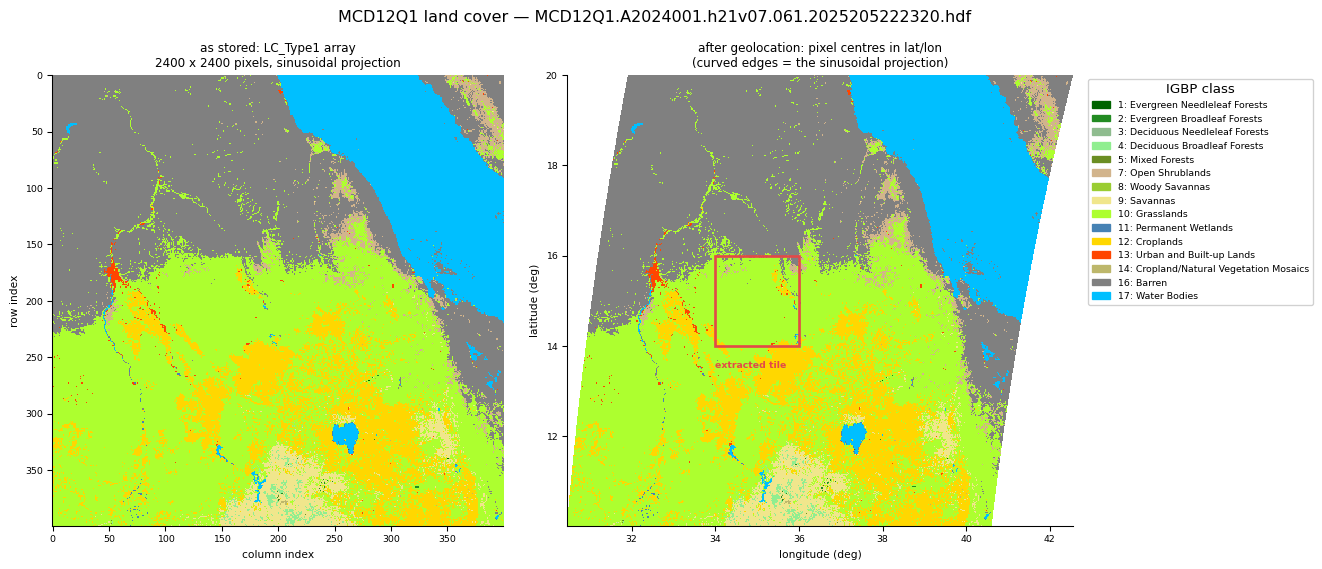

tile spans lat [10.00, 20.00], lon [30.47, 42.56]


In [9]:
"""IGBP: visualize the whole file — as stored, and after geolocation."""

if FILES["igbp"] is not None:
    from libera_utils.footprint_matching.readers._hdf4_io import read_modis_sinusoidal_hdf4

    # Read the full 2400 x 2400 tile plus the per-pixel 2-D lat/lon grids the reader
    # derives from StructMetadata.
    lc_full, lat_full, lon_full = read_modis_sinusoidal_hdf4(str(FILES["igbp"]), "LC_Type1")

    # Decimate for plotting: 2400^2 pixels is far more than a figure can resolve, and
    # nearest-neighbour decimation preserves category values exactly (no interpolation,
    # which would invent classes that do not exist).
    step = 6
    lc_view = lc_full[::step, ::step].copy()
    lat_view = lat_full[::step, ::step]
    lon_view = lon_full[::step, ::step]
    lc_view[lc_view == 255] = np.nan  # unclassified -> transparent

    codes = sorted(IGBP_COLORS)
    cmap = ListedColormap([IGBP_COLORS[c] for c in codes])
    norm = BoundaryNorm(np.arange(-0.5, len(codes) + 0.5, 1), cmap.N)
    indexed = np.full(lc_view.shape, np.nan)
    for i, code_value in enumerate(codes):
        indexed[lc_view == code_value] = i

    fig, (ax_raw, ax_geo) = plt.subplots(1, 2, figsize=(14, 6))

    # Panel 1: the array exactly as stored — row/column index space. Note the
    # rectangular outline: in the file the tile IS a rectangle.
    ax_raw.imshow(indexed, cmap=cmap, norm=norm, interpolation="nearest")
    ax_raw.set_title(f"as stored: LC_Type1 array\n{lc_full.shape[0]} x {lc_full.shape[1]} pixels, sinusoidal projection")
    ax_raw.set_xlabel("column index")
    ax_raw.set_ylabel("row index")

    # Panel 2: the same pixels at their true geographic positions. pcolormesh accepts
    # the 2-D coordinate arrays, so the sinusoidal tile's curved, non-rectangular
    # footprint in lat/lon becomes visible — this is why the reader rasterizes.
    ax_geo.pcolormesh(lon_view, lat_view, indexed, cmap=cmap, norm=norm, shading="nearest")
    ax_geo.set_title("after geolocation: pixel centres in lat/lon\n(curved edges = the sinusoidal projection)")
    ax_geo.set_xlabel("longitude (deg)")
    ax_geo.set_ylabel("latitude (deg)")
    draw_tile_box(ax_geo, "igbp")

    present = sorted({int(v) for v in np.unique(lc_view[np.isfinite(lc_view)])})
    ax_geo.legend(
        handles=[Patch(color=IGBP_COLORS[c], label=f"{c}: {IGBP_LEGEND.get(c, 'extended-scheme class')}") for c in present],
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        title="IGBP class",
        framealpha=0.9,
    )
    fig.suptitle(f"MCD12Q1 land cover — {FILES['igbp'].name}")
    fig.tight_layout()
    plt.show()

    print(f"tile spans lat [{np.nanmin(lat_full):.2f}, {np.nanmax(lat_full):.2f}], "
          f"lon [{np.nanmin(lon_full):.2f}, {np.nanmax(lon_full):.2f}]")

[igbp] MCD12Q1.A2024001.h21v07.061.2025205222320.hdf
[igbp] tile TileKey(source='igbp', lat_idx=52, lon_idx=107) -> lat [14.0, 16.0], lon [34.0, 36.0]
[igbp] loaded 1 variable(s), grid 40 x 40, 6.9 KiB, in 0.1 s
variable                        units        valid cells         min         max        mean         std
--------------------------------------------------------------------------------------------------------
surface_type                    1            1,600 (100%)           7          17       10.25         1.2



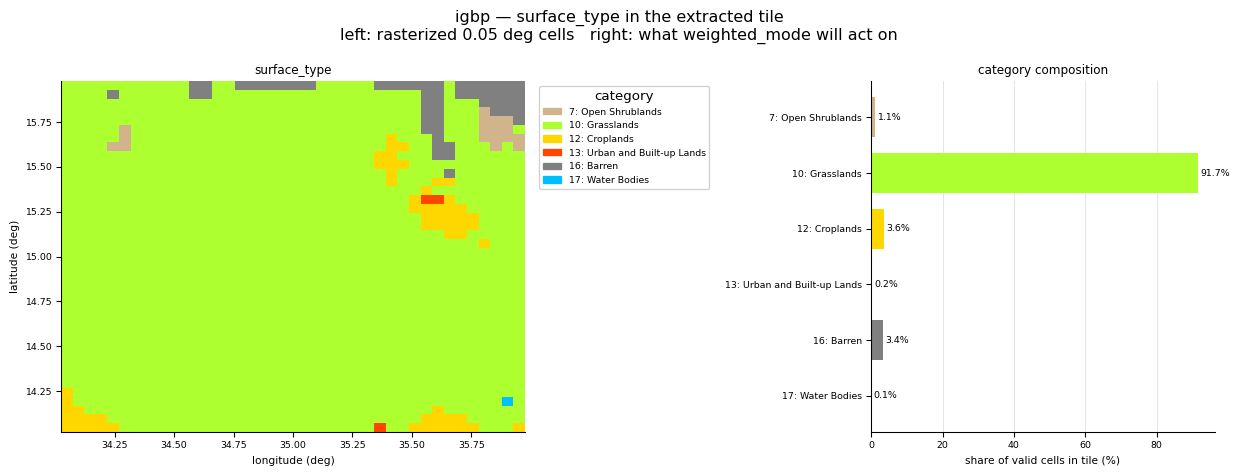

In [10]:
"""IGBP: load the verification tile, then plot and summarize the extracted variable."""

igbp_tile = load_reader_tile("igbp")
record_result("igbp", igbp_tile)

if igbp_tile is not None:
    # 255 is IGBP's "unclassified" fill; exclude it from the statistics so it does
    # not masquerade as a very large class code.
    tile_statistics(igbp_tile, "igbp", fill_value=255.0)

    labels = {c: IGBP_LEGEND.get(c, "extended-scheme class") for c in sorted(IGBP_COLORS)}
    plot_categorical_tile(
        igbp_tile,
        "igbp",
        "surface_type",
        labels=labels,
        colors=[IGBP_COLORS[c] for c in sorted(IGBP_COLORS)],
        title=(
            "igbp — surface_type in the extracted tile\n"
            "left: rasterized 0.05 deg cells   right: what weighted_mode will act on"
        ),
    )

---
# 6. Snow and ice extent — NSIDC `NISE`

**What it is.** Whether the surface is open water/bare ground, sea ice (and at what
concentration), permanent ice sheet, or dry snow on land. Snow and ice change surface albedo
by a factor of several, so this is one of the strongest controls on the shortwave flux
FMATCH is helping to derive.

| | |
|---|---|
| **Product** | NISE v5 (SSM/I–SSMIS) and NISE_A2 v1 (AMSR-2), *Near-real-time Ice and Snow Extent* |
| **Producer** | NSIDC (National Snow and Ice Data Center) |
| **Format** | HDF-EOS4 (`.HDFEOS`), read with `pyhdf` |
| **Native resolution** | 25 km |
| **Grid** | 721 × 721 **EASE-Grid North**, polar azimuthal equal-area ([EPSG:3408](https://epsg.io/3408)) |
| **Coverage** | Northern Hemisphere, daily |
| **File naming** | `NISE_SSMISF{FF}_{YYYYMMDD}.HDFEOS` (v5) · `NISE_AMSR2_{YYYYMMDD}.HDFEOS` (A2) |
| **Product page** | <https://nsidc.org/data/nise> |
| **User guide** | <https://nsidc.org/sites/default/files/nise5-v001-userguide.pdf> |
| **EASE-Grid** | <https://nsidc.org/ease> |
| **Download** | <https://n5eil01u.ecs.nsidc.org/NISE/> (Earthdata login required) |
| **Reader** | [`readers/nsidc.py`](../libera_utils/footprint_matching/readers/nsidc.py) |

## Internal structure

The file contains just two 721 × 721 uint8 datasets — `Extent` (what FMATCH reads) and
`Age`. There are no coordinate arrays: position comes from the fixed EASE-Grid North
definition, which the reader reconstructs from the grid's published parameters
(25 067.525 m cells, origin at ±9 036 842.7625 m) and reprojects to WGS84 with
[`pyproj`](https://pyproj4.github.io/pyproj/stable/).

## The `Extent` encoding — one byte, five meanings

| Code | Meaning |
|---|---|
| `0` | no ice and no snow (open ocean, snow-free land, **or outside the grid**) |
| `1–100` | sea ice concentration in **percent** |
| `101` | permanent ice (Greenland, ice shelves) |
| `102` | not used — belongs to no class |
| `103–110` | dry snow on land |
| `255` | missing / no retrieval |

A single number that is *sometimes* a percentage and *sometimes* a class label cannot be
averaged. So the reader **splits it into five independent coverage layers**, each of which
*can* be meaningfully averaged under a PSF:

* `sea_ice_concentration` keeps sub-pixel magnitude (code ÷ 100 → 0.01–1.0);
* the other four are 0/1 indicators whose PSF-weighted mean is the **fraction** of the
  footprint in that class.

Two consequences worth remembering: the five layers **do not sum to 1** (one is a
concentration, four are fractions), and `no_ice_or_snow` is **not an ocean mask** — NISE
collapses open water, bare land and out-of-grid pixels into the same code 0.

**Codes above 110 are not mapped.** Real granules also contain the product's mask values
(252 mixed coastal pixels, 253 suspect ice, 254 grid corners), which the reader's five layers
do not cover — those pixels contribute `0.0` to every layer, and `snow_ice_missing` (which
flags code 255 only) does not flag them. The cell below counts them in the staged file, and
they are a substantial fraction of the hemisphere. Whether coastal and suspect pixels should
be treated as missing is a science decision — `TODO[LIBSDC-785]`.

## Why this reader rasterizes

EASE-Grid North is azimuthal: latitude *and* longitude vary in two dimensions across the
pixel array (a grid row is not a parallel). As with IGBP, a 1-D coordinate collapse would
mis-place every pixel, so the reader reprojects per-pixel centres and bins them onto a
regular 0.25° sub-grid of the tile. Pixels whose EPSG:3408 → WGS84 transform is undefined
come back as NaN coordinates and are dropped.

In [11]:
"""NISE: variable documentation."""

register_docs(
    "nise",
    {
        "sea_ice_concentration": {
            "source": "Extent SDS, codes 1-100",
            "units": "fraction",
            "valid": (0.0, 1.0),
            "cmap": "Blues",
            "desc": (
                "Fractional sea ice concentration, decoded from the percent codes (code/100). "
                "Unlike the other four layers this keeps sub-pixel magnitude, so its PSF-weighted "
                "mean is a true mean concentration, not a coverage fraction."
            ),
        },
        "no_ice_or_snow": {
            "source": "Extent SDS, code 0",
            "units": "fraction",
            "valid": (0.0, 1.0),
            "cmap": "Greys",
            "desc": (
                "Indicator (1/0) for 'neither ice nor snow'. NOT an ocean mask: NISE assigns code 0 "
                "to open water, snow-free land and out-of-grid pixels alike."
            ),
        },
        "permanent_ice": {
            "source": "Extent SDS, code 101",
            "units": "fraction",
            "valid": (0.0, 1.0),
            "cmap": "Purples",
            "desc": "Indicator (1/0) for permanent ice sheet — Greenland and the Antarctic ice shelves.",
        },
        "dry_snow_on_land": {
            "source": "Extent SDS, codes 103-110",
            "units": "fraction",
            "valid": (0.0, 1.0),
            "cmap": "Greens",
            "desc": "Indicator (1/0) for dry snow lying on land. Its PSF-weighted mean is snow-covered area fraction.",
        },
        "snow_ice_missing": {
            "source": "Extent SDS, code 255",
            "units": "fraction",
            "valid": (0.0, 1.0),
            "cmap": "Oranges",
            "desc": (
                "Indicator (1/0) for pixels with no retrieval. Carried as a variable rather than "
                "discarded so the fraction of a footprint with missing snow/ice information is "
                "quantified in the product instead of being silently absorbed into the other layers."
            ),
        },
    },
)
show_variable_table("nise")

variable                        units       aggregation         source field
--------------------------------------------------------------------------------------------------------------
sea_ice_concentration           fraction    weighted_mean       Extent SDS, codes 1-100
    Fractional sea ice concentration, decoded from the percent codes (code/100). Unlike the other
    four layers this keeps sub-pixel magnitude, so its PSF-weighted mean is a true mean
    concentration, not a coverage fraction.
no_ice_or_snow                  fraction    weighted_mean       Extent SDS, code 0
    Indicator (1/0) for 'neither ice nor snow'. NOT an ocean mask: NISE assigns code 0 to open
    water, snow-free land and out-of-grid pixels alike.
permanent_ice                   fraction    weighted_mean       Extent SDS, code 101
    Indicator (1/0) for permanent ice sheet — Greenland and the Antarctic ice shelves.
dry_snow_on_land                fraction    weighted_mean       Extent SDS, codes 103-11

In [12]:
"""NISE: inspect the raw HDF-EOS file and the Extent code histogram."""

if FILES["nise"] is not None:
    from pyhdf.SD import SD, SDC

    hdf = SD(str(FILES["nise"]), SDC.READ)
    try:
        print("Datasets in the file:")
        for name, info in sorted(hdf.datasets().items()):
            print(f"   {name:<10} shape={info[1]}  dtype code={info[3]}")
        extent_raw = np.array(hdf.select("Extent").get())
    finally:
        hdf.end()

    print(f"\nExtent array: {extent_raw.shape}, dtype {extent_raw.dtype}")
    print("\nHow the whole hemisphere's bytes are distributed across the code groups the reader maps:")
    groups = [
        ("0        no ice / no snow", (extent_raw == 0)),
        ("1-100    sea ice concentration", (extent_raw >= 1) & (extent_raw <= 100)),
        ("101      permanent ice", (extent_raw == 101)),
        ("102      not used", (extent_raw == 102)),
        ("103-110  dry snow on land", (extent_raw >= 103) & (extent_raw <= 110)),
        ("255      missing", (extent_raw == 255)),
    ]
    total = extent_raw.size
    mapped = np.zeros(extent_raw.shape, dtype=bool)
    for label, mask in groups:
        count = int(mask.sum())
        mapped |= mask
        print(f"   {label:<34}{count:>9,} px  ({100.0 * count / total:>5.1f}%)")

    # Anything the five output layers do not cover. These pixels come back as 0.0 in
    # EVERY layer — including snow_ice_missing — so a footprint over them looks like
    # "measured, and nothing there" rather than "no information". Worth knowing about.
    leftover_codes, leftover_counts = np.unique(extent_raw[~mapped], return_counts=True)
    print(f"\n   {'NOT mapped to any output layer':<34}{int((~mapped).sum()):>9,} px  "
          f"({100.0 * int((~mapped).sum()) / total:>5.1f}%)")
    for code_value, count in zip(leftover_codes, leftover_counts):
        print(f"      code {int(code_value):>3}: {int(count):>9,} px  ({100.0 * count / total:>5.1f}%)")
    if leftover_codes.size:
        print("\n   Per the NSIDC user guide these high codes are the product's masks —")
        print("   252 mixed pixels at coastlines, 253 suspect ice value, 254 grid corners")
        print("   outside the hemispheric disc. The reader's five layers cover 0-110 and 255")
        print("   only, so these pixels contribute 0.0 to every layer, and snow_ice_missing")
        print("   does NOT flag them. Whether coastal/suspect pixels should count as missing")
        print("   is a science decision, not a reader detail — see TODO[LIBSDC-785].")
else:
    print("NISE file not available.")

Datasets in the file:
   Age        shape=(721, 721)  dtype code=3
   Extent     shape=(721, 721)  dtype code=2

Extent array: (721, 721), dtype uint8

How the whole hemisphere's bytes are distributed across the code groups the reader maps:
   0        no ice / no snow           135,181 px  ( 26.0%)
   1-100    sea ice concentration       15,837 px  (  3.0%)
   101      permanent ice                2,800 px  (  0.5%)
   102      not used                         0 px  (  0.0%)
   103-110  dry snow on land             4,877 px  (  0.9%)
   255      missing                    217,736 px  ( 41.9%)

   NOT mapped to any output layer      143,410 px  ( 27.6%)
      code 252:    29,373 px  (  5.7%)
      code 253:        89 px  (  0.0%)
      code 254:   113,948 px  ( 21.9%)

   Per the NSIDC user guide these high codes are the product's masks —
   252 mixed pixels at coastlines, 253 suspect ice value, 254 grid corners
   outside the hemispheric disc. The reader's five layers cover 0-110 and 

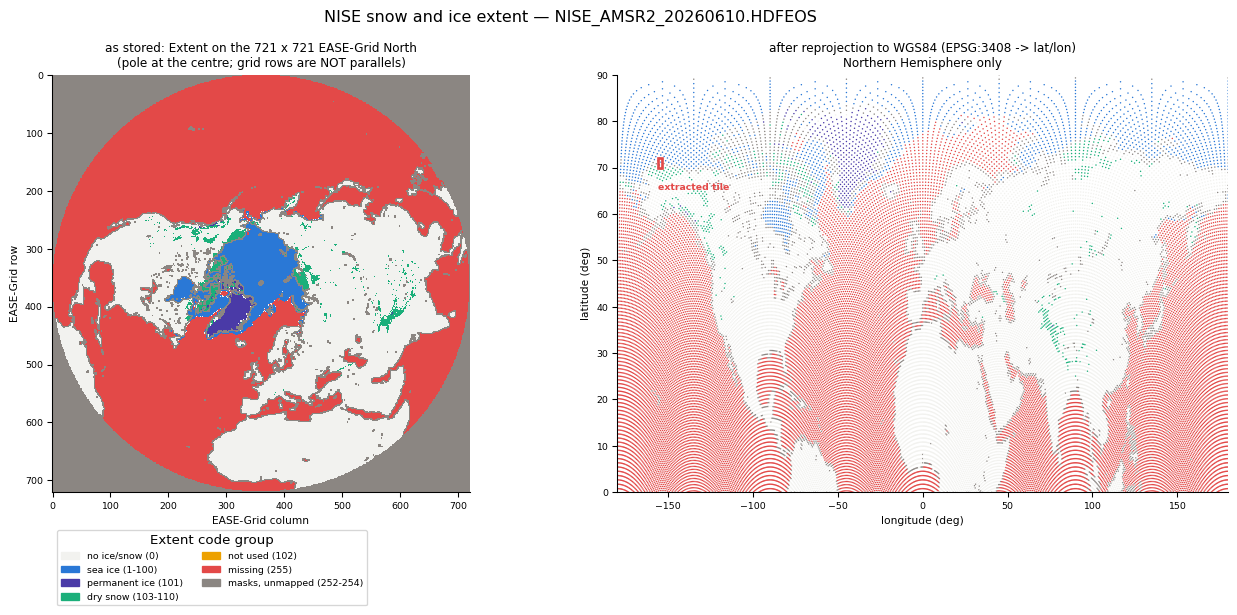

In [13]:
"""NISE: visualize the whole hemisphere — EASE-Grid as stored, then reprojected."""

if FILES["nise"] is not None:
    # Colour the raw byte grid by code GROUP, not by byte value: the codes are a
    # mixture of a percentage scale and class labels, so a single continuous ramp
    # over 0-255 would be meaningless.
    group_colors = ["#f2f2ef", "#2a78d6", "#4a3aa7", "#1baf7a", "#eda100", "#e34948", "#8b8682"]
    group_labels = [
        "no ice/snow (0)",
        "sea ice (1-100)",
        "permanent ice (101)",
        "dry snow (103-110)",
        "not used (102)",
        "missing (255)",
        "masks, unmapped (252-254)",
    ]
    grouped = np.full(extent_raw.shape, np.nan)
    grouped[extent_raw == 0] = 0
    grouped[(extent_raw >= 1) & (extent_raw <= 100)] = 1
    grouped[extent_raw == 101] = 2
    grouped[(extent_raw >= 103) & (extent_raw <= 110)] = 3
    grouped[extent_raw == 102] = 4
    grouped[extent_raw == 255] = 5
    # Drawn in grey so the pixels the reader's five layers do not cover are visible
    # rather than blank — they are a quarter of the hemisphere in these granules.
    grouped[(extent_raw >= 252) & (extent_raw <= 254)] = 6

    cmap = ListedColormap(group_colors)
    norm = BoundaryNorm(np.arange(-0.5, len(group_colors) + 0.5, 1), cmap.N)

    fig, (ax_raw, ax_geo) = plt.subplots(1, 2, figsize=(14, 6.5))
    ax_raw.imshow(grouped, cmap=cmap, norm=norm, interpolation="nearest")
    ax_raw.set_title("as stored: Extent on the 721 x 721 EASE-Grid North\n(pole at the centre; grid rows are NOT parallels)")
    ax_raw.set_xlabel("EASE-Grid column")
    ax_raw.set_ylabel("EASE-Grid row")
    ax_raw.legend(
        handles=[Patch(color=c, label=lab) for c, lab in zip(group_colors, group_labels)],
        loc="upper left",
        bbox_to_anchor=(0.0, -0.08),
        ncol=2,
        title="Extent code group",
    )

    # Reproject with the reader's own transformer so the plot shows exactly the
    # geolocation the reader will use.
    reader = ReaderRegistry.get("nise")(FILES["nise"])
    grid_lats, grid_lons = reader._compute_latlon_grid()
    step = 3  # decimate: 520k points is more than a scatter plot needs
    lat_pts = grid_lats[::step, ::step].ravel()
    lon_pts = grid_lons[::step, ::step].ravel()
    grp_pts = grouped[::step, ::step].ravel()
    keep = np.isfinite(lat_pts) & np.isfinite(lon_pts) & np.isfinite(grp_pts)

    ax_geo.scatter(lon_pts[keep], lat_pts[keep], c=[group_colors[int(g)] for g in grp_pts[keep]], s=1.2, linewidths=0)
    ax_geo.set_title("after reprojection to WGS84 (EPSG:3408 -> lat/lon)\nNorthern Hemisphere only")
    ax_geo.set_xlabel("longitude (deg)")
    ax_geo.set_ylabel("latitude (deg)")
    ax_geo.set_xlim(-180, 180)
    ax_geo.set_ylim(0, 90)
    draw_tile_box(ax_geo, "nise")

    fig.suptitle(f"NISE snow and ice extent — {FILES['nise'].name}")
    fig.tight_layout()
    plt.show()

[nise] NISE_AMSR2_20260610.HDFEOS
[nise] tile TileKey(source='nise', lat_idx=80, lon_idx=12) -> lat [70.0, 72.0], lon [-156.0, -154.0]
[nise] loaded 5 variable(s), grid 8 x 8, 1.4 KiB, in 0.0 s
variable                        units        valid cells         min         max        mean         std
--------------------------------------------------------------------------------------------------------
sea_ice_concentration           fraction        28 ( 44%)           0        0.89      0.3086      0.4141
no_ice_or_snow                  fraction        28 ( 44%)           0           0           0           0
permanent_ice                   fraction        28 ( 44%)           0           0           0           0
dry_snow_on_land                fraction        28 ( 44%)           0           1        0.25       0.433
snow_ice_missing                fraction        28 ( 44%)           0           0           0           0



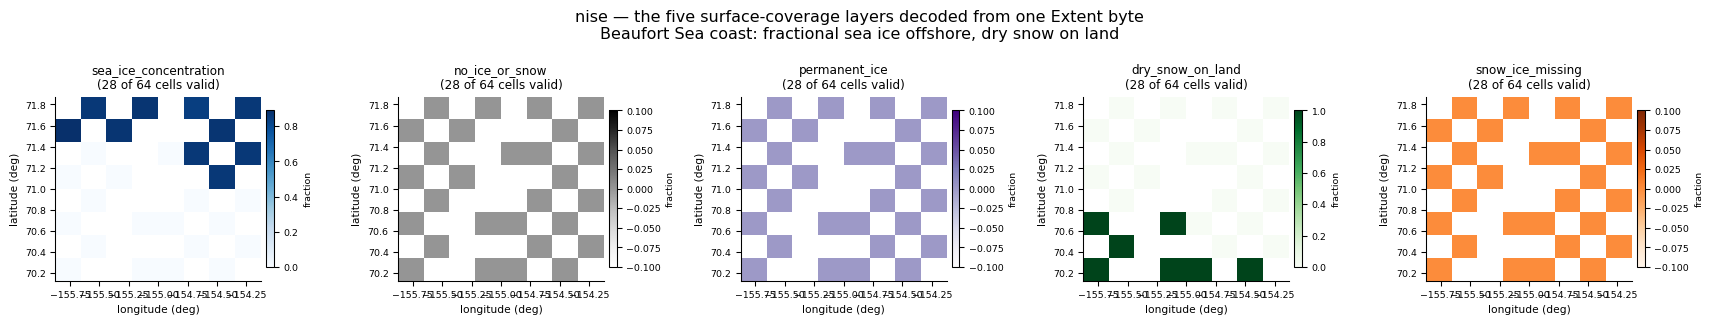

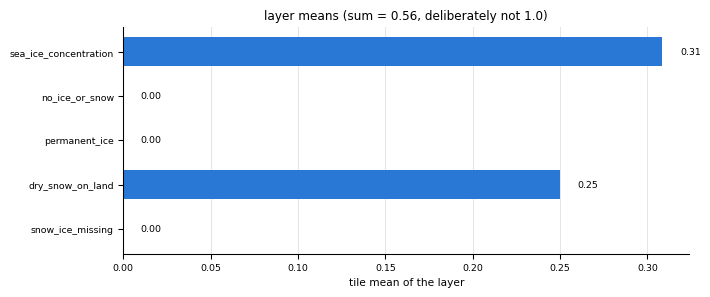

In [14]:
"""NISE: load the verification tile, then plot all five coverage layers."""

nise_tile = load_reader_tile("nise")
record_result("nise", nise_tile)

if nise_tile is not None:
    tile_statistics(nise_tile, "nise")
    plot_tile_variables(
        nise_tile,
        "nise",
        ncols=5,
        panel_size=(3.6, 3.4),
        suptitle=(
            "nise — the five surface-coverage layers decoded from one Extent byte\n"
            "Beaufort Sea coast: fractional sea ice offshore, dry snow on land"
        ),
    )

    # The layers are independent by construction; showing their cell-mean side by
    # side makes the "they do not sum to 1" design decision concrete.
    means = [(name, float(np.nanmean(arr)) if np.isfinite(arr).any() else 0.0) for name, arr in variable_slices(nise_tile, "nise")]
    fig, ax = plt.subplots(figsize=(7.5, 3.2))
    ax.barh([n for n, _ in means], [v for _, v in means], color=CATEGORICAL_SLOTS[0], height=0.65)
    ax.set_xlabel("tile mean of the layer")
    ax.set_title(f"layer means (sum = {sum(v for _, v in means):.2f}, deliberately not 1.0)")
    ax.invert_yaxis()
    ax.grid(axis="x", color="#e5e5e2")
    ax.set_axisbelow(True)
    for y, (_, v) in enumerate(means):
        ax.text(v + 0.01, y, f"{v:.2f}", va="center", fontsize=7)
    fig.tight_layout()
    plt.show()

---
# 7. Surface meteorology — ECMWF `ERA5` single levels

**What it is.** The state of the surface and the air immediately above it: wind, temperature,
humidity, pressure, terrain height, and albedo. Wind matters because ocean surface roughness
(and hence its reflectance) is wind-driven; the rest are the year-one substitutes described
below.

| | |
|---|---|
| **Product** | ERA5 reanalysis, *single levels* (surface fields) |
| **Producer** | ECMWF, distributed via the Copernicus Climate Data Store |
| **Format** | NetCDF4 (`.nc`); the CDS names files after the request hash |
| **Native resolution** | 0.25° (~28 km), declared to FMATCH as 25 km |
| **Grid** | regular lat/lon, global, **latitude descending** (90 → −90), longitude 0…360 or −180…180 depending on the request |
| **Temporal** | hourly; 1940 → present, final data lagging ~5 days (ERA5T ~1 day) |
| **Dataset** | <https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels> |
| **API guide** | <https://cds.climate.copernicus.eu/how-to-api> |
| **Variable docs** | <https://confluence.ecmwf.int/display/CKB/ERA5+data+documentation> |
| **Reader** | [`readers/era5.py`](../libera_utils/footprint_matching/readers/era5.py) |

## Internal structure

A flat NetCDF4 file: one variable per field, each shaped `(valid_time, latitude, longitude)`,
with 1-D coordinate variables. The reader normalizes three things that vary between
downloads and would otherwise silently corrupt the geolocation:

1. **longitude convention** → everything is wrapped to −180…180;
2. **latitude direction** → the file stores 90 → −90, and the reader flips it to ascending
   so all readers agree;
3. **the time-like dimension** → named `time` in older files and `valid_time` in current
   ones; the reader takes the first step of whichever is present.

The whole global grid is read once and cached per reader instance, then every tile is a
slice of that in-memory array.

## Two groups of variables

`wind_u10` and `wind_v10` are read for **every** FMATCH product from mission start. The other
five are **year-one substitutes**: during the first year of operation the RBSP cloud products
(CLDPIX, CERES SSF) do not exist yet, so `FmatchVariant.YEAR_ONE` swaps in ERA5 reanalysis
fields for the FMATCH-IMAGER product. They are marked `required_variant=YEAR_ONE`, and once
RBSP data flows the post-year-one product drops them in favour of the real retrievals.

Each ECMWF field also has a numeric parameter ID, linked below, whose database entry gives
the authoritative definition and units.

In [15]:
"""ERA5 single-level: variable documentation."""

register_docs(
    "era5",
    {
        "wind_u10": {
            "source": "u10  (ECMWF param 165)",
            "units": "m/s",
            "valid": None,
            "cmap": DIVERGING,  # signed: sign carries direction, so the ramp is centred on zero
            "desc": (
                "Eastward component of the wind at 10 m above the surface. Positive is toward the "
                "east. Combined with v10 it gives the surface wind speed that sets ocean-surface "
                "roughness and therefore the sun-glint / reflectance behaviour of water scenes. "
                "https://apps.ecmwf.int/codes/grib/param-db?id=165"
            ),
        },
        "wind_v10": {
            "source": "v10  (ECMWF param 166)",
            "units": "m/s",
            "valid": None,
            "cmap": DIVERGING,
            "desc": (
                "Northward component of the wind at 10 m above the surface; positive toward the "
                "north. https://apps.ecmwf.int/codes/grib/param-db?id=166"
            ),
        },
        "temperature_2m": {
            "source": "t2m  (ECMWF param 167)",
            "units": "K",
            "valid": None,
            "cmap": "Reds",
            "desc": (
                "Air temperature at 2 m above the surface. Year-one substitute: it constrains the "
                "surface-emitted longwave radiance that FMATCH would otherwise take from an RBSP "
                "cloud/clear-sky retrieval. https://apps.ecmwf.int/codes/grib/param-db?id=167"
            ),
        },
        "dew_point_temperature_2m": {
            "source": "d2m  (ECMWF param 168)",
            "units": "K",
            "valid": None,
            "cmap": "Purples",
            "desc": (
                "Dew-point temperature at 2 m: the temperature to which the air would have to cool "
                "to saturate. Together with t2m it gives near-surface humidity, which drives "
                "water-vapour absorption in the longwave window. "
                "https://apps.ecmwf.int/codes/grib/param-db?id=168"
            ),
        },
        "surface_pressure": {
            "source": "sp  (ECMWF param 134)",
            "units": "Pa",
            "valid": None,
            "cmap": "Greens",
            "desc": (
                "Pressure at the surface — i.e. the weight of the whole atmospheric column above "
                "the point, so it tracks terrain elevation as much as weather. Sets the lower "
                "boundary of the pressure-level profile. https://apps.ecmwf.int/codes/grib/param-db?id=134"
            ),
        },
        "surface_geopotential": {
            "source": "z  (ECMWF param 129)",
            "units": "m2/s2",
            "valid": None,
            "cmap": "Greys",
            "desc": (
                "Surface geopotential: the model's orography expressed as height x gravity. Divide "
                "by g = 9.80665 m/s2 to get surface elevation in metres. Static in time — it is the "
                "terrain, not the weather. https://apps.ecmwf.int/codes/grib/param-db?id=129"
            ),
        },
        "forecast_albedo": {
            "source": "fal  (ECMWF param 243)",
            "units": "1",
            "valid": (0.0, 1.0),
            "cmap": "Oranges",
            "desc": (
                "Broadband shortwave albedo used by the ECMWF forecast model: the fraction of "
                "incoming solar radiation the surface reflects. Snow and ice push it above 0.6; "
                "open ocean sits near 0.06. https://apps.ecmwf.int/codes/grib/param-db?id=243"
            ),
        },
    },
)
show_variable_table("era5")

variable                        units       aggregation         source field
--------------------------------------------------------------------------------------------------------------
wind_u10                        m/s         weighted_mean       u10  (ECMWF param 165)
    Eastward component of the wind at 10 m above the surface. Positive is toward the east. Combined
    with v10 it gives the surface wind speed that sets ocean-surface roughness and therefore the
    sun-glint / reflectance behaviour of water scenes.
    https://apps.ecmwf.int/codes/grib/param-db?id=165
wind_v10                        m/s         weighted_mean       v10  (ECMWF param 166)
    Northward component of the wind at 10 m above the surface; positive toward the north.
    https://apps.ecmwf.int/codes/grib/param-db?id=166
temperature_2m                  K           weighted_mean       t2m  (ECMWF param 167)
    Air temperature at 2 m above the surface. Year-one substitute: it constrains the
    surface-emit

In [16]:
"""ERA5 single-level: inspect the file's structure and coordinate conventions."""

if FILES["era5"] is not None:
    import xarray as xr

    with xr.open_dataset(FILES["era5"], engine="netcdf4") as ds:
        print(f"file: {FILES['era5'].name}")
        print(f"dimensions : {dict(ds.sizes)}")
        print(f"coordinates: {list(ds.coords)}")
        print(f"data variables ({len(ds.data_vars)}): {list(ds.data_vars)[:12]}"
              + (" ..." if len(ds.data_vars) > 12 else ""))
        lat = ds["latitude"].values
        lon = ds["longitude"].values
        print()
        print(f"latitude : {lat[0]:.2f} -> {lat[-1]:.2f}  ({'DESCENDING' if lat[0] > lat[-1] else 'ascending'}), "
              f"step {abs(lat[1] - lat[0]):.2f} deg")
        print(f"longitude: {lon[0]:.2f} -> {lon[-1]:.2f}  "
              f"({'0..360 convention' if lon.max() > 180 else '-180..180 convention'}), "
              f"step {abs(lon[1] - lon[0]):.2f} deg")
        time_dim = "valid_time" if "valid_time" in ds.coords else "time"
        print(f"time     : {time_dim} = {np.datetime_as_string(ds[time_dim].values[0], unit='s')}")
        print()
        print("units and long names as declared in the file:")
        for _, nc_name in [("wind_u10", "u10"), ("wind_v10", "v10"), ("temperature_2m", "t2m"),
                           ("dew_point_temperature_2m", "d2m"), ("surface_pressure", "sp"),
                           ("surface_geopotential", "z"), ("forecast_albedo", "fal")]:
            if nc_name in ds:
                attrs = ds[nc_name].attrs
                print(f"   {nc_name:<5} {attrs.get('units', '-'):<10} {attrs.get('long_name', '-')}")
else:
    print("ERA5 single-level file not available.")

file: 68c76be0e3abb1bf23bcc15be5496e7b.nc
dimensions : {'valid_time': 1, 'latitude': 721, 'longitude': 1440}
coordinates: ['number', 'valid_time', 'latitude', 'longitude', 'expver']
data variables (7): ['u10', 'v10', 'd2m', 't2m', 'sp', 'fal', 'z']

latitude : 90.00 -> -90.00  (DESCENDING), step 0.25 deg
longitude: 0.00 -> 359.75  (0..360 convention), step 0.25 deg
time     : valid_time = 2025-01-01T00:00:00

units and long names as declared in the file:
   u10   m s**-1    10 metre U wind component
   v10   m s**-1    10 metre V wind component
   t2m   K          2 metre temperature
   d2m   K          2 metre dewpoint temperature
   sp    Pa         Surface pressure
   z     m**2 s**-2 Geopotential
   fal   (0 - 1)    Forecast albedo


[era5] 68c76be0e3abb1bf23bcc15be5496e7b.nc
[era5] tile TileKey(source='era5', lat_idx=67, lon_idx=45) -> lat [44.0, 46.0], lon [-90.0, -88.0]
[era5] loaded 7 variable(s), grid 9 x 9, 2.4 KiB, in 0.1 s
variable                        units        valid cells         min         max        mean         std
--------------------------------------------------------------------------------------------------------
wind_u10                        m/s             81 (100%)       2.241       4.014       2.843      0.3695
wind_v10                        m/s             81 (100%)      -2.885      -1.197      -2.137       0.386
temperature_2m                  K               81 (100%)       269.8       274.2       272.3        1.26
dew_point_temperature_2m        K               81 (100%)       266.4       271.6       268.7       1.397
surface_pressure                Pa              81 (100%)   9.505e+04   9.858e+04   9.688e+04        1142
surface_geopotential            m2/s2           81 (100%)  

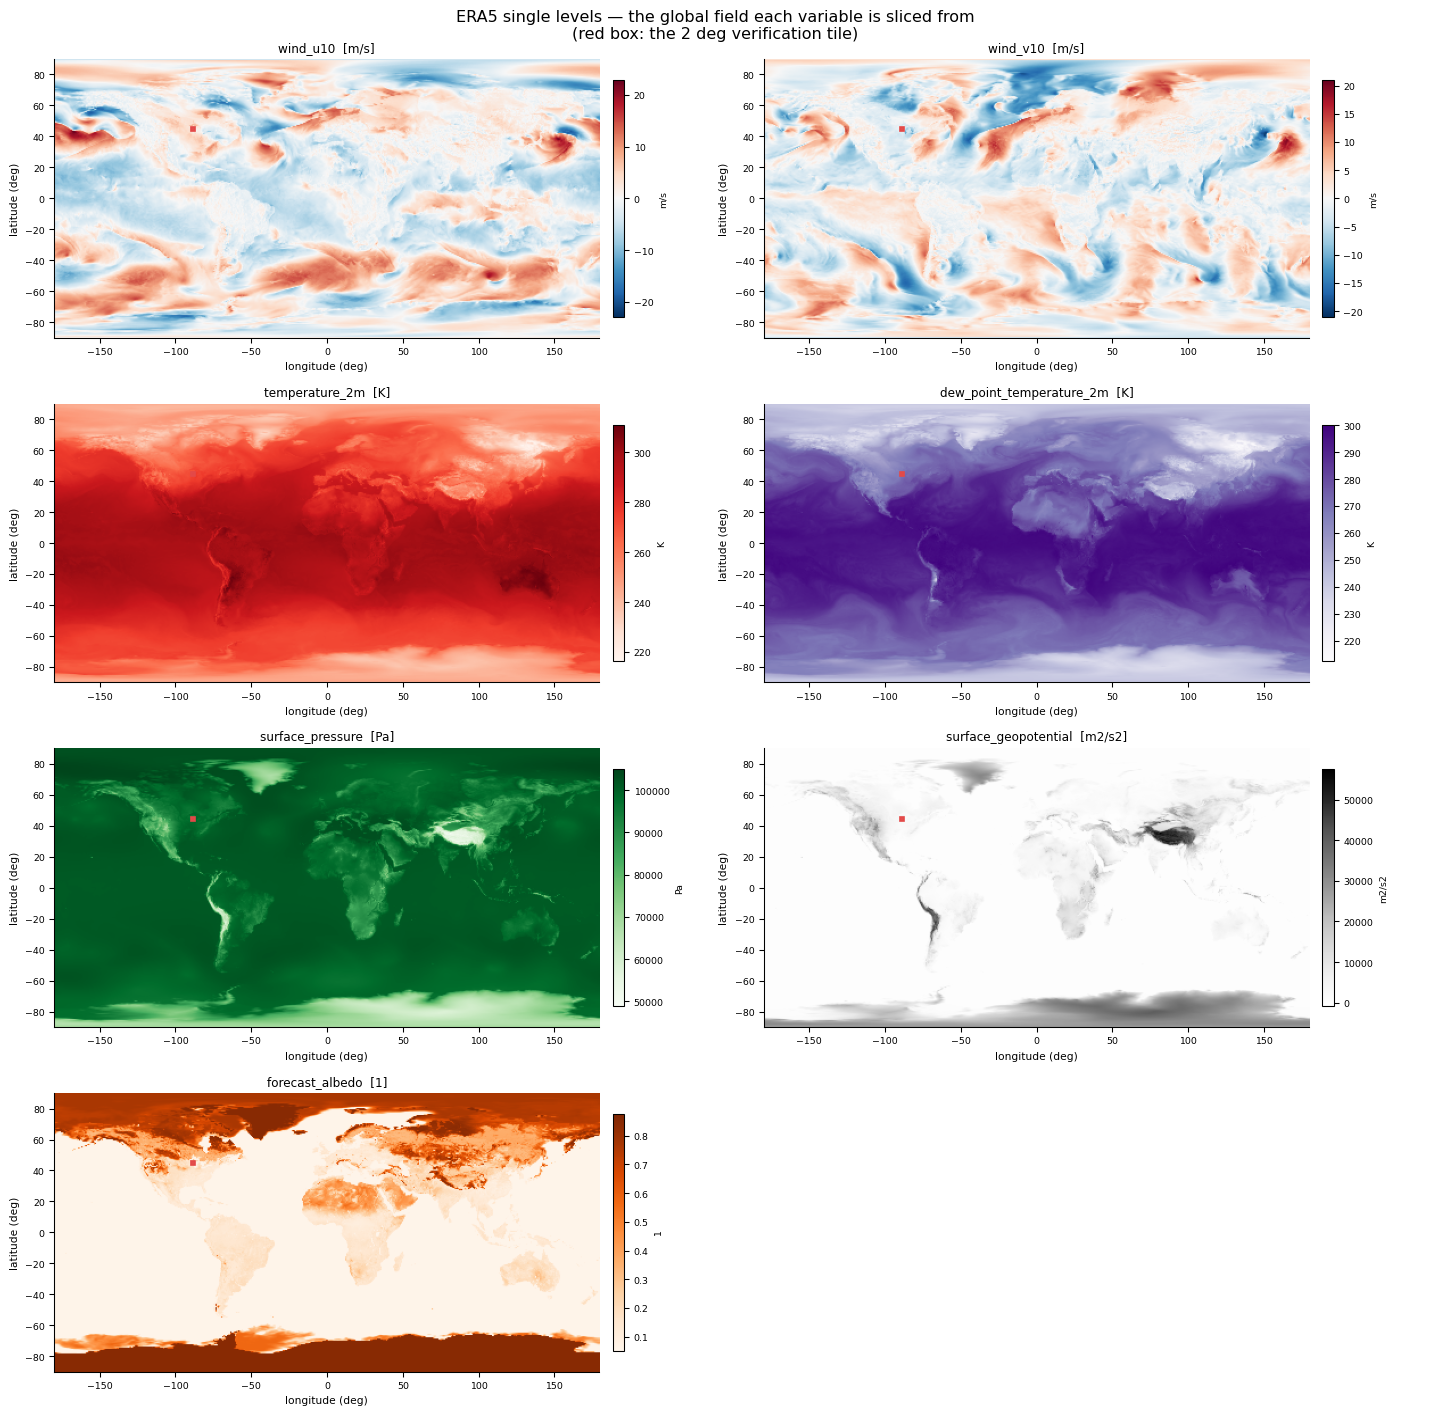

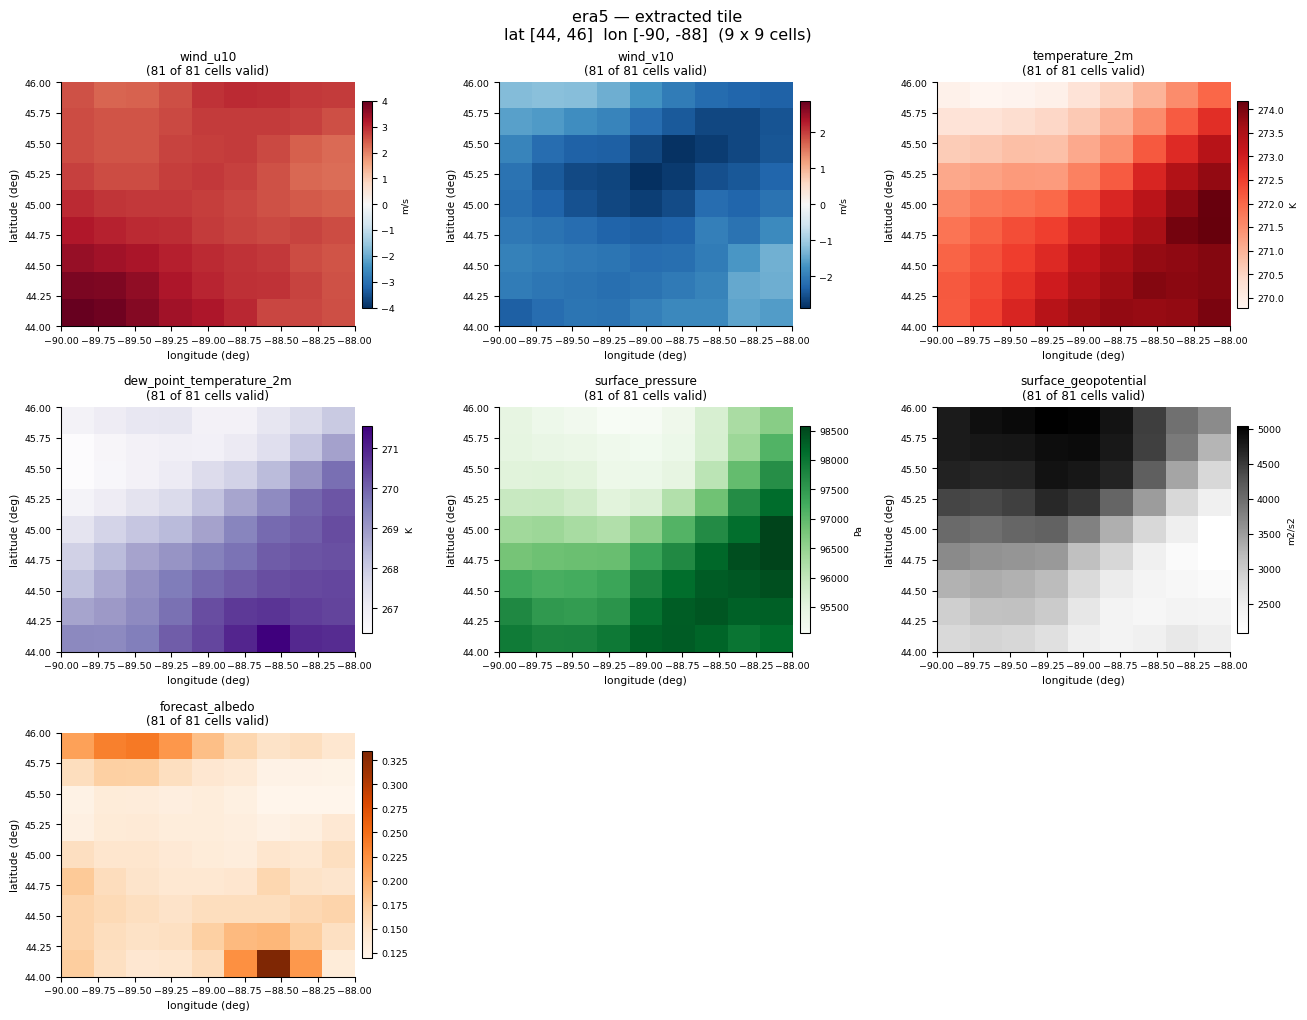

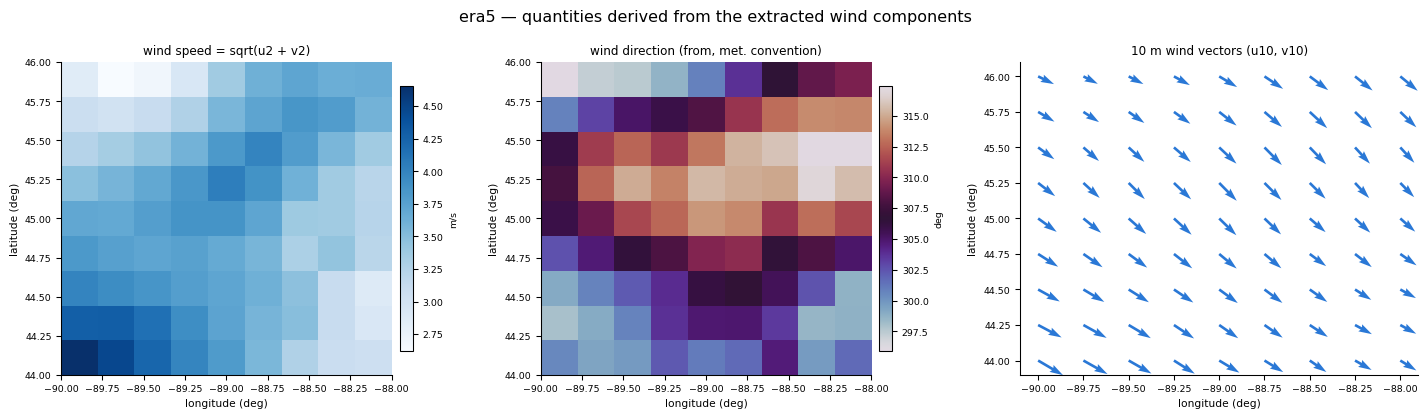

surface elevation from geopotential: 213 to 514 m


In [17]:
"""ERA5 single-level: load the tile, then visualize each variable globally and in the tile."""

era5_tile = load_reader_tile("era5")
record_result("era5", era5_tile)

if era5_tile is not None:
    tile_statistics(era5_tile, "era5")

    # --- whole-file view -----------------------------------------------------
    # Reuse the reader's cached global grid: (7, 721, 1440), already normalized to
    # -180..180 longitude and ascending latitude.
    global_data, global_lats, global_lons = READERS["era5"]._native_grid
    step = 3  # 721 x 1440 -> 241 x 480 for plotting
    extent = [float(global_lons.min()), float(global_lons.max()), float(global_lats.min()), float(global_lats.max())]

    specs = ReaderRegistry.get("era5").VARIABLES
    fig, axes = plt.subplots(4, 2, figsize=(15, 15))
    flat = axes.ravel()
    for ax, (i, spec) in zip(flat, enumerate(specs)):
        doc = VARIABLE_DOC["era5"][spec.name]
        plot_field(
            ax,
            global_data[i, ::step, ::step],
            extent,
            cmap=doc["cmap"],
            title=f"{spec.name}  [{doc['units']}]",
            cbar_label=doc["units"],
        )
        draw_tile_box(ax, "era5", pad_label=False)
    flat[-1].axis("off")
    fig.suptitle("ERA5 single levels — the global field each variable is sliced from\n(red box: the 2 deg verification tile)")
    fig.tight_layout()
    plt.show()

    # --- extracted tile ------------------------------------------------------
    plot_tile_variables(era5_tile, "era5", ncols=3)

    # --- derived quantities --------------------------------------------------
    # Wind speed and direction are not stored variables; they are what the u/v pair
    # means physically, and plotting them checks that the two components were read in
    # the right order (a u/v swap would rotate every arrow by 90 deg).
    u10, v10 = era5_tile.data[0], era5_tile.data[1]
    speed = np.sqrt(u10**2 + v10**2)
    # Meteorological convention: the direction the wind blows FROM, clockwise from north.
    direction = (np.degrees(np.arctan2(-u10, -v10)) + 360.0) % 360.0
    tile_extent = _extent_of(era5_tile)

    fig, (ax_speed, ax_dir, ax_quiver) = plt.subplots(1, 3, figsize=(15, 4.4))
    plot_field(ax_speed, speed, tile_extent, "Blues", "wind speed = sqrt(u2 + v2)", "m/s")
    plot_field(ax_dir, direction, tile_extent, CYCLIC, "wind direction (from, met. convention)", "deg")
    # A quiver plot shows the actual vector field the two components encode.
    lon_grid, lat_grid = np.meshgrid(era5_tile.lons, era5_tile.lats)
    ax_quiver.quiver(lon_grid, lat_grid, u10, v10, color="#2a78d6")
    ax_quiver.set_title("10 m wind vectors (u10, v10)")
    ax_quiver.set_xlabel("longitude (deg)")
    ax_quiver.set_ylabel("latitude (deg)")
    fig.suptitle("era5 — quantities derived from the extracted wind components")
    fig.tight_layout()
    plt.show()

    # Surface geopotential is the one field that is terrain rather than weather:
    # converting it to metres is the quickest sanity check that units are right.
    elevation_m = era5_tile.data[5] / 9.80665
    print(f"surface elevation from geopotential: {elevation_m.min():.0f} to {elevation_m.max():.0f} m")

---
# 8. Atmospheric profile — ECMWF `ERA5` pressure levels

**What it is.** The vertical structure of the atmosphere above the footprint: temperature,
geopotential height, ozone, and humidity at thirteen pressure levels. These are the
**year-one substitutes** for the atmospheric state that the RBSP CLDPIX product will supply
later; the whole reader is gated `REQUIRED_VARIANT = YEAR_ONE`.

| | |
|---|---|
| **Product** | ERA5 reanalysis, *pressure levels* |
| **Producer** | ECMWF / Copernicus Climate Data Store |
| **Format** | NetCDF4, shape `(valid_time, pressure_level, latitude, longitude)` |
| **Native resolution** | 0.25° (~28 km), up to 37 pressure levels (1–1000 hPa) |
| **Dataset** | <https://cds.climate.copernicus.eu/datasets/reanalysis-era5-pressure-levels> |
| **Reader** | [`readers/era5_pressure.py`](../libera_utils/footprint_matching/readers/era5_pressure.py) |

This is a **separate CDS dataset and a separate download** from the single-level fields, and
therefore a separate reader — each `GriddedDataReader` reads exactly one file.

## Why 65 flat variables instead of a vertical dimension

FMATCH products are strictly one-dimensional per footprint (every product variable lives on
the time dimension), and `GridTile.data` is at most `(n_var, n_lat, n_lon)`. Rather than
introduce a vertical axis that the tile contract, the aggregation engine and the product
schema would all have to learn, each **(variable, level)** pair is flattened into its own
`VariableSpec`: `temperature_500hPa`, `ozone_mass_mixing_ratio_50hPa`, and so on.

5 variables × 13 levels = **65 read variables** (130 product variables once the automatic
standard-deviation companions are added). The retained level set is the module constant
`_ERA5_PRESSURE_LEVELS`; ERA5 offers 37 levels, and carrying them all would mean 370 product
variables, so the science team selected this subset. Changing it is a one-line edit — the
specs and the product-definition cross-check both derive from that constant.

## Strictness about levels

The reader validates the level set up front and **raises** if the file is missing any
configured level, rather than silently substituting a neighbouring one. A partial download
is an acquisition-time mistake; interpolating around it would quietly corrupt the product.
The cell below shows which levels the staged file actually contains.

In [18]:
"""ERA5 pressure levels: variable documentation, generated per (variable, level) pair."""

from libera_utils.footprint_matching.readers.era5_pressure import (
    _ERA5_PRESSURE_LEVEL_VARIABLES,
    _ERA5_PRESSURE_LEVELS,
)

# One documentation entry per (base variable, level). The base descriptions are
# written once and specialized with the level, so all 65 entries stay consistent.
_PRESSURE_BASE_DOC = {
    "temperature": {
        "nc": "t  (ECMWF param 130)",
        "units": "K",
        "cmap": "Reds",
        "desc": (
            "Air temperature on the {level} hPa surface. The vertical temperature profile sets the "
            "thermal emission of each atmospheric layer and therefore the outgoing longwave radiation "
            "the Libera radiometer sees. https://apps.ecmwf.int/codes/grib/param-db?id=130"
        ),
    },
    "geopotential": {
        "nc": "z  (ECMWF param 129)",
        "units": "m2/s2",
        "cmap": "Greys",
        "desc": (
            "Geopotential of the {level} hPa surface — divide by g = 9.80665 to get the geometric "
            "height of that pressure level in metres. It converts the pressure-coordinate profile "
            "into a geometric one. https://apps.ecmwf.int/codes/grib/param-db?id=129"
        ),
    },
    "ozone_mass_mixing_ratio": {
        "nc": "o3  (ECMWF param 203)",
        "units": "kg/kg",
        "cmap": "Purples",
        "desc": (
            "Mass of ozone per kilogram of air at {level} hPa. Peaks in the stratosphere (10-50 hPa); "
            "ozone absorbs ultraviolet and has a longwave band at 9.6 um, so it affects both ends of "
            "the radiation budget. https://apps.ecmwf.int/codes/grib/param-db?id=203"
        ),
    },
    "specific_humidity": {
        "nc": "q  (ECMWF param 133)",
        "units": "kg/kg",
        "cmap": "Blues",
        "desc": (
            "Mass of water vapour per kilogram of moist air at {level} hPa. The dominant greenhouse "
            "absorber; it falls by orders of magnitude from the surface to the stratosphere. "
            "https://apps.ecmwf.int/codes/grib/param-db?id=133"
        ),
    },
    "relative_humidity": {
        "nc": "r  (ECMWF param 157)",
        "units": "%",
        "cmap": "Greens",
        "desc": (
            "Water vapour present at {level} hPa as a percentage of the saturation value at that "
            "temperature. Values near 100% indicate cloud-forming conditions. "
            "https://apps.ecmwf.int/codes/grib/param-db?id=157"
        ),
    },
}

register_docs(
    "era5_pressure",
    {
        f"{base}_{level}hPa": {
            "source": _PRESSURE_BASE_DOC[base]["nc"] + f" at {level} hPa",
            "units": _PRESSURE_BASE_DOC[base]["units"],
            "valid": None,
            "cmap": _PRESSURE_BASE_DOC[base]["cmap"],
            "desc": _PRESSURE_BASE_DOC[base]["desc"].format(level=level),
        }
        for base, _ in _ERA5_PRESSURE_LEVEL_VARIABLES
        for level in _ERA5_PRESSURE_LEVELS
    },
)

print(f"FMATCH pressure levels ({len(_ERA5_PRESSURE_LEVELS)}): {list(_ERA5_PRESSURE_LEVELS)} hPa")
print(f"base variables ({len(_ERA5_PRESSURE_LEVEL_VARIABLES)}): "
      f"{[f'{name} ({nc})' for name, nc in _ERA5_PRESSURE_LEVEL_VARIABLES]}")
print(f"=> {len(ReaderRegistry.get('era5_pressure').VARIABLES)} read variables, "
      f"{len(ReaderRegistry.get('era5_pressure').product_variable_specs())} product variables")
print()
# Print one representative row per base variable rather than all 65 near-identical rows.
show_variable_table_names = [f"{base}_500hPa" for base, _ in _ERA5_PRESSURE_LEVEL_VARIABLES]
for name in show_variable_table_names:
    doc = VARIABLE_DOC["era5_pressure"][name]
    print(f"{name:<34}{doc['units']:<8}{doc['source']}")
    print(f"    {doc['desc']}")

FMATCH pressure levels (13): [10, 30, 50, 70, 100, 200, 250, 300, 500, 700, 850, 925, 1000] hPa
base variables (5): ['temperature (t)', 'geopotential (z)', 'ozone_mass_mixing_ratio (o3)', 'specific_humidity (q)', 'relative_humidity (r)']
=> 65 read variables, 130 product variables

temperature_500hPa                K       t  (ECMWF param 130) at 500 hPa
    Air temperature on the 500 hPa surface. The vertical temperature profile sets the thermal emission of each atmospheric layer and therefore the outgoing longwave radiation the Libera radiometer sees. https://apps.ecmwf.int/codes/grib/param-db?id=130
geopotential_500hPa               m2/s2   z  (ECMWF param 129) at 500 hPa
    Geopotential of the 500 hPa surface — divide by g = 9.80665 to get the geometric height of that pressure level in metres. It converts the pressure-coordinate profile into a geometric one. https://apps.ecmwf.int/codes/grib/param-db?id=129
ozone_mass_mixing_ratio_500hPa    kg/kg   o3  (ECMWF param 203) at 500 hPa

In [19]:
"""ERA5 pressure levels: check the staged file against the levels FMATCH requires."""

if FILES["era5_pressure"] is not None:
    import xarray as xr

    with xr.open_dataset(FILES["era5_pressure"], engine="netcdf4") as ds:
        file_levels = [float(v) for v in ds["pressure_level"].values]
        print(f"file: {FILES['era5_pressure'].name}")
        print(f"dimensions: {dict(ds.sizes)}")
        print(f"variables : {list(ds.data_vars)}")
        print(f"\nlevels in the file ({len(file_levels)}): {[int(v) for v in file_levels]} hPa")

    missing = [lev for lev in _ERA5_PRESSURE_LEVELS if lev not in file_levels]
    print(f"levels FMATCH requires ({len(_ERA5_PRESSURE_LEVELS)}): {list(_ERA5_PRESSURE_LEVELS)} hPa")
    if missing:
        print(f"\n*** This file is MISSING {missing} hPa. The reader will raise ValueError — by design:")
        print("    a partial download must be fixed at acquisition time, because silently")
        print("    substituting a neighbouring level would corrupt the product.")
    else:
        print("\nAll required levels present — the reader will read this file.")
else:
    print("ERA5 pressure-level file not available.")

file: 1bbf627f22e697213d60124fdf716612.nc
dimensions: {'valid_time': 1, 'pressure_level': 37, 'latitude': 721, 'longitude': 1440}
variables : ['z', 'o3', 'r', 'q', 't']

levels in the file (37): [1000, 975, 950, 925, 900, 875, 850, 825, 800, 775, 750, 700, 650, 600, 550, 500, 450, 400, 350, 300, 250, 225, 200, 175, 150, 125, 100, 70, 50, 30, 20, 10, 7, 5, 3, 2, 1] hPa
levels FMATCH requires (13): [10, 30, 50, 70, 100, 200, 250, 300, 500, 700, 850, 925, 1000] hPa

All required levels present — the reader will read this file.


In [20]:
"""ERA5 pressure levels: load the 65-layer tile (reads ~270 MB of global grid; takes a moment)."""

era5p_tile = load_reader_tile("era5_pressure")
record_result("era5_pressure", era5p_tile)

if era5p_tile is not None:
    # 65 rows of statistics is a wall of text; print one level per base variable and
    # rely on the profile plot below for the full vertical picture.
    docs = VARIABLE_DOC["era5_pressure"]
    print(f"{'variable':<34}{'units':<9}{'min':>12}{'max':>12}{'mean':>12}")
    print("-" * 79)
    slices = dict(variable_slices(era5p_tile, "era5_pressure"))
    for base, _ in _ERA5_PRESSURE_LEVEL_VARIABLES:
        for level in (1000, 500, 10):
            name = f"{base}_{level}hPa"
            arr = slices[name]
            values = arr[np.isfinite(arr)]
            print(f"{name:<34}{docs[name]['units']:<9}{values.min():>12.4g}{values.max():>12.4g}{values.mean():>12.4g}")
    print("\n(one low / mid / high level shown per variable; every level is plotted below)")

[era5_pressure] 1bbf627f22e697213d60124fdf716612.nc
[era5_pressure] tile TileKey(source='era5_pressure', lat_idx=67, lon_idx=45) -> lat [44.0, 46.0], lon [-90.0, -88.0]


[era5_pressure] loaded 65 variable(s), grid 9 x 9, 20.7 KiB, in 12.7 s
variable                          units             min         max        mean
-------------------------------------------------------------------------------
temperature_1000hPa               K               271.7       274.7       273.3
temperature_500hPa                K               242.9       244.5       243.4
temperature_10hPa                 K               216.6       219.4       218.1
geopotential_1000hPa              m2/s2           958.5        1179        1061
geopotential_500hPa               m2/s2       5.231e+04   5.266e+04   5.252e+04
geopotential_10hPa                m2/s2       3.006e+05   3.012e+05   3.009e+05
ozone_mass_mixing_ratio_1000hPa   kg/kg       9.045e-08   9.073e-08   9.059e-08
ozone_mass_mixing_ratio_500hPa    kg/kg       9.243e-08   9.477e-08   9.397e-08
ozone_mass_mixing_ratio_10hPa     kg/kg         9.9e-06   1.036e-05   1.006e-05
specific_humidity_1000hPa         kg/kg         0

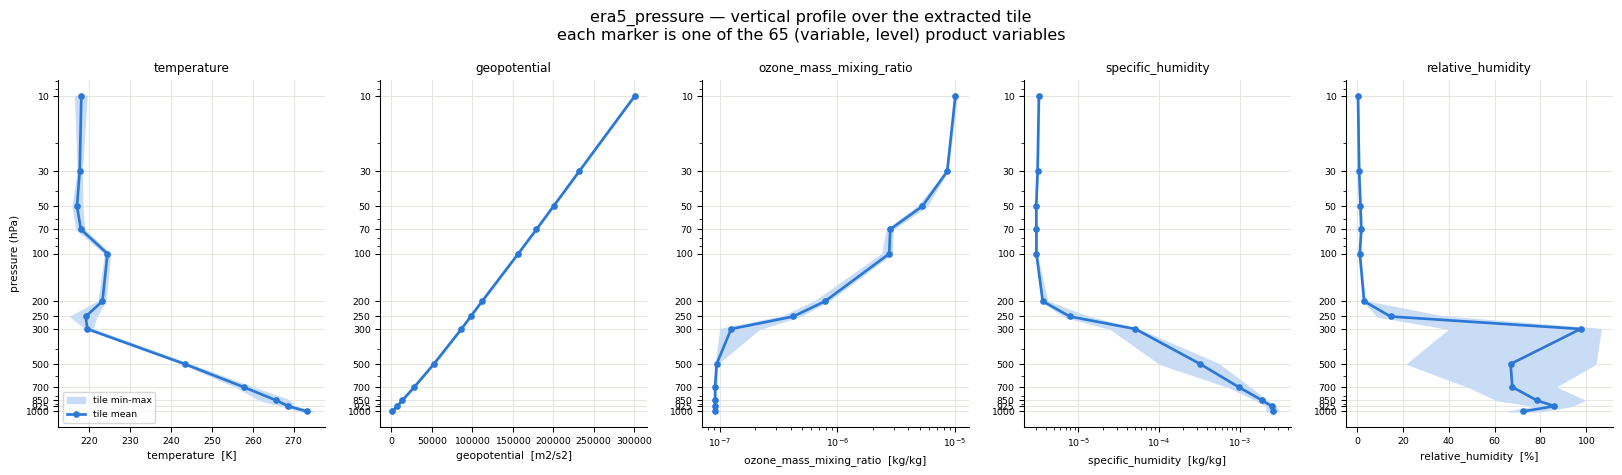

In [21]:
"""ERA5 pressure levels: the vertical profile — the clearest view of a 65-variable tile."""

if era5p_tile is not None:
    slices = dict(variable_slices(era5p_tile, "era5_pressure"))
    levels = np.array(_ERA5_PRESSURE_LEVELS, dtype=float)

    fig, axes = plt.subplots(1, 5, figsize=(17, 5))
    for ax, (base, _) in zip(axes, _ERA5_PRESSURE_LEVEL_VARIABLES):
        doc_units = _PRESSURE_BASE_DOC[base]["units"]
        means = np.array([np.nanmean(slices[f"{base}_{int(lev)}hPa"]) for lev in levels])
        mins = np.array([np.nanmin(slices[f"{base}_{int(lev)}hPa"]) for lev in levels])
        maxs = np.array([np.nanmax(slices[f"{base}_{int(lev)}hPa"]) for lev in levels])

        # Spread across the tile drawn as a band behind the mean profile: with only
        # 81 grid cells in a 2 deg tile the spread is small, which is itself the point
        # (these fields are smooth at tile scale).
        ax.fill_betweenx(levels, mins, maxs, color="#c9dcf5", label="tile min-max")
        ax.plot(means, levels, color="#2a78d6", linewidth=2.0, marker="o", markersize=4, label="tile mean")
        ax.set_yscale("log")
        ax.invert_yaxis()  # pressure decreases upward, so the sky is at the top
        ax.set_yticks(levels)
        ax.set_yticklabels([f"{int(lev)}" for lev in levels])
        ax.set_xlabel(f"{base}  [{doc_units}]")
        ax.set_title(base)
        ax.grid(color="#e5e5e2")
        ax.set_axisbelow(True)
        if base == "temperature":
            ax.set_ylabel("pressure (hPa)")
            ax.legend(loc="lower left")
        # Specific humidity and ozone span orders of magnitude between the surface
        # and the stratosphere, so a linear x-axis would flatten one end to zero.
        if base in ("specific_humidity", "ozone_mass_mixing_ratio"):
            ax.set_xscale("log")

    fig.suptitle(
        "era5_pressure — vertical profile over the extracted tile\n"
        "each marker is one of the 65 (variable, level) product variables"
    )
    fig.tight_layout()
    plt.show()

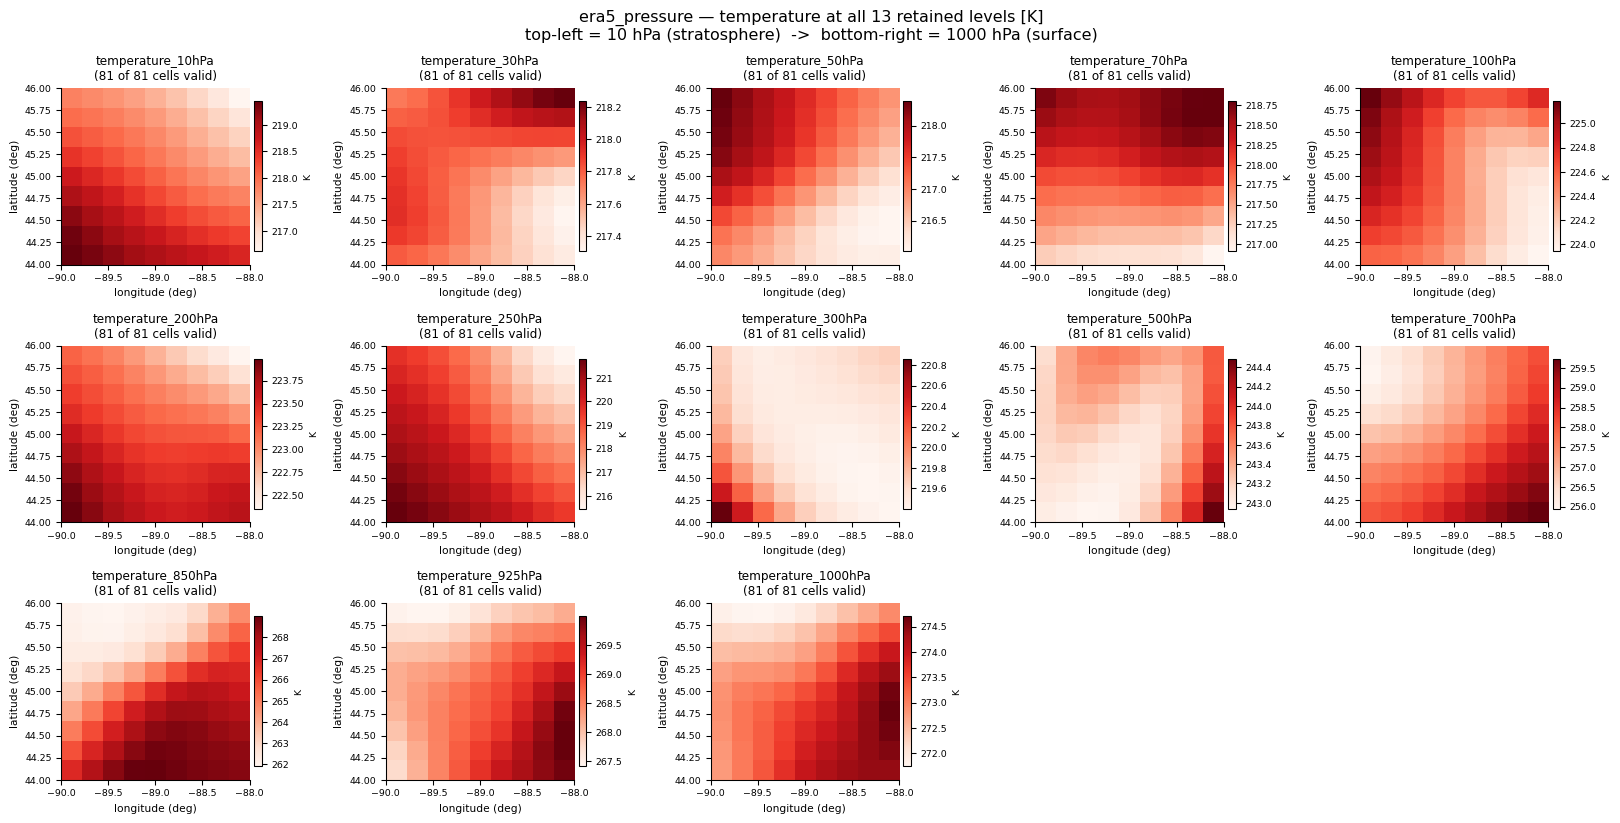

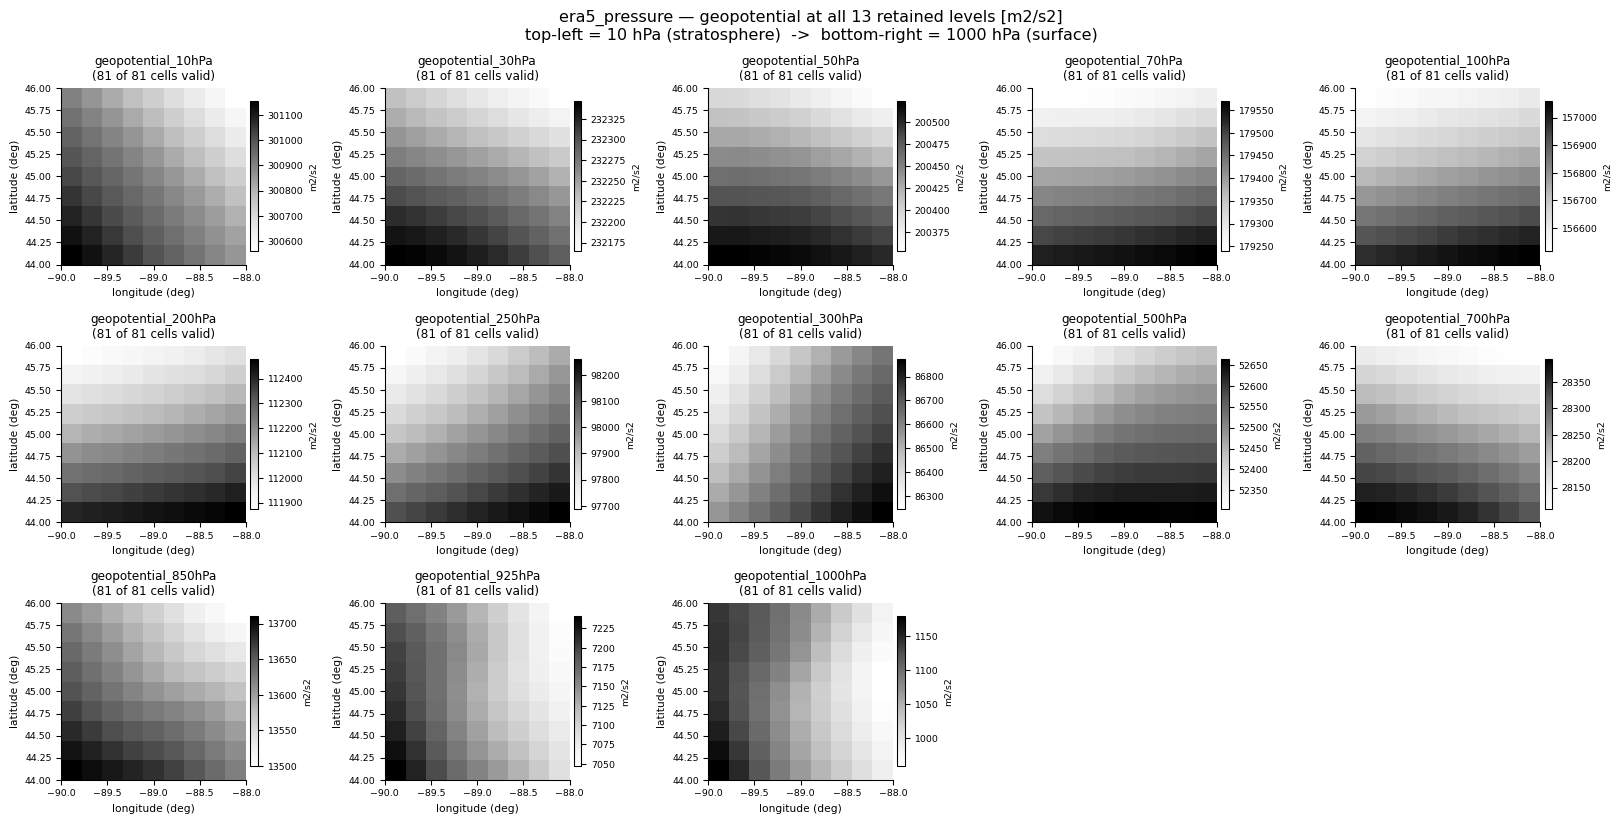

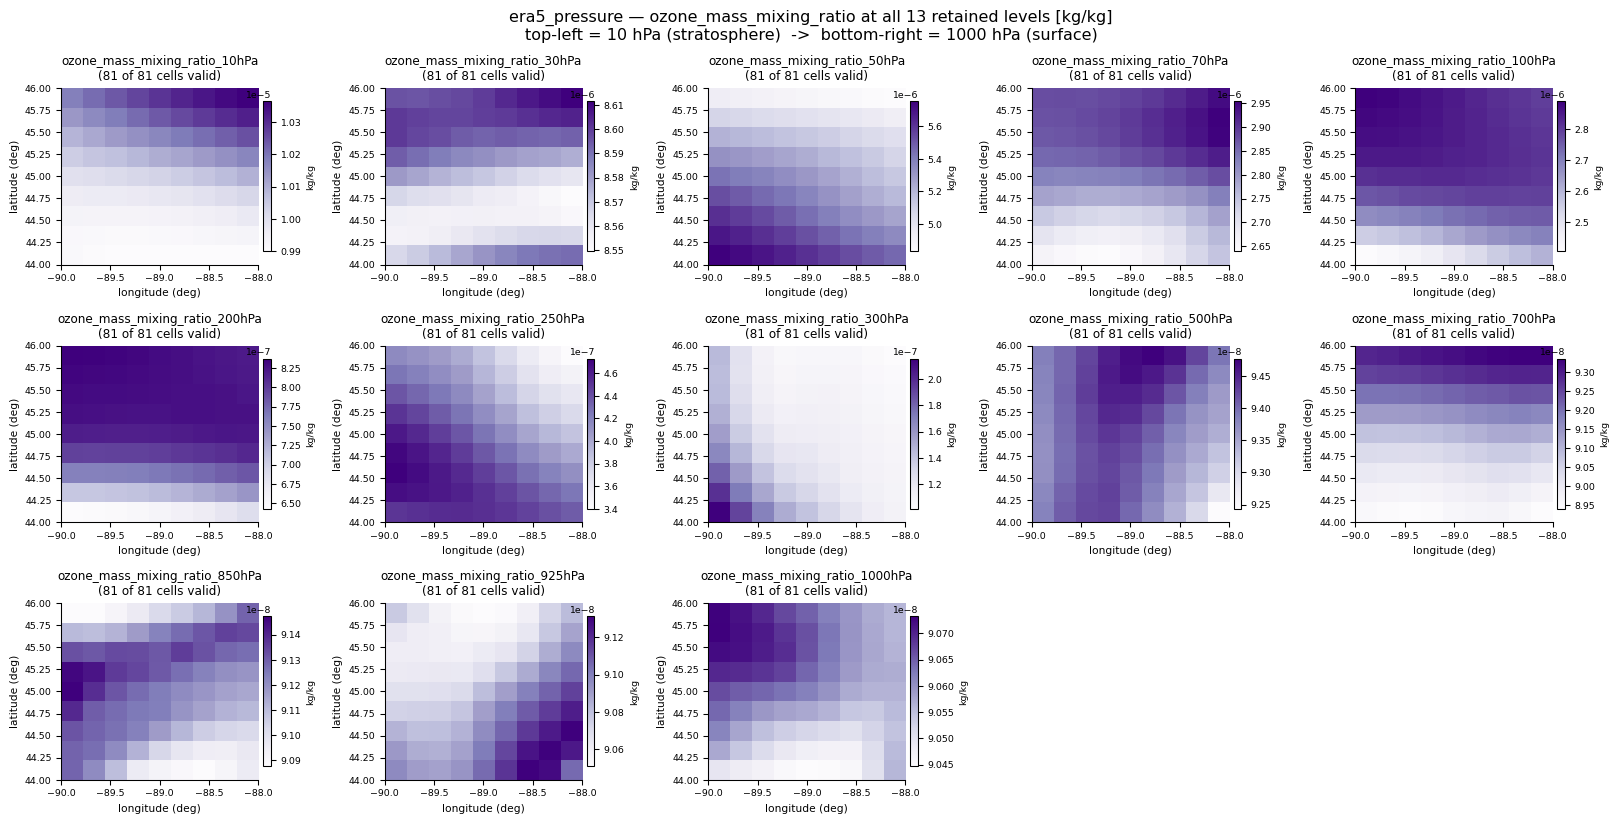

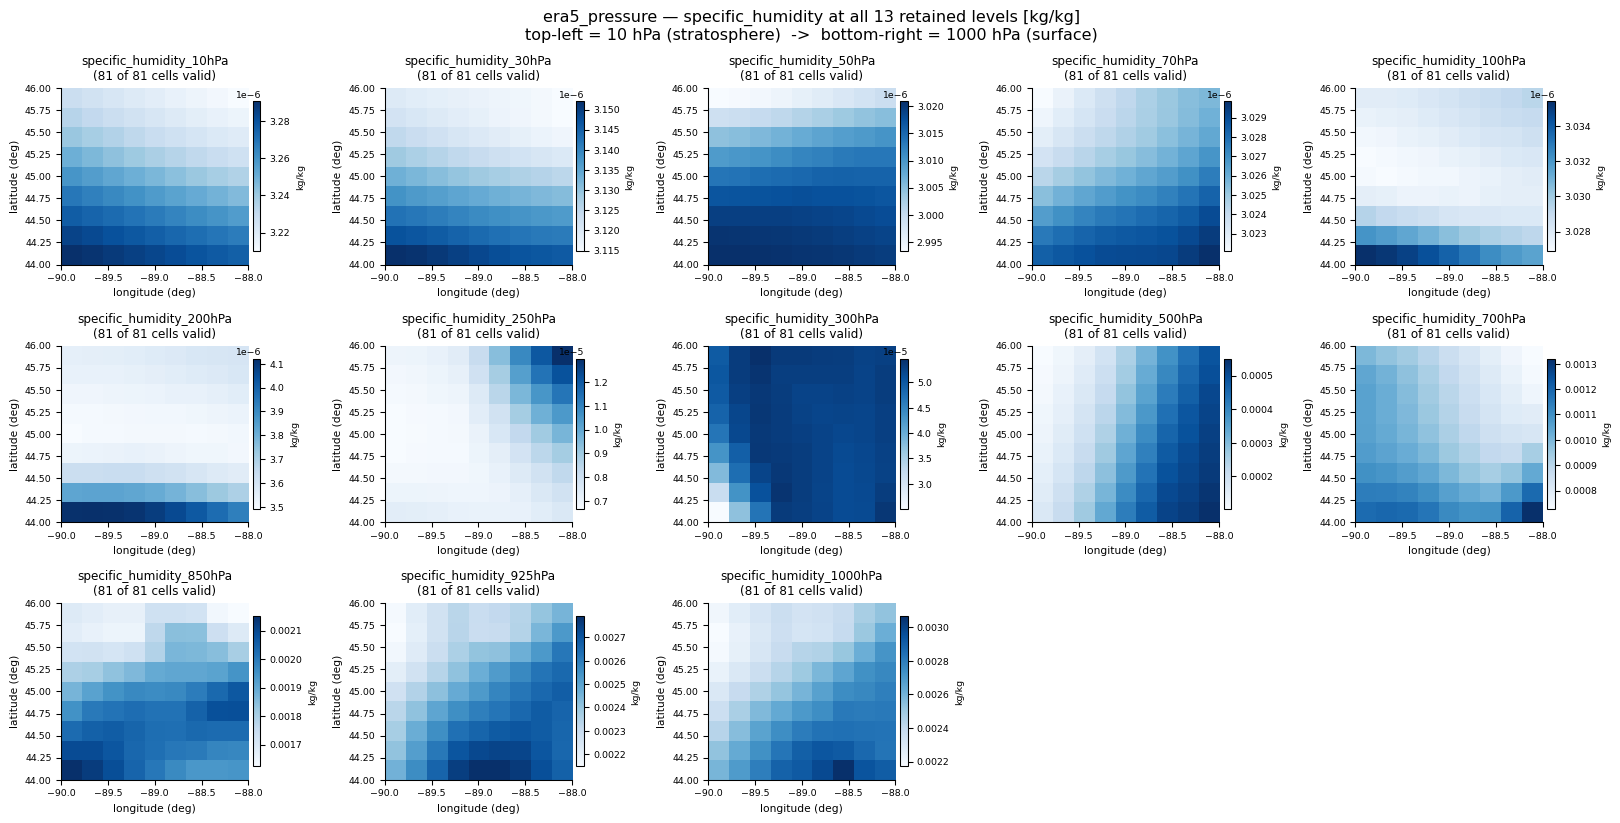

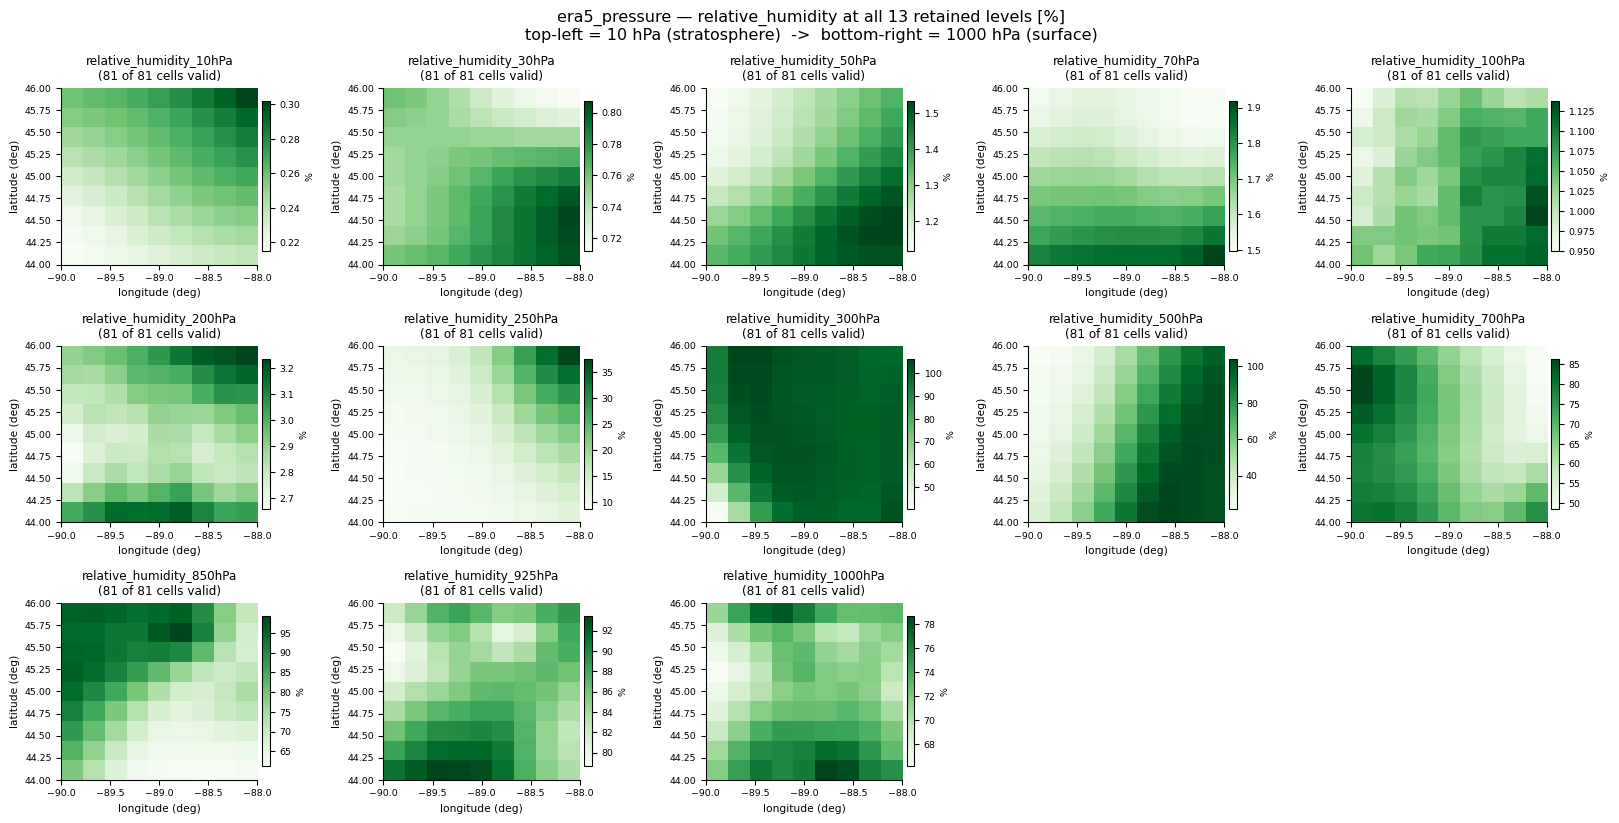

In [22]:
"""ERA5 pressure levels: every one of the 65 layers as a map, one figure per variable."""

if era5p_tile is not None:
    for base, _ in _ERA5_PRESSURE_LEVEL_VARIABLES:
        names = [f"{base}_{int(lev)}hPa" for lev in _ERA5_PRESSURE_LEVELS]
        plot_tile_variables(
            era5p_tile,
            "era5_pressure",
            names=names,
            ncols=5,
            panel_size=(3.4, 2.9),
            suptitle=(
                f"era5_pressure — {base} at all {len(names)} retained levels "
                f"[{_PRESSURE_BASE_DOC[base]['units']}]\n"
                "top-left = 10 hPa (stratosphere)  ->  bottom-right = 1000 hPa (surface)"
            ),
        )

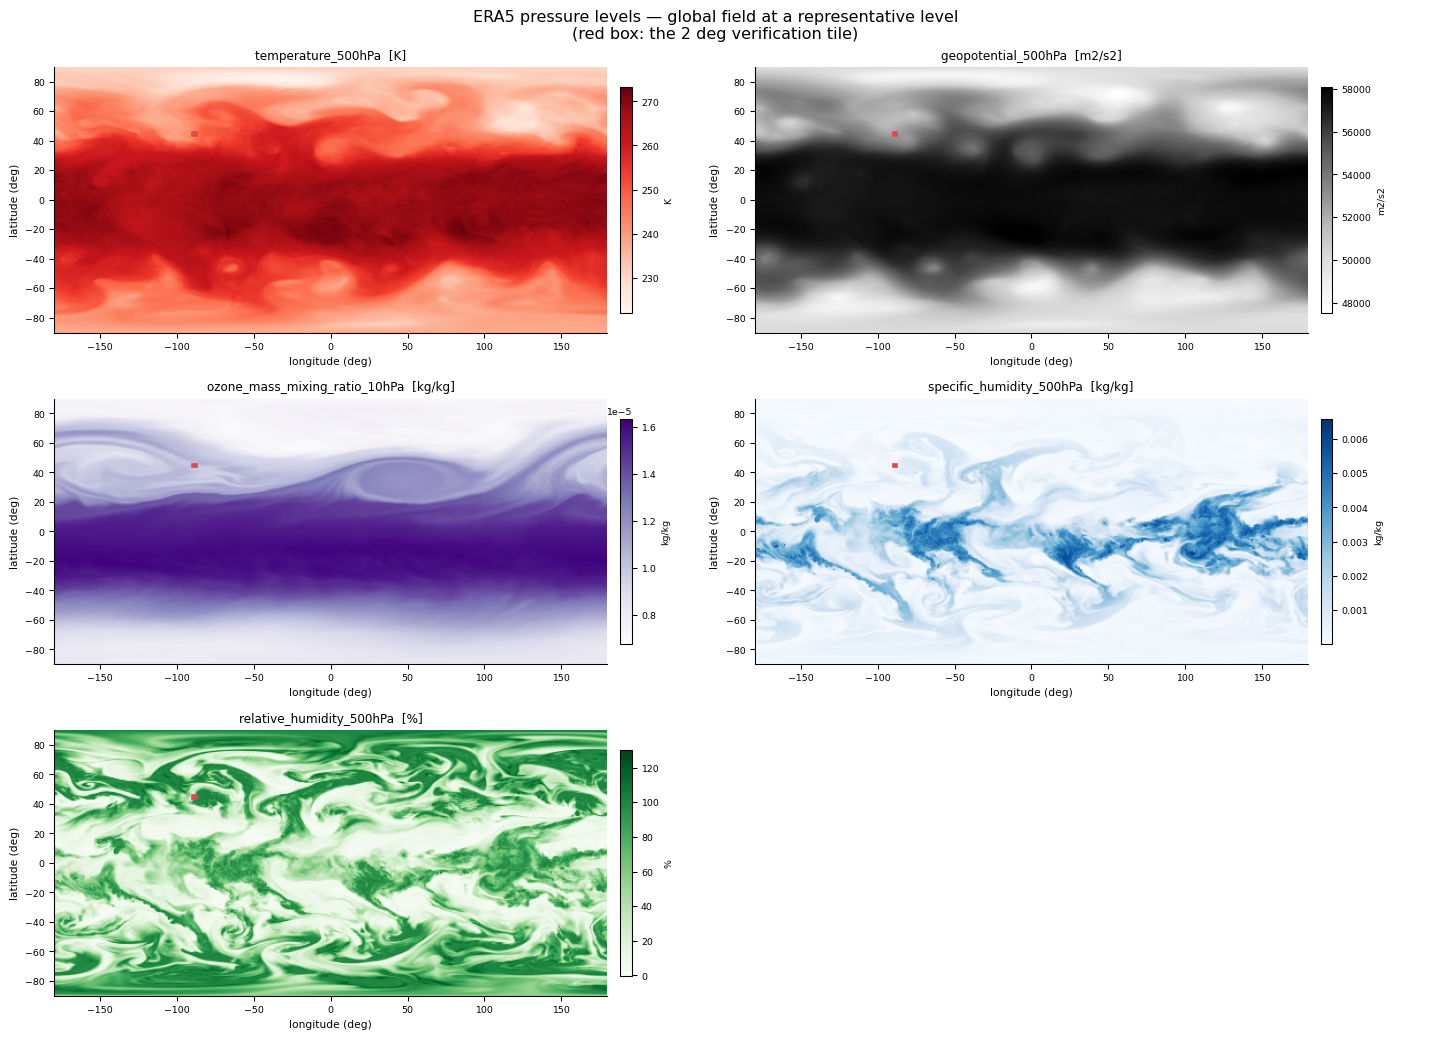

In [23]:
"""ERA5 pressure levels: the global field behind one representative level per variable."""

if era5p_tile is not None:
    global_data, global_lats, global_lons = READERS["era5_pressure"]._native_grid
    names = [spec.name for spec in ReaderRegistry.get("era5_pressure").VARIABLES]
    step = 3
    extent = [float(global_lons.min()), float(global_lons.max()), float(global_lats.min()), float(global_lats.max())]

    # 500 hPa is the conventional mid-troposphere reference level; ozone is shown at
    # 10 hPa instead because that is where the ozone layer actually lives.
    chosen = [(base, 10 if base == "ozone_mass_mixing_ratio" else 500) for base, _ in _ERA5_PRESSURE_LEVEL_VARIABLES]

    fig, axes = plt.subplots(3, 2, figsize=(15, 11))
    flat = axes.ravel()
    for ax, (base, level) in zip(flat, chosen):
        name = f"{base}_{level}hPa"
        doc = VARIABLE_DOC["era5_pressure"][name]
        plot_field(
            ax,
            global_data[names.index(name), ::step, ::step],
            extent,
            cmap=doc["cmap"],
            title=f"{name}  [{doc['units']}]",
            cbar_label=doc["units"],
        )
        draw_tile_box(ax, "era5_pressure", pad_label=False)
    flat[-1].axis("off")
    fig.suptitle("ERA5 pressure levels — global field at a representative level\n(red box: the 2 deg verification tile)")
    fig.tight_layout()
    plt.show()

---
# 9. Cloud properties — VIIRS `CLDPROP_D3`

**What it is.** Daily global cloud optical thickness and cloud-top pressure, from the VIIRS
imager on NOAA-20. Clouds dominate both the reflected shortwave and the emitted longwave
signal, so knowing how thick they are and how high they sit is central to interpreting a
radiometer footprint.

| | |
|---|---|
| **Product** | `CLDPROP_D3_VIIRS_NOAA20`, Collection 011 (daily Level-3 composite) |
| **Producer** | NOAA NCEI / NASA (Cloud Properties VIIRS CDR) |
| **Format** | NetCDF4 with **nested groups** (128 of them) |
| **Native resolution** | 1° × 1° (~111 km) — a 360 × 180 global grid |
| **Temporal** | daily composite |
| **File naming** | `CLDPROP_D3_VIIRS_NOAA20.A{YYYYDDD}.{collection}.{production}.nc` |
| **Product page** | <https://www.ncei.noaa.gov/products/climate-data-records/cloud-properties-viirs> |
| **Download** | <https://www.ncei.noaa.gov/data/cloud-properties-viirs/access/> |
| **Reader** | [`readers/viirs.py`](../libera_utils/footprint_matching/readers/viirs.py) |

## Internal structure

```
/                                   root
├── latitude   (180,)               1 deg bin centres, -89.5 .. 89.5
├── longitude  (360,)               1 deg bin centres, -179.5 .. 179.5
├── Cloud_Optical_Thickness_Combined/
│   ├── Mean   (360, 180)           <- read
│   ├── Standard_Deviation, Histogram_Counts, ... (not read)
└── Cloud_Top_Pressure/
    └── Mean   (360, 180)           <- read
```

Two structural details the reader has to handle:

* **Dimension order is `(longitude, latitude)`** — transposed relative to every other
  gridded product here — so each field is transposed to `(latitude, longitude)` on read.
* **Fill is `-9999.0`**, replaced with NaN.

Each group also carries `Standard_Deviation` and histogram layers that FMATCH does not read:
its own PSF aggregation computes the within-footprint spread, and a standard deviation of a
1° daily composite is not the same quantity.

## A note on scale

At 1° resolution a 2° FMATCH tile is only **2 × 2 cells**. This reader's data is far coarser
than the footprint it is being matched to — worth remembering when interpreting the
aggregated product.

In [24]:
"""VIIRS cloud: variable documentation."""

register_docs(
    "viirs_cloud",
    {
        "cloud_optical_thickness": {
            "source": "Cloud_Optical_Thickness_Combined/Mean",
            "units": "1",
            "valid": None,
            "cmap": "Oranges",
            "desc": (
                "Daily mean cloud optical thickness: how strongly the cloud attenuates a beam of "
                "light passing through it (dimensionless). Aggregated with weighted_LOG_mean, "
                "because optical depth enters radiative transfer exponentially (transmission ~ "
                "exp(-tau)) — a linear average of 1 and 100 would badly misrepresent the pair."
            ),
        },
        "cloud_top_pressure": {
            "source": "Cloud_Top_Pressure/Mean",
            "units": "hPa",
            "valid": None,
            "cmap": "Purples",
            "desc": (
                "Daily mean atmospheric pressure at the cloud top. LOW pressure means a HIGH, cold "
                "cloud, so the colour scale runs opposite to intuition about cloud height: ~200 hPa "
                "is deep convection, ~900 hPa is a shallow marine layer."
            ),
        },
    },
)
show_variable_table("viirs_cloud")

variable                        units       aggregation         source field
--------------------------------------------------------------------------------------------------------------
cloud_optical_thickness         1           weighted_log_mean   Cloud_Optical_Thickness_Combined/Mean
    Daily mean cloud optical thickness: how strongly the cloud attenuates a beam of light passing
    through it (dimensionless). Aggregated with weighted_LOG_mean, because optical depth enters
    radiative transfer exponentially (transmission ~ exp(-tau)) — a linear average of 1 and 100
    would badly misrepresent the pair.
cloud_top_pressure              hPa         weighted_mean       Cloud_Top_Pressure/Mean
    Daily mean atmospheric pressure at the cloud top. LOW pressure means a HIGH, cold cloud, so the
    colour scale runs opposite to intuition about cloud height: ~200 hPa is deep convection, ~900
    hPa is a shallow marine layer.



In [25]:
"""VIIRS cloud: inspect the group structure and the fields the reader targets."""

if FILES["viirs_cloud"] is not None:
    import netCDF4

    from libera_utils.footprint_matching.readers.viirs import _D3_FILL_VALUE, _D3_GROUP_MAP

    with netCDF4.Dataset(str(FILES["viirs_cloud"]), "r") as ds:
        print(f"file: {FILES['viirs_cloud'].name}")
        print(f"root variables: {list(ds.variables)}")
        print(f"groups in file: {len(ds.groups)}  (FMATCH reads {len(_D3_GROUP_MAP)})")
        print(f"\nreader fill value: {_D3_FILL_VALUE}")
        print("\nfields the reader targets:")
        for out_name, (group, var) in _D3_GROUP_MAP.items():
            variable = ds.groups[group].variables[var]
            attrs = {k: variable.getncattr(k) for k in variable.ncattrs()}
            print(f"   {out_name:<26} <- {group}/{var}")
            print(f"      stored shape {variable.shape} (longitude, latitude) — transposed on read")
            print(f"      units={attrs.get('units', '-')}  _FillValue={attrs.get('_FillValue', '-')}")
        print("\nother layers available in the same groups but NOT read:")
        for group, _ in _D3_GROUP_MAP.values():
            others = [v for v in ds.groups[group].variables if v != "Mean"]
            print(f"   {group}: {others[:6]}{' ...' if len(others) > 6 else ''}")
else:
    print("VIIRS cloud file not available.")

file: CLDPROP_D3_VIIRS_NOAA20.A2026147.011.2026151000710.nc
root variables: ['latitude', 'longitude']
groups in file: 128  (FMATCH reads 2)

reader fill value: -9999.0

fields the reader targets:
   cloud_optical_thickness    <- Cloud_Optical_Thickness_Combined/Mean
      stored shape (360, 180) (longitude, latitude) — transposed on read
      units=none  _FillValue=-9999.0
   cloud_top_pressure         <- Cloud_Top_Pressure/Mean
      stored shape (360, 180) (longitude, latitude) — transposed on read
      units=mb  _FillValue=-9999.0

other layers available in the same groups but NOT read:
   Cloud_Optical_Thickness_Combined: ['Standard_Deviation', 'Sum', 'Pixel_Counts', 'Sum_Squares', 'Histogram_Counts']
   Cloud_Top_Pressure: ['Standard_Deviation', 'Sum', 'Pixel_Counts', 'Sum_Squares', 'Histogram_Counts', 'JHisto_vs_Emissivity'] ...


[viirs_cloud] CLDPROP_D3_VIIRS_NOAA20.A2026147.011.2026151000710.nc
[viirs_cloud] tile TileKey(source='viirs_cloud', lat_idx=67, lon_idx=45) -> lat [44.0, 46.0], lon [-90.0, -88.0]
[viirs_cloud] loaded 2 variable(s), grid 2 x 2, 0.1 KiB, in 0.1 s
variable                        units        valid cells         min         max        mean         std
--------------------------------------------------------------------------------------------------------
cloud_optical_thickness         1                4 (100%)       3.654       15.43       8.213       4.619
cloud_top_pressure              hPa              4 (100%)       373.1       541.7       438.7       68.59



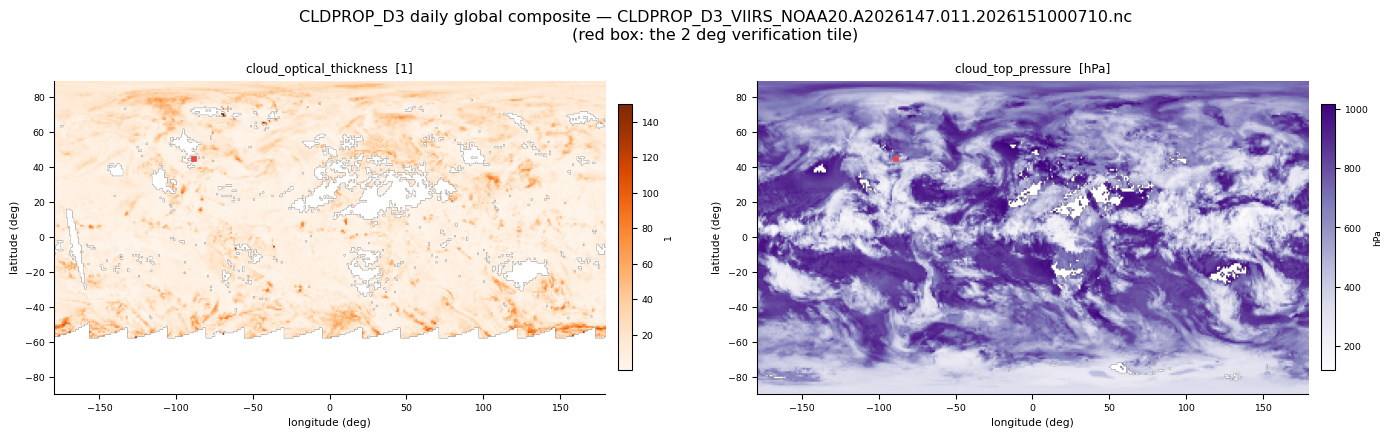

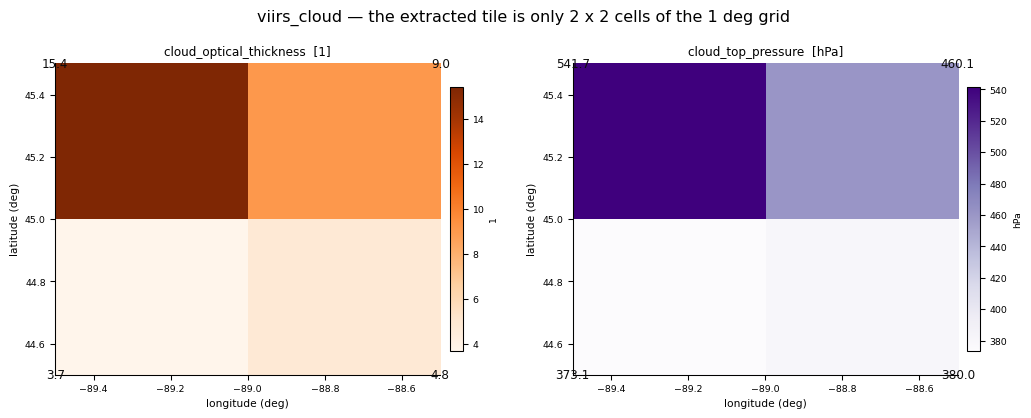

In [26]:
"""VIIRS cloud: load the tile, show the global composite, and annotate the 2x2 extraction."""

viirs_cloud_tile = load_reader_tile("viirs_cloud")
record_result("viirs_cloud", viirs_cloud_tile)

if viirs_cloud_tile is not None:
    tile_statistics(viirs_cloud_tile, "viirs_cloud")

    # --- whole-file view -----------------------------------------------------
    global_data, global_lats, global_lons = READERS["viirs_cloud"]._native_grid
    extent = [float(global_lons.min()), float(global_lons.max()), float(global_lats.min()), float(global_lats.max())]
    specs = ReaderRegistry.get("viirs_cloud").VARIABLES

    fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
    for ax, (i, spec) in zip(axes, enumerate(specs)):
        doc = VARIABLE_DOC["viirs_cloud"][spec.name]
        plot_field(ax, global_data[i], extent, doc["cmap"], f"{spec.name}  [{doc['units']}]", doc["units"])
        draw_tile_box(ax, "viirs_cloud", pad_label=False)
    fig.suptitle(f"CLDPROP_D3 daily global composite — {FILES['viirs_cloud'].name}\n(red box: the 2 deg verification tile)")
    fig.tight_layout()
    plt.show()

    # --- extracted tile ------------------------------------------------------
    # At 1 deg resolution the tile is 2 x 2 cells, so the individual values are
    # printed onto the panels: with four cells, the numbers are the data.
    tile_extent = _extent_of(viirs_cloud_tile)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
    for ax, (name, arr) in zip(axes, variable_slices(viirs_cloud_tile, "viirs_cloud")):
        doc = VARIABLE_DOC["viirs_cloud"][name]
        plot_field(ax, arr, tile_extent, doc["cmap"], f"{name}  [{doc['units']}]", doc["units"])
        for row, lat in enumerate(viirs_cloud_tile.lats):
            for col, lon in enumerate(viirs_cloud_tile.lons):
                ax.text(lon, lat, f"{arr[row, col]:.1f}", ha="center", va="center", fontsize=9, color="#0b0b0b")
    fig.suptitle("viirs_cloud — the extracted tile is only 2 x 2 cells of the 1 deg grid")
    fig.tight_layout()
    plt.show()

---
# 10. Surface reflectance anisotropy — VIIRS `VJ143C1` BRDF

**What it is.** Real surfaces do not reflect sunlight equally in all directions: a forest
looks darker when you view it from the sun's side and brighter when you look along the shadow
direction. The **BRDF** (bidirectional reflectance distribution function) describes that
angular dependence, and it is exactly what turns a radiance measured from one viewing angle
into a flux integrated over all angles.

| | |
|---|---|
| **Product** | `VJ143C1` Collection 002, *VIIRS/NOAA-20 BRDF/Albedo Model Parameters Daily L3 Global 0.05° CMG* |
| **Producer** | NASA LP DAAC |
| **Format** | HDF5 / HDF-EOS5 (`.h5`), read with `h5py` |
| **Native resolution** | 0.05° (~5.6 km) — a 3600 × 7200 Climate Modeling Grid |
| **Temporal** | daily, using 16 days of accumulated observations |
| **File naming** | `VJ143C1.A{YYYYDDD}.{version}.{production}.h5` |
| **Product page** | <https://www.earthdata.nasa.gov/data/catalog/lpcloud-vj143c1-002> |
| **User guide** | <https://lpdaac.usgs.gov/documents/194/VNP43_User_Guide_V2.pdf> |
| **Download** | <https://e4ftl01.cr.usgs.gov/VIIRS/VJ143C1.002/> (Earthdata login required) |
| **Reader** | [`readers/brdf.py`](../libera_utils/footprint_matching/readers/brdf.py) |

## The RTLS model

VJ143C1 does not store reflectance; it stores the three coefficients of the semi-empirical
**RossThick–LiSparse** kernel model, which reconstructs reflectance at any sun/view geometry:

$$R(\theta_s, \theta_v, \phi) = f_{iso} + f_{vol}\,K_{vol}(\theta_s,\theta_v,\phi) + f_{geo}\,K_{geo}(\theta_s,\theta_v,\phi)$$

* $f_{iso}$ — **isotropic**: the Lambertian part, reflectance if the surface scattered equally in all directions.
* $f_{vol}$ — **volumetric** (RossThick kernel): multiple scattering within a dense leaf canopy.
* $f_{geo}$ — **geometric** (LiSparse kernel): shadowing and mutual obscuration of discrete objects (crowns, ridges).

Three coefficients × three broadbands (**shortwave**, **visible**, **near-infrared**) = the
nine variables FMATCH reads.

## Internal structure

```
HDFEOS/GRIDS/VIIRS_CMG_BRDF/Data Fields/
├── BRDF_Albedo_Parameter1_shortwave   (3600, 7200) int16   -> brdf_shortwave_fiso
├── BRDF_Albedo_Parameter2_shortwave                        -> brdf_shortwave_fvol
├── BRDF_Albedo_Parameter3_shortwave                        -> brdf_shortwave_fgeo
├── ... the same three for _vis and _nir ...
└── ~30 further per-band fields (M1..M11, DNB) that FMATCH does not read
```

Parameter**1/2/3** are $f_{iso}$/$f_{vol}$/$f_{geo}$ respectively. Values are stored as
**int16 with `scale_factor = 0.001`** and fill **32767**; the reader applies the scale and
converts fill to NaN. The file stores latitude **descending** (90 → −90) and the reader flips
it to ascending.

**Cost warning.** The reader caches the *entire* global grid for all nine fields
(9 × 3600 × 7200 float32 ≈ 0.9 GB) on first use, so the first tile load is slow. That is a
deliberate trade: subsequent tiles are pure in-memory slicing.

In [27]:
"""VIIRS BRDF: variable documentation, generated from the band x parameter grid."""

from libera_utils.footprint_matching.readers.brdf import _BRDF_DATA_PATH, _BRDF_FIELD_MAP

_BAND_DESC = {
    "shortwave": "the broadband shortwave range (0.3-5.0 um) — the band that matters most for the total reflected solar flux",
    "vis": "the visible broadband (0.4-0.7 um), where vegetation is dark and snow is bright",
    "nir": "the near-infrared broadband (0.7-5.0 um), where healthy vegetation is bright",
}
_PARAM_DESC = {
    "fiso": (
        "isotropic (Lambertian) weight — the reflectance the surface would have if it scattered "
        "equally in every direction. Typically the largest of the three coefficients"
    ),
    "fvol": (
        "volumetric weight (RossThick kernel) — multiple scattering inside a dense canopy. Large "
        "over forest and crops, near zero over bare rock and water"
    ),
    "fgeo": (
        "geometric weight (LiSparse kernel) — shadowing and mutual obscuration between discrete "
        "objects such as tree crowns. Largest over sparse, rough surfaces"
    ),
}

register_docs(
    "viirs_brdf",
    {
        name: {
            "source": f"{field} (int16, scale 0.001)",
            "units": "1",
            "valid": (0.0, 32.766),
            "cmap": "Greens",
            "desc": (
                f"RTLS {_PARAM_DESC[name.split('_')[-1]]}, for {_BAND_DESC[name.split('_')[1]]}. "
                "Dimensionless; PSF-weighted mean is appropriate because the RTLS model is linear "
                "in these coefficients, so averaging the coefficients equals averaging the surfaces."
            ),
        }
        for name, field in _BRDF_FIELD_MAP.items()
    },
)
print(f"HDF5 group read: {_BRDF_DATA_PATH}\n")
show_variable_table("viirs_brdf")

HDF5 group read: HDFEOS/GRIDS/VIIRS_CMG_BRDF/Data Fields

variable                        units       aggregation         source field
--------------------------------------------------------------------------------------------------------------
brdf_shortwave_fiso             1           weighted_mean       BRDF_Albedo_Parameter1_shortwave (int16, scale 0.001)
    RTLS isotropic (Lambertian) weight — the reflectance the surface would have if it scattered
    equally in every direction. Typically the largest of the three coefficients, for the broadband
    shortwave range (0.3-5.0 um) — the band that matters most for the total reflected solar flux.
    Dimensionless; PSF-weighted mean is appropriate because the RTLS model is linear in these
    coefficients, so averaging the coefficients equals averaging the surfaces.
brdf_shortwave_fvol             1           weighted_mean       BRDF_Albedo_Parameter2_shortwave (int16, scale 0.001)
    RTLS volumetric weight (RossThick kernel) — mult

In [28]:
"""VIIRS BRDF: inspect the HDF5 layout, scaling attributes, and available bands."""

if FILES["viirs_brdf"] is not None:
    import h5py

    with h5py.File(str(FILES["viirs_brdf"]), "r") as f:
        group = f[_BRDF_DATA_PATH]
        all_fields = sorted(group.keys())
        print(f"file: {FILES['viirs_brdf'].name}")
        print(f"fields in {_BRDF_DATA_PATH}: {len(all_fields)}")
        print(f"   FMATCH reads {len(_BRDF_FIELD_MAP)} of them (3 parameters x 3 broadbands)")

        # Which spectral suffixes exist? Shows the narrowband M-bands FMATCH skips.
        suffixes = sorted({name.split("_")[-1] for name in all_fields if name.startswith("BRDF_Albedo_Parameter")})
        print(f"   available band suffixes: {suffixes}")

        dataset = group["BRDF_Albedo_Parameter1_shortwave"]
        print(f"\nBRDF_Albedo_Parameter1_shortwave: shape {dataset.shape}, dtype {dataset.dtype}")
        for key in ("long_name", "units", "scale_factor", "add_offset", "_FillValue", "valid_range"):
            if key in dataset.attrs:
                value = dataset.attrs[key]
                value = value.decode() if isinstance(value, bytes) else value
                print(f"   {key:<14} = {value}")
        print("\nStored as int16 to save space: physical value = raw * scale_factor.")
        print(f"Full global grid for all 9 fields ~ {9 * np.prod(dataset.shape) * 4 / 2**30:.2f} GiB as float32.")
else:
    print("VIIRS BRDF file not available.")

file: VJ143C1.A2026153.002.2026161161054.h5
fields in HDFEOS/GRIDS/VIIRS_CMG_BRDF/Data Fields: 46
   FMATCH reads 9 of them (3 parameters x 3 broadbands)
   available band suffixes: ['DNB', 'M1', 'M10', 'M11', 'M2', 'M3', 'M4', 'M5', 'M7', 'M8', 'nir', 'shortwave', 'vis']

BRDF_Albedo_Parameter1_shortwave: shape (3600, 7200), dtype int16
   long_name      = Global_BRDF_Albedo_Parameter1_shortwave
   units          = parameter, no units
   scale_factor   = [0.001]
   add_offset     = [0.]
   _FillValue     = [32767]
   valid_range    = [    0 32766]

Stored as int16 to save space: physical value = raw * scale_factor.
Full global grid for all 9 fields ~ 0.87 GiB as float32.


In [29]:
"""VIIRS BRDF: load the tile (first read caches the whole global grid — this is the slow one)."""

brdf_tile = load_reader_tile("viirs_brdf")
record_result("viirs_brdf", brdf_tile)

if brdf_tile is not None:
    tile_statistics(brdf_tile, "viirs_brdf")

[viirs_brdf] VJ143C1.A2026153.002.2026161161054.h5
[viirs_brdf] tile TileKey(source='viirs_brdf', lat_idx=67, lon_idx=45) -> lat [44.0, 46.0], lon [-90.0, -88.0]


[viirs_brdf] loaded 9 variable(s), grid 41 x 41, 59.7 KiB, in 2.0 s
variable                        units        valid cells         min         max        mean         std
--------------------------------------------------------------------------------------------------------
brdf_shortwave_fiso             1            1,681 (100%)       0.017        0.23      0.1591     0.02595
brdf_shortwave_fvol             1            1,681 (100%)       0.005       0.264      0.1042     0.02596
brdf_shortwave_fgeo             1            1,681 (100%)           0       0.045     0.02382    0.006042
brdf_vis_fiso                   1            1,681 (100%)       0.026       0.122     0.05378     0.01991
brdf_vis_fvol                   1            1,681 (100%)       0.005       0.136     0.03579     0.01448
brdf_vis_fgeo                   1            1,681 (100%)           0       0.029    0.009012    0.004838
brdf_nir_fiso                   1            1,681 (100%)           0       0.354     

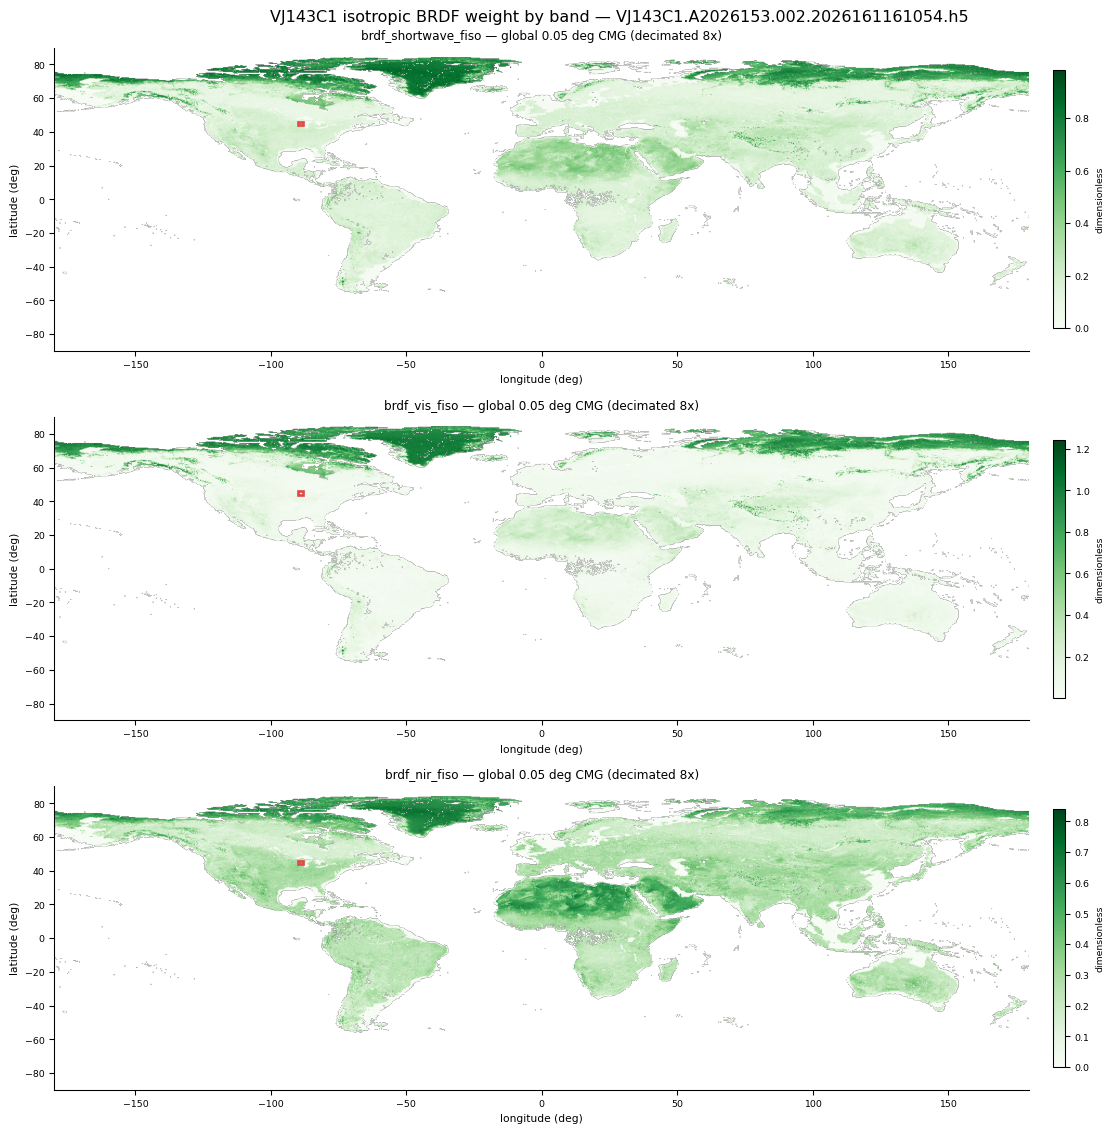

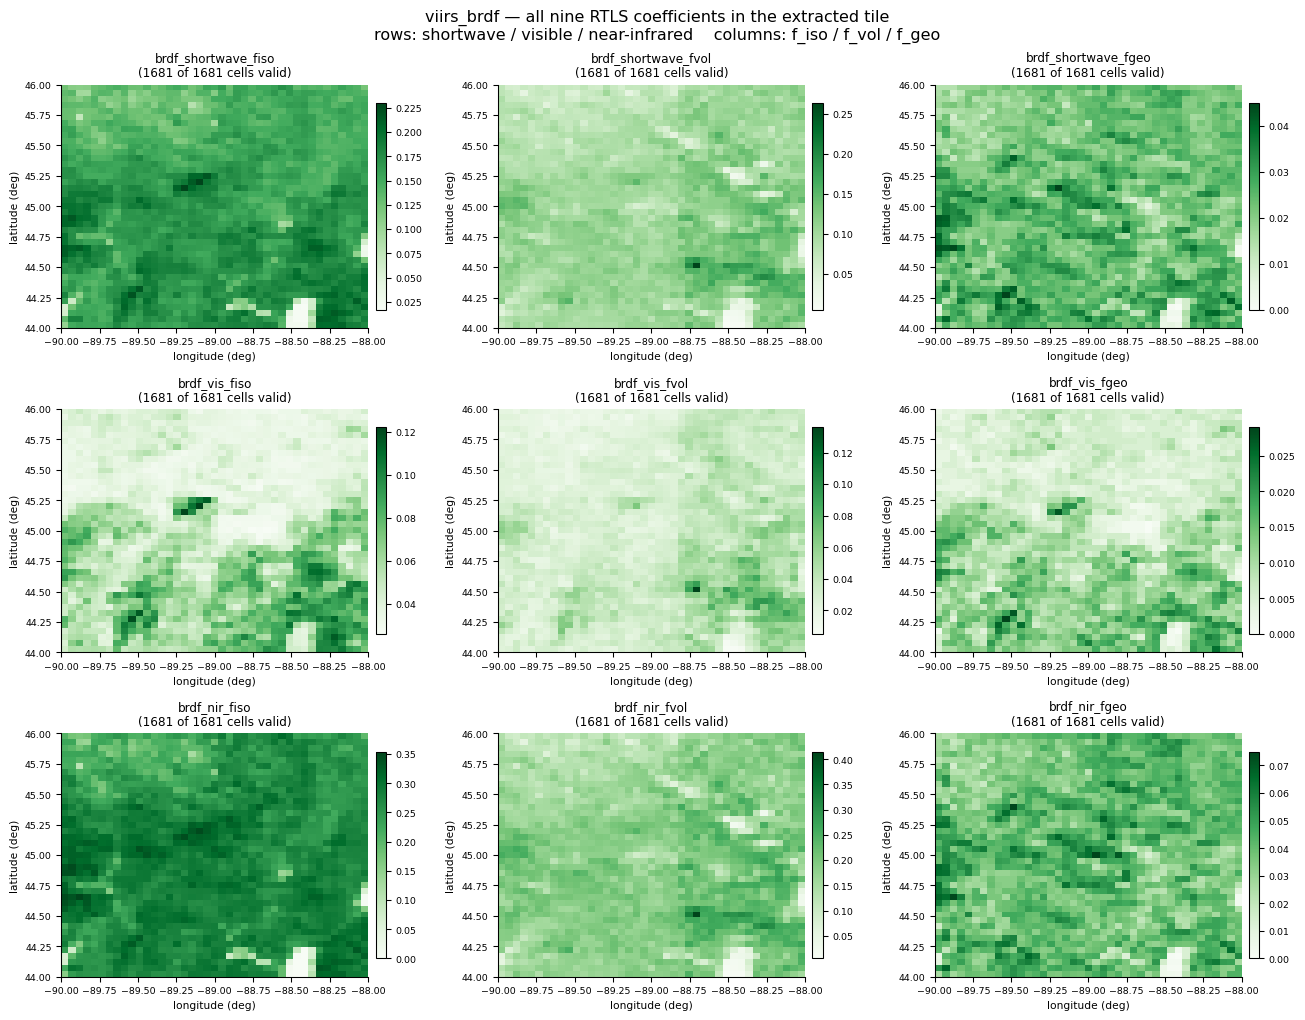

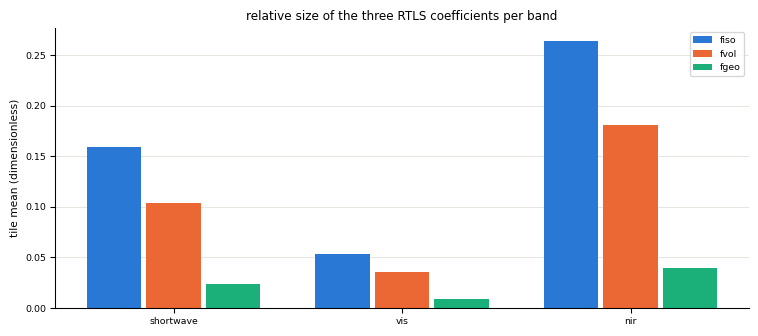

In [30]:
"""VIIRS BRDF: the global field for one parameter, then all nine in the extracted tile."""

if brdf_tile is not None:
    global_data, global_lats, global_lons = READERS["viirs_brdf"]._native_grid
    names = [spec.name for spec in ReaderRegistry.get("viirs_brdf").VARIABLES]
    step = 8  # 3600 x 7200 -> 450 x 900, plenty for a global overview
    extent = [float(global_lons.min()), float(global_lons.max()), float(global_lats.min()), float(global_lats.max())]

    # One global panel per band for the isotropic coefficient: it is the dominant
    # term, and the three bands together show the classic vegetation signature
    # (dark in the visible, bright in the near-infrared).
    fig, axes = plt.subplots(3, 1, figsize=(13, 12))
    for ax, band in zip(axes, ("shortwave", "vis", "nir")):
        name = f"brdf_{band}_fiso"
        plot_field(
            ax,
            global_data[names.index(name), ::step, ::step],
            extent,
            "Greens",
            f"{name} — global 0.05 deg CMG (decimated {step}x)",
            "dimensionless",
        )
        draw_tile_box(ax, "viirs_brdf", pad_label=False)
    fig.suptitle(f"VJ143C1 isotropic BRDF weight by band — {FILES['viirs_brdf'].name}")
    fig.tight_layout()
    plt.show()

    # All nine variables in the tile, laid out band x parameter so the structure of
    # the RTLS model is visible in the figure itself.
    plot_tile_variables(
        brdf_tile,
        "viirs_brdf",
        names=[f"brdf_{band}_{param}" for band in ("shortwave", "vis", "nir") for param in ("fiso", "fvol", "fgeo")],
        ncols=3,
        suptitle=(
            "viirs_brdf — all nine RTLS coefficients in the extracted tile\n"
            "rows: shortwave / visible / near-infrared    columns: f_iso / f_vol / f_geo"
        ),
    )

    # The coefficients are not independent: f_vol and f_geo are usually a small
    # fraction of f_iso. Comparing their tile means is a quick physical plausibility
    # check on the scale factor having been applied correctly.
    slices = dict(variable_slices(brdf_tile, "viirs_brdf"))
    fig, ax = plt.subplots(figsize=(8, 3.6))
    bands = ("shortwave", "vis", "nir")
    width = 0.26
    positions = np.arange(len(bands))
    for i, param in enumerate(("fiso", "fvol", "fgeo")):
        values = [float(np.nanmean(slices[f"brdf_{band}_{param}"])) for band in bands]
        ax.bar(positions + (i - 1) * width, values, width=width * 0.92, color=CATEGORICAL_SLOTS[i], label=param)
    ax.set_xticks(positions)
    ax.set_xticklabels(bands)
    ax.set_ylabel("tile mean (dimensionless)")
    ax.set_title("relative size of the three RTLS coefficients per band")
    ax.legend()
    ax.grid(axis="y", color="#e5e5e2")
    ax.set_axisbelow(True)
    fig.tight_layout()
    plt.show()

---
# 11. Aerosol optical depth — `AERDB_D3_GEOLEO_Merged`

**What it is.** How much dust, smoke, sea salt and pollution sits in the atmospheric column.
Aerosol scatters and absorbs sunlight, so a footprint's shortwave signal depends on it even
under clear skies.

| | |
|---|---|
| **Product** | `AERDB_D3_GEOLEO_Merged` Collection 001 — Deep Blue GEO-LEO merged daily Level-3 AOD |
| **Producer** | NASA (Deep Blue / SOAR algorithms) |
| **Format** | NetCDF4, **one group per contributing sensor** |
| **Native resolution** | 1° × 1° (~111 km) — 360 × 180 global grid |
| **File naming** | `AERDB_D3_GEOLEO_Merged.A{YYYYDDD}.{collection}.{production}.nc` |
| **Deep Blue** | <https://deepblue.gsfc.nasa.gov/> |
| **VIIRS aerosols** | <https://www.earthdata.nasa.gov/data/instruments/viirs> |
| **Reader** | [`readers/aod.py`](../libera_utils/footprint_matching/readers/aod.py) |

## Internal structure, and which group to read

```
/
├── Latitude   (180,)   ascending, -89.5 .. 89.5
├── Longitude  (360,)   -179.5 .. 179.5
├── NOAA20_VIIRS/       <- FMATCH reads this group
│   └── Aerosol_Optical_Thickness_550_Land_Ocean  (180, 360)
├── SNPP_VIIRS/  Aqua_MODIS/  Terra_MODIS/  G16_ABI/  G17_ABI/  H08_AHI/
└── Merged/             cross-sensor best estimate — deliberately NOT used
```

The file offers a `Merged` field that fuses all seven sensors, but FMATCH-IMAGER requires a
**single, well-characterized VIIRS sensor** (DPI v87: *"AOD (NOAA-21 initially; NOAA-22 VIIRS
when available)"*). NOAA-20 is the VIIRS sensor present in current granules, so the reader
reads `NOAA20_VIIRS`; switching sensors later is a one-constant change (`_AOD_SENSOR_GROUP`).

Unlike the CLDPROP_D3 cloud product, variables here are stored `(Latitude, Longitude)` —
**no transpose needed**. Fill is `-999.0`, and the declared valid range is `[0, 5]`.

**Aerosol *type* is not in this product.** It comes from the CERES SSF product, so this
reader exposes optical depth only.

In [31]:
"""VIIRS AOD: variable documentation."""

from libera_utils.footprint_matching.readers.aod import _AOD_SENSOR_GROUP, _AOD_VALID_MAX, _AOD_VARIABLE

register_docs(
    "viirs_aod",
    {
        "aod_550": {
            "source": f"{_AOD_SENSOR_GROUP}/{_AOD_VARIABLE}",
            "units": "1",
            "valid": (0.0, _AOD_VALID_MAX),
            "cmap": "Oranges",
            "desc": (
                "Aerosol optical depth at 550 nm over land and ocean: the vertically integrated "
                "extinction of the aerosol column, dimensionless. ~0.05 is very clean air, ~0.5 is "
                "hazy, >1 is heavy smoke or dust. Aggregated with weighted_LOG_mean because "
                "extinction is exponential in optical depth."
            ),
        }
    },
)
show_variable_table("viirs_aod")

variable                        units       aggregation         source field
--------------------------------------------------------------------------------------------------------------
aod_550                         1           weighted_log_mean   NOAA20_VIIRS/Aerosol_Optical_Thickness_550_Land_Ocean
    Aerosol optical depth at 550 nm over land and ocean: the vertically integrated extinction of
    the aerosol column, dimensionless. ~0.05 is very clean air, ~0.5 is hazy, >1 is heavy smoke or
    dust. Aggregated with weighted_LOG_mean because extinction is exponential in optical depth.



In [32]:
"""VIIRS AOD: inspect the per-sensor group layout and compare sensor coverage."""

if FILES["viirs_aod"] is not None:
    import netCDF4

    with netCDF4.Dataset(str(FILES["viirs_aod"]), "r") as ds:
        print(f"file: {FILES['viirs_aod'].name}")
        print(f"root variables: {list(ds.variables)}")
        print(f"sensor groups : {list(ds.groups)}")
        print(f"\nFMATCH reads: {_AOD_SENSOR_GROUP}/{_AOD_VARIABLE}")
        variable = ds.groups[_AOD_SENSOR_GROUP].variables[_AOD_VARIABLE]
        attrs = {k: variable.getncattr(k) for k in variable.ncattrs()}
        print(f"   shape {variable.shape} (Latitude, Longitude) — no transpose needed")
        for key in ("long_name", "units", "_FillValue", "valid_range"):
            if key in attrs:
                print(f"   {key:<12} = {attrs[key]}")

        print(f"\nother variables in the {_AOD_SENSOR_GROUP} group (uncertainty, counts, land/ocean splits):")
        for name in list(ds.groups[_AOD_SENSOR_GROUP].variables):
            print(f"   {name}")

        # How much of the globe each sensor actually sees on this day — the reason
        # the merged product exists, and the reason FMATCH still wants one sensor.
        print(f"\nvalid 1-degree cells per sensor group (of {180 * 360}):")
        for group_name in ds.groups:
            group_vars = ds.groups[group_name].variables
            if _AOD_VARIABLE not in group_vars:
                continue
            values = np.asarray(group_vars[_AOD_VARIABLE][:], dtype=float)
            values[values == -999.0] = np.nan
            n_valid = int(np.isfinite(values).sum())
            marker = "  <- read by FMATCH" if group_name == _AOD_SENSOR_GROUP else ""
            print(f"   {group_name:<16}{n_valid:>8,}  ({100.0 * n_valid / values.size:>5.1f}%){marker}")
else:
    print("VIIRS AOD file not available.")

file: AERDB_D3_GEOLEO_Merged.A2020121.001.2024121023016.nc
root variables: ['Latitude', 'Longitude']
sensor groups : ['Aqua_MODIS', 'G16_ABI', 'G17_ABI', 'H08_AHI', 'Merged', 'NOAA20_VIIRS', 'SNPP_VIIRS', 'Terra_MODIS']

FMATCH reads: NOAA20_VIIRS/Aerosol_Optical_Thickness_550_Land_Ocean
   shape (180, 360) (Latitude, Longitude) — no transpose needed
   long_name    = Mean of Deep Blue AOT at 0.55 micron over land and ocean
   units        = None
   _FillValue   = -999.0
   valid_range  = [0 5]

other variables in the NOAA20_VIIRS group (uncertainty, counts, land/ocean splits):
   Aerosol_Optical_Thickness_550_Count_Land
   Aerosol_Optical_Thickness_550_Count_Land_Ocean
   Aerosol_Optical_Thickness_550_Count_Ocean
   Aerosol_Optical_Thickness_550_Expected_Uncertainty_Land
   Aerosol_Optical_Thickness_550_Expected_Uncertainty_Land_Ocean
   Aerosol_Optical_Thickness_550_Expected_Uncertainty_Ocean
   Aerosol_Optical_Thickness_550_Land
   Aerosol_Optical_Thickness_550_Land_Ocean
   Aerosol

[viirs_aod] AERDB_D3_GEOLEO_Merged.A2020121.001.2024121023016.nc
[viirs_aod] tile TileKey(source='viirs_aod', lat_idx=67, lon_idx=45) -> lat [44.0, 46.0], lon [-90.0, -88.0]
[viirs_aod] loaded 1 variable(s), grid 2 x 2, 0.0 KiB, in 0.0 s
variable                        units        valid cells         min         max        mean         std
--------------------------------------------------------------------------------------------------------
aod_550                         1                4 (100%)     0.03871     0.06725     0.05315     0.01108



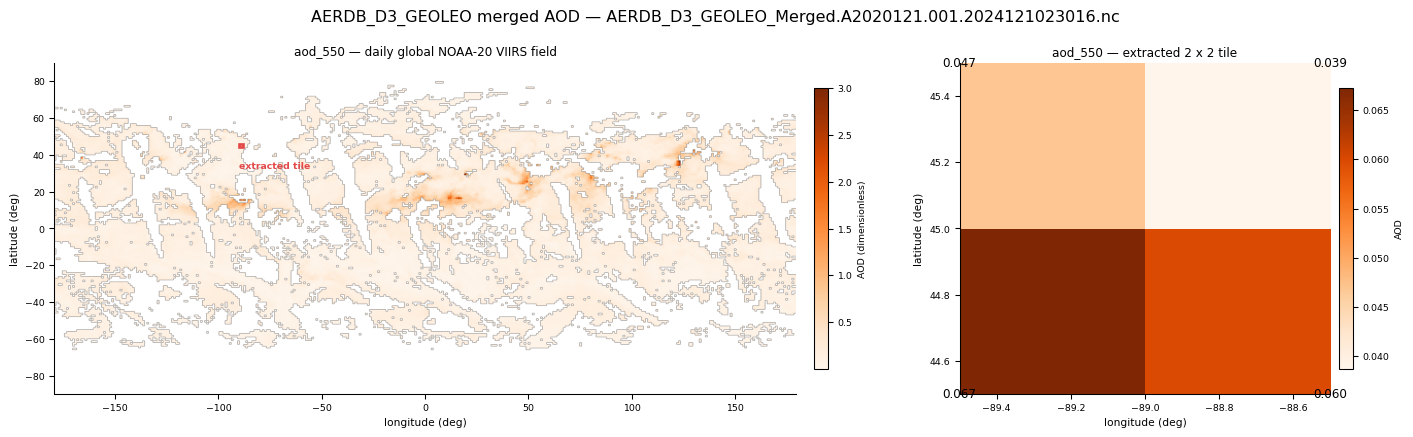

global coverage in this granule: 39.4% of 1-degree cells have a valid retrieval


In [33]:
"""VIIRS AOD: load the tile, show the global field, and annotate the 2x2 extraction."""

aod_tile = load_reader_tile("viirs_aod")
record_result("viirs_aod", aod_tile)

if aod_tile is not None:
    tile_statistics(aod_tile, "viirs_aod")

    global_data, global_lats, global_lons = READERS["viirs_aod"]._native_grid
    extent = [float(global_lons.min()), float(global_lons.max()), float(global_lats.min()), float(global_lats.max())]
    doc = VARIABLE_DOC["viirs_aod"]["aod_550"]

    fig, (ax_global, ax_tile) = plt.subplots(1, 2, figsize=(15, 4.6), gridspec_kw={"width_ratios": [2, 1]})
    plot_field(ax_global, global_data, extent, doc["cmap"], "aod_550 — daily global NOAA-20 VIIRS field", "AOD (dimensionless)")
    draw_tile_box(ax_global, "viirs_aod")

    arr = dict(variable_slices(aod_tile, "viirs_aod"))["aod_550"]
    plot_field(ax_tile, arr, _extent_of(aod_tile), doc["cmap"], "aod_550 — extracted 2 x 2 tile", "AOD")
    for row, lat in enumerate(aod_tile.lats):
        for col, lon in enumerate(aod_tile.lons):
            ax_tile.text(lon, lat, f"{arr[row, col]:.3f}", ha="center", va="center", fontsize=9)

    fig.suptitle(f"AERDB_D3_GEOLEO merged AOD — {FILES['viirs_aod'].name}")
    fig.tight_layout()
    plt.show()

    # Gaps are the norm, not the exception: a polar-orbiting sensor's daily
    # composite is missing wherever it was cloudy or the swath did not reach.
    coverage = 100.0 * float(np.isfinite(global_data).mean())
    print(f"global coverage in this granule: {coverage:.1f}% of 1-degree cells have a valid retrieval")

---
# 12. CERES footprint data — `SSF` / FLASHFlux

**What it is.** The CERES heritage product: cloud and aerosol properties already aggregated
**onto CERES radiometer footprints**, plus the scene-type / ADM codes CERES uses to convert
radiance to flux. For Libera this is the closest analogue to what FMATCH itself produces, and
post-year-one it is one of FMATCH's inputs.

| | |
|---|---|
| **Product** | `CER_SSF_NOAA20-FM6-VIIRS` — *Single Scanner Footprint TOA/Surface Fluxes and Clouds* |
| **Producer** | NASA LaRC (CERES); the **FLASHFlux** near-real-time stream shares the format |
| **Format** | NetCDF4, organized by **footprint** (a 1-D `Footprints` dimension) inside thematic groups |
| **Native scale** | ~20 km at nadir |
| **Temporal** | one file per hour of orbit — **not global** |
| **File naming** | `CER_SSF_{platform}-{instrument}-{imager}_{config}_{prod}.{YYYYMMDDHH}.nc` |
| **SSF** | <https://ceres.larc.nasa.gov/data/#ssf-level-2> |
| **FLASHFlux** | <https://ceres.larc.nasa.gov/data/#fast-longwave-and-shortwave-flux-flashflux> |
| **Reader** | [`readers/ssf.py`](../libera_utils/footprint_matching/readers/ssf.py) |

## Internal structure

Roughly 30 groups (`Time_and_Position`, `Scene_Type`, `Cloudy_Imager_Footprint_Layer`,
`Observed_TOA_Fluxes`, …), each holding variables indexed by footprint. Geolocation lives in
`Time_and_Position/instrument_fov_latitude` and `instrument_fov_longitude` — a true −90…90
latitude, with longitude in the CERES **0…360** convention (normalized on read).

Some variables are 2-D `(Footprints, LowerUpper)`: CERES retrieves up to two cloud layers per
footprint. The reader selects **layer 0 (lower)** — `TODO[LIBSDC-785]` confirms the correct
layer-selection rule with the science team.

## Why this reader rasterizes

SSF is *point* data — an irregular list of footprints, not a grid — so a 2° tile contains a
variable-length scatter of footprints. Rather than give the pipeline a second data model, the
reader bins the footprints onto a regular sub-grid of the tile. The whole file is parsed once
and cached, then re-sliced per tile.

## Two deliberate omissions

* **Surface-type variables** (`surface_igbp_type`, `snow_ice_coverage`) exist in the
  `Surface_Map` group but are **not** extracted: the dedicated IGBP and NISE readers are
  authoritative and higher-resolution, and SSF derives its values from them anyway.
* **Encoded scene / ADM codes** (`cloud_classification`, `shortwave_adm_type`,
  `longwave_adm_type`) span hundreds of values and are *not* a small category set. They are
  mode-aggregated so the dominant raw code survives, but decoding them is deferred
  (`TODO[LIBSDC-785]`). Expect large integers, not class indices, in the panels below.

In [34]:
"""CERES SSF: variable documentation, cross-referenced with the reader's field table."""

from libera_utils.footprint_matching.readers.ssf import _CLOUD_LAYER_INDEX, _SSF_FIELDS

register_docs(
    "ssf",
    {
        "aerosol_optical_depth": {
            "source": "Auxillary_Properties/aerosol_optical_depth",
            "units": "1",
            "valid": (0.0, 8.0),
            "cmap": "Oranges",
            "desc": (
                "Column aerosol optical depth assimilated onto the CERES footprint. Same physical "
                "quantity as the VIIRS AOD reader supplies, but at footprint scale and from the "
                "CERES processing stream; log-mean aggregated for the same reason."
            ),
        },
        "clear_coverage": {
            "source": "Clear_Footprint_Area/clear_coverage",
            "units": "percent",
            "valid": (0.0, 100.0),
            "cmap": "Blues",
            "desc": (
                "Percentage of the footprint the imager found to be cloud-free, at sub-pixel "
                "resolution. 0 means fully overcast; it is the complement of total cloud fraction."
            ),
        },
        "cloud_optical_depth": {
            "source": f"Cloudy_Imager_Footprint_Layer/cloud_optical_depth_mean[layer {_CLOUD_LAYER_INDEX}]",
            "units": "1",
            "valid": (0.0, 512.0),
            "cmap": "Oranges",
            "desc": (
                "Mean visible optical depth of the lower cloud layer within the footprint. "
                "Log-mean aggregated (transmission is exponential in optical depth)."
            ),
        },
        "cloud_water_particle_radius": {
            "source": f"Cloudy_Imager_Footprint_Layer/cloud_water_particle_radius_37um_mean[layer {_CLOUD_LAYER_INDEX}]",
            "units": "micron",
            "valid": (2.0, 60.0),
            "cmap": "Greens",
            "desc": (
                "Effective radius of LIQUID cloud droplets, retrieved from the 3.7 um channel. "
                "Droplet size controls how strongly a cloud of given water content scatters, so it "
                "sets cloud albedo at fixed optical depth."
            ),
        },
        "cloud_ice_particle_radius": {
            "source": f"Cloudy_Imager_Footprint_Layer/cloud_ice_particle_radius_37um_mean[layer {_CLOUD_LAYER_INDEX}]",
            "units": "micron",
            "valid": (5.0, 90.0),
            "cmap": "Purples",
            "desc": (
                "Effective radius of ICE crystals in the same layer, also from the 3.7 um retrieval. "
                "Ice particles are systematically larger than water droplets; SSF keeps the two "
                "phases in separate variables rather than blending them."
            ),
        },
        "cloud_classification": {
            "source": "Scene_Type/cloud_classification",
            "units": "code",
            "valid": (0.0, 32766.0),
            "cmap": "cividis",
            "desc": (
                "ENCODED ISCCP 3x3 cloud classification by layer — a packed CERES identifier "
                "spanning thousands of values, not a small category index. Mode-aggregated so the "
                "dominant raw code survives; decoding is deferred (TODO[LIBSDC-785])."
            ),
        },
        "shortwave_adm_type": {
            "source": "Scene_Type/shortwave_adm_type",
            "units": "code",
            "valid": (0.0, 5000.0),
            "cmap": "cividis",
            "desc": (
                "ENCODED index of the shortwave Angular Distribution Model CERES used to invert "
                "this footprint's radiance to a flux. The ADM choice is scene-dependent, which is "
                "precisely why FMATCH assembles scene information in the first place."
            ),
        },
        "longwave_adm_type": {
            "source": "Scene_Type/longwave_adm_type",
            "units": "code",
            "valid": (0.0, 5000.0),
            "cmap": "cividis",
            "desc": "ENCODED index of the longwave Angular Distribution Model, as above but for emitted radiation.",
        },
    },
)
show_variable_table("ssf")

print("reader field table (source of truth for fill / valid range / layer selection):")
print(f"{'out_name':<30}{'group':<34}{'fill':>12}{'valid range':>18}{'layer':>7}")
print("-" * 101)
for field in _SSF_FIELDS:
    print(f"{field.out_name:<30}{field.group:<34}{field.fill:>12.4g}{str(field.valid_range):>18}{str(field.layer_index):>7}")

variable                        units       aggregation         source field
--------------------------------------------------------------------------------------------------------------
aerosol_optical_depth           1           weighted_log_mean   Auxillary_Properties/aerosol_optical_depth
    Column aerosol optical depth assimilated onto the CERES footprint. Same physical quantity as
    the VIIRS AOD reader supplies, but at footprint scale and from the CERES processing stream;
    log-mean aggregated for the same reason.
clear_coverage                  percent     weighted_mean       Clear_Footprint_Area/clear_coverage
    Percentage of the footprint the imager found to be cloud-free, at sub-pixel resolution. 0 means
    fully overcast; it is the complement of total cloud fraction.
cloud_optical_depth             1           weighted_log_mean   Cloudy_Imager_Footprint_Layer/cloud_optical_depth_mean[layer 0]
    Mean visible optical depth of the lower cloud layer within the footpr

In [35]:
"""CERES SSF: inspect the group structure, and compare reader config against file metadata."""

if FILES["ssf"] is not None:
    import netCDF4

    with netCDF4.Dataset(str(FILES["ssf"]), "r") as ds:
        print(f"file: {FILES['ssf'].name}")
        print(f"groups ({len(ds.groups)}):")
        for name in list(ds.groups)[:12]:
            print(f"   {name}")
        print(f"   ... and {len(ds.groups) - 12} more")

        n_footprints = ds.groups["Time_and_Position"].variables["instrument_fov_latitude"].shape[0]
        print(f"\nfootprints in this granule: {n_footprints:,}")

        print("\ngeolocation variables:")
        for var_name in ("instrument_fov_latitude", "instrument_fov_longitude"):
            variable = ds.groups["Time_and_Position"].variables[var_name]
            attrs = {k: variable.getncattr(k) for k in variable.ncattrs()}
            print(f"   {var_name:<26} units={attrs.get('units', '-'):<14} valid_range={attrs.get('valid_range')}")
        print("   -> longitude is 0..360 in the file and is wrapped to -180..180 on read")

        # Does the reader's hard-coded valid range agree with the file's own metadata?
        metadata = {}
        for field in _SSF_FIELDS:
            variable = ds.groups[field.group].variables[field.var]
            file_range = variable.getncattr("valid_range") if "valid_range" in variable.ncattrs() else None
            metadata[field.out_name] = {
                "reader": field.valid_range,
                "file": tuple(float(v) for v in file_range) if file_range is not None else None,
            }
    print()
    compare_reader_config_to_file("ssf", metadata)
    print("A stricter reader range is a deliberate choice (physically implausible extremes are")
    print("rejected); a looser one lets through values the producer flags as invalid. Either way")
    print("it should be a decision, not an accident.")
else:
    print("CERES SSF file not available.")

file: CER_SSF_NOAA20-FM6-VIIRS_alpha4_000000.2020040115.nc
groups (29):
   Time_and_Position
   Viewing_Geometry
   Surface_Map
   Scene_Type
   Filtered_Radiances
   Unfiltered_Radiances
   Observed_TOA_Fluxes
   Full_Footprint_Properties
   Clear_Footprint_Area
   Meteorological_Properties
   Cloudy_Imager_Footprint_Layer
   Footprint_Imager_Radiance_Statistics
   ... and 17 more

footprints in this granule: 195,256

geolocation variables:
   instrument_fov_latitude    units=degrees_north  valid_range=[-90.  90.]
   instrument_fov_longitude   units=degrees_east   valid_range=[  0. 360.]
   -> longitude is 0..360 in the file and is wrapped to -180..180 on read

variable                        reader valid range        file valid_range          agreement
----------------------------------------------------------------------------------------------------
aerosol_optical_depth           (0.0, 8.0)                (0.0, 8.0)                match
clear_coverage                  (0.0, 100.0)

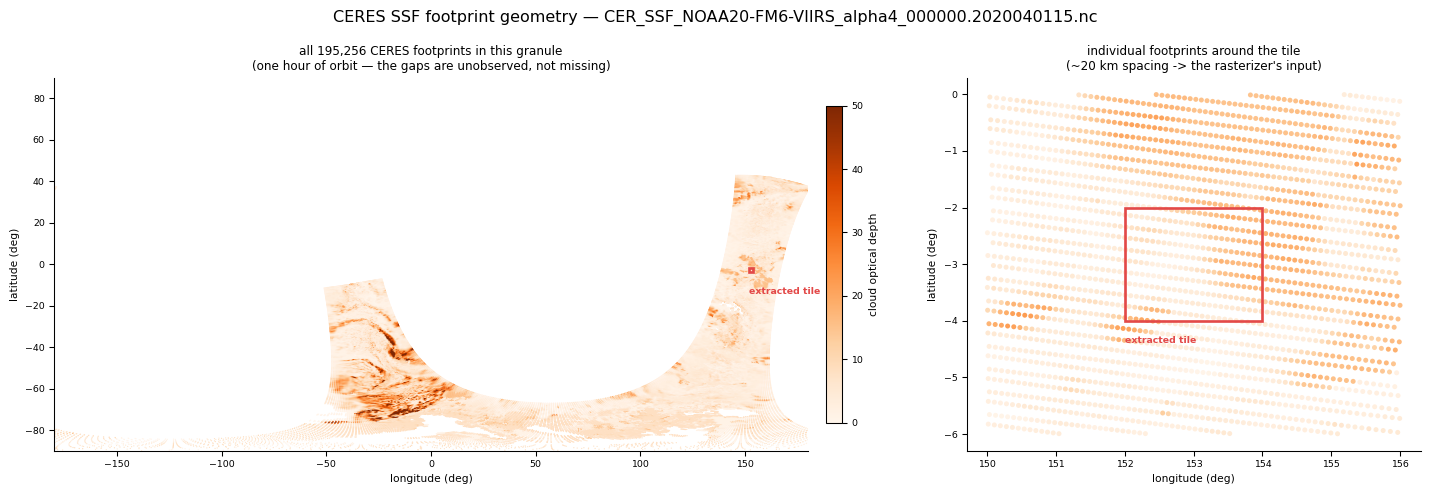

In [36]:
"""CERES SSF: visualize the granule's footprint geometry — where an hour of orbit actually looks."""

if FILES["ssf"] is not None:
    import netCDF4

    from libera_utils.footprint_matching.readers._swath import apply_fill_and_valid_range, normalize_longitude

    with netCDF4.Dataset(str(FILES["ssf"]), "r") as ds:
        group = ds.groups["Time_and_Position"]
        fov_lat = apply_fill_and_valid_range(group.variables["instrument_fov_latitude"][:], valid_range=(-90.0, 90.0))
        fov_lon = normalize_longitude(
            apply_fill_and_valid_range(group.variables["instrument_fov_longitude"][:], valid_range=(0.0, 360.0))
        )
        # Colour the footprints by a physical field so the swath is not just geometry.
        cloud_od = apply_fill_and_valid_range(
            ds.groups["Cloudy_Imager_Footprint_Layer"].variables["cloud_optical_depth_mean"][:, 0],
            fill_value=3.4028235e38,
            valid_range=(0.0, 512.0),
        )

    fig, (ax_map, ax_zoom) = plt.subplots(1, 2, figsize=(15, 5.2), gridspec_kw={"width_ratios": [2, 1]})
    scatter = ax_map.scatter(fov_lon, fov_lat, c=cloud_od, s=0.8, cmap="Oranges", linewidths=0, vmin=0, vmax=50)
    ax_map.set_xlim(-180, 180)
    ax_map.set_ylim(-90, 90)
    ax_map.set_xlabel("longitude (deg)")
    ax_map.set_ylabel("latitude (deg)")
    ax_map.set_title(f"all {fov_lat.size:,} CERES footprints in this granule\n(one hour of orbit — the gaps are unobserved, not missing)")
    plt.colorbar(scatter, ax=ax_map, shrink=0.85, pad=0.02, label="cloud optical depth")
    draw_tile_box(ax_map, "ssf")

    # Zoom to the verification tile so individual footprints — and the ~20 km spacing
    # the rasterizer has to work with — become visible.
    lat_c, lon_c = TILE_CENTERS["ssf"]
    bbox = GriddedDataReader._tile_key_to_bbox(tile_key_for("ssf", lat_c, lon_c))
    near = (
        (fov_lat > bbox.lat_min - 2) & (fov_lat < bbox.lat_max + 2)
        & (fov_lon > bbox.lon_min - 2) & (fov_lon < bbox.lon_max + 2)
    )
    ax_zoom.scatter(fov_lon[near], fov_lat[near], c=cloud_od[near], s=14, cmap="Oranges", linewidths=0, vmin=0, vmax=50)
    ax_zoom.set_xlabel("longitude (deg)")
    ax_zoom.set_ylabel("latitude (deg)")
    ax_zoom.set_title("individual footprints around the tile\n(~20 km spacing -> the rasterizer's input)")
    draw_tile_box(ax_zoom, "ssf")

    fig.suptitle(f"CERES SSF footprint geometry — {FILES['ssf'].name}")
    fig.tight_layout()
    plt.show()

[ssf] CER_SSF_NOAA20-FM6-VIIRS_alpha4_000000.2020040115.nc
[ssf] tile TileKey(source='ssf', lat_idx=43, lon_idx=166) -> lat [-4.0, -2.0], lon [152.0, 154.0]
[ssf] loaded 8 variable(s), grid 10 x 10, 3.3 KiB, in 0.1 s
variable                        units        valid cells         min         max        mean         std
--------------------------------------------------------------------------------------------------------
aerosol_optical_depth           1              100 (100%)      0.1523      0.2405      0.2315     0.02389
clear_coverage                  percent        100 (100%)           0           0           0           0
cloud_optical_depth             1              100 (100%)       1.601       19.39       8.993       5.288
cloud_water_particle_radius     micron          20 ( 20%)           8         8.2       8.032     0.05116
cloud_ice_particle_radius       micron          93 ( 93%)       10.16        26.8       15.94       4.361
cloud_classification            code       

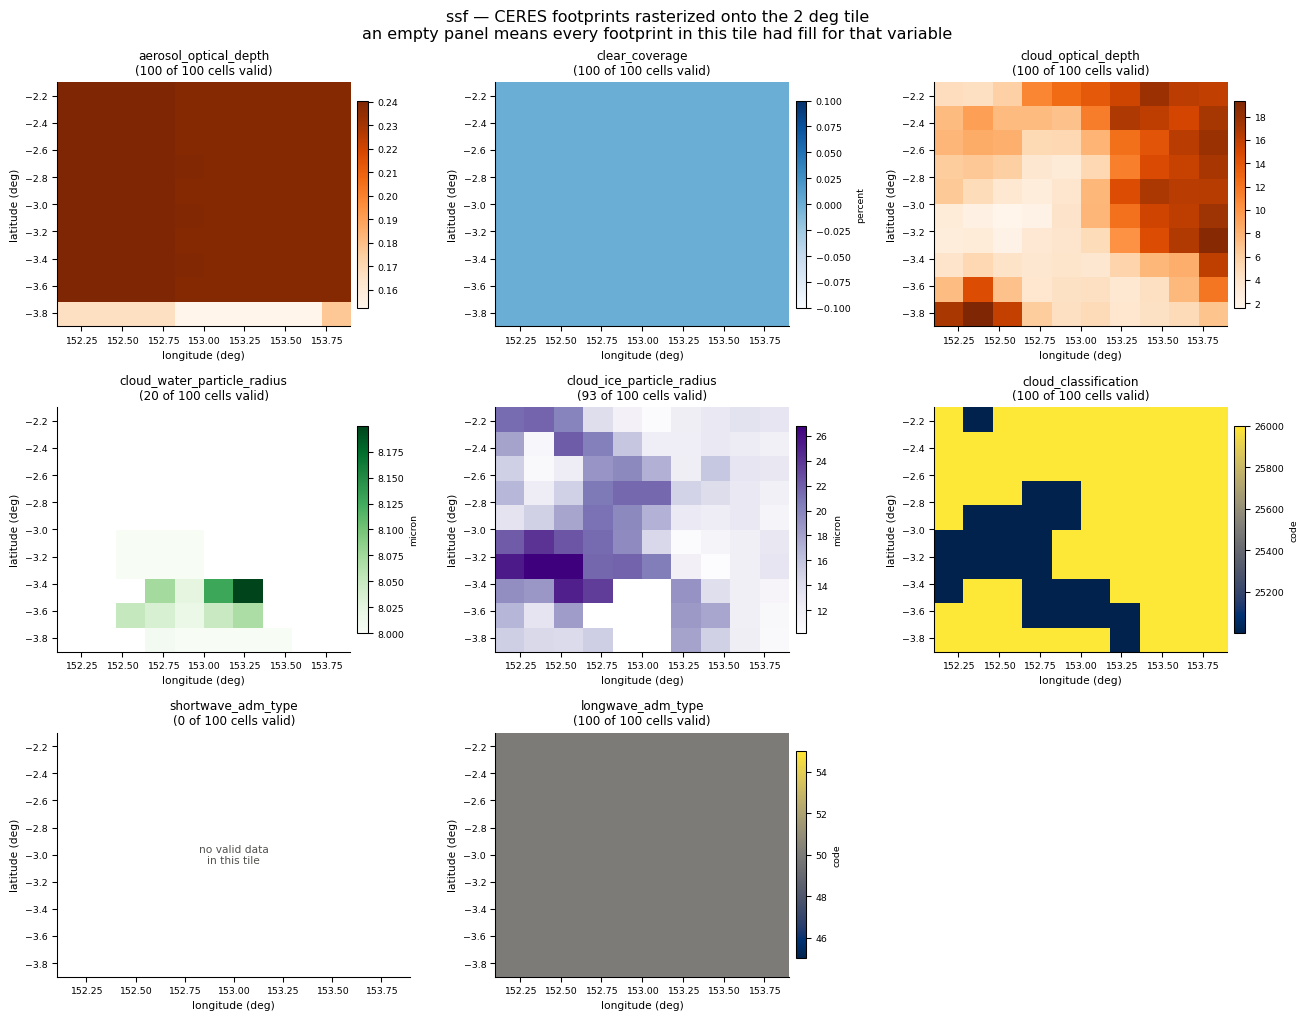

In [37]:
"""CERES SSF: load the tile and plot all eight rasterized variables."""

ssf_tile = load_reader_tile("ssf")
record_result("ssf", ssf_tile)

if ssf_tile is not None:
    tile_statistics(ssf_tile, "ssf")
    plot_tile_variables(
        ssf_tile,
        "ssf",
        ncols=3,
        suptitle=(
            "ssf — CERES footprints rasterized onto the 2 deg tile\n"
            "an empty panel means every footprint in this tile had fill for that variable"
        ),
    )

---
# 13. Imager-pixel cloud retrievals — CERES `CLDPIX`

**What it is.** The same CERES cloud retrievals as SSF, but **before** they are averaged onto
CERES footprints: one retrieval per ~1 km VIIRS imager pixel. This is the highest-resolution
cloud input FMATCH has, and post-year-one it is what the ERA5 substitutes are replaced by.

| | |
|---|---|
| **Product** | `CER_CLDPIX_NOAA20-VIIRS` — CERES Cloud Pixel |
| **Producer** | NASA LaRC (CERES) |
| **Format** | NetCDF4, **flat** (root-level) variables on a 2-D imager swath `(Scanlines, Pixels)` |
| **Native scale** | ~1 km (VIIRS imager pixel); a granule is e.g. 16 120 × 400 = 6.4 M pixels |
| **File naming** | `CER_CLDPIX_{platform}-{imager}_{config}_{prod}.{YYYYMMDDHH}.nc` |
| **CERES data** | <https://ceres.larc.nasa.gov/data/> |
| **Reader** | [`readers/cldpix.py`](../libera_utils/footprint_matching/readers/cldpix.py) |

## Geolocation: the variable named `Latitude` is **colatitude**

This is the trap in this product, and the reason the section below plots the evidence.

CERES stores geolocation in the colatitude convention: the root-level variable *named*
`Latitude` holds **colatitude in degrees** — `0°` at the North Pole increasing to `180°` at
the South Pole, so `latitude = 90 − colatitude`. Three independent confirmations:

1. the variable's own `valid_range` attribute is `[0, 180]` (a true latitude would be `[-90, 90]`);
2. the granule's values run past 90 — up to ~149 in the file used here;
3. **physically**: binning the granule's 10.8 µm brightness temperature by the raw value gives a
   warm band (>280 K) spanning roughly 65–125 and cold ends (~245 K) at 0 and 180 — i.e. warm
   tropics and cold poles, with the shallow dip right at 90 caused by high, cold convective
   cloud tops over the equator. If the raw values were latitudes, the warmest bin would sit at 0
   and the plot would be a single peak at the left-hand end, which it is not.

Reading the field as a latitude does two damaging things at once: it places every pixel at the
wrong latitude, **and** it silently discards the entire southern hemisphere, because
colatitude > 90 falls outside a −90…90 filter. The verification tile for this reader is
deliberately in the southern hemisphere so that the conversion is exercised every time this
notebook runs.

Longitude is stored 0…360 (degrees east) and is wrapped to −180…180.

## Why this reader rasterizes

The `(Scanlines, Pixels)` arrays are a **swath**, not a grid: every pixel carries its own
geolocation and the array axes are scan geometry, not latitude and longitude. So, as with SSF,
the reader flattens the swath to points and bins them onto a regular 0.05° sub-grid of the
tile. A full granule is hundreds of megabytes once every selected variable is read as float64,
which is why the parse is cached per reader instance.

## Deliberate omissions

`IGBP_Ecosystem`, `Snow_Map_Value` and `Ice_Map_Value` are present in the file but not read —
the dedicated IGBP and NISE readers are authoritative for surface classification.

In [38]:
"""CERES CLDPIX: variable documentation, cross-referenced with the reader's field table."""

from libera_utils.footprint_matching.readers.cldpix import _CLDPIX_FIELDS

register_docs(
    "cldpix",
    {
        "cloud_optical_depth": {
            "source": "Eff_Cld_Optical_Depth",
            "units": "1",
            "valid": (0.25, 150.0),
            "cmap": "Oranges",
            "desc": (
                "Effective visible cloud optical depth of the imager pixel — how strongly the cloud "
                "attenuates visible light. Log-mean aggregated; the 0.25 lower bound is CERES's "
                "threshold for calling a pixel cloudy at all."
            ),
        },
        "cloud_water_path": {
            "source": "Cld_Water_Path",
            "units": "g/m2",
            "valid": (0.0, 10000.0),
            "cmap": "Blues",
            "desc": (
                "Condensed water (liquid or ice) in the cloud column above one square metre. "
                "Together with particle radius it determines optical depth, and it is the quantity "
                "a cloud's radiative effect ultimately scales with."
            ),
        },
        "cloud_effective_temperature": {
            "source": "Eff_Cld_Temp",
            "units": "K",
            "valid": (190.0, 350.0),
            "cmap": "Reds",
            "desc": (
                "Radiating temperature of the cloud — the temperature that reproduces its observed "
                "infrared emission. Colder means higher, and it maps almost directly to how much "
                "outgoing longwave radiation the cloud suppresses."
            ),
        },
        "cloud_effective_height": {
            "source": "Eff_Cld_Height",
            "units": "km",
            "valid": (0.0, 18.0),
            "cmap": "Greens",
            "desc": (
                "Radiatively effective cloud height: the altitude corresponding to the effective "
                "temperature. Lower than the physical cloud top, because emission comes from a "
                "layer of finite depth rather than from the very top surface."
            ),
        },
        "cloud_effective_pressure": {
            "source": "Eff_Cld_Pressure",
            "units": "hPa",
            "valid": (10.0, 1100.0),
            "cmap": "Purples",
            "desc": (
                "The same effective level expressed as a pressure. Note the file declares this "
                "variable's valid_range DESCENDING ([1100, 10]); the reader normalizes the order, "
                "which is why it must also disable netCDF4 auto-masking (which would otherwise mask "
                "every value in the field)."
            ),
        },
        "cloud_top_height": {
            "source": "Top_Cld_Height",
            "units": "km",
            "valid": None,
            "cmap": "Greens",
            "desc": (
                "Physical height of the cloud top. This is the only field the reader configures "
                "with no valid range, so its fill pixels can only be caught by the fill-value test "
                "— see the fill-handling check below."
            ),
        },
        "cloud_particle_radius": {
            "source": "Cld_Radius",
            "units": "micron",
            "valid": (2.0, 60.0),
            "cmap": "Greens",
            "desc": (
                "Effective radius of the cloud particles, blended across phase by the CERES "
                "retrieval (distinct from the phase-separated radii SSF carries, and from the "
                "wavelength-specific Cld_Radius_0124 / Cld_Radius_0160 fields in this same file)."
            ),
        },
        "cloud_particle_phase": {
            "source": "Cloud_Particle_Phase",
            "units": "code",
            "valid": (1.0, 5.0),
            "cmap": CATEGORICAL,
            "desc": (
                "Thermodynamic phase of the cloud particles (liquid / ice / mixed). Categorical, so "
                "it is mode-aggregated: phase changes scattering behaviour qualitatively, and the "
                "average of 'liquid' and 'ice' is not a physical state."
            ),
        },
        "cloud_mask": {
            "source": "CERES_Cloud_Mask",
            "units": "code",
            "valid": (0.0, 3.0),
            "cmap": CATEGORICAL,
            "desc": (
                "CERES four-level cloud mask, from confidently clear to confidently cloudy. "
                "Mode-aggregated. It is the gate on every other cloud variable here: a pixel the "
                "mask calls clear has no cloud retrieval to report."
            ),
        },
    },
)
show_variable_table("cldpix")

print("reader field table:")
print(f"{'out_name':<30}{'source variable':<26}{'aggregation':<20}{'fill':>12}{'valid range':>18}")
print("-" * 106)
for field in _CLDPIX_FIELDS:
    print(f"{field.out_name:<30}{field.var:<26}{field.aggregation:<20}{field.fill:>12.4g}{str(field.valid_range):>18}")

variable                        units       aggregation         source field
--------------------------------------------------------------------------------------------------------------
cloud_optical_depth             1           weighted_log_mean   Eff_Cld_Optical_Depth
    Effective visible cloud optical depth of the imager pixel — how strongly the cloud attenuates
    visible light. Log-mean aggregated; the 0.25 lower bound is CERES's threshold for calling a
    pixel cloudy at all.
cloud_water_path                g/m2        weighted_mean       Cld_Water_Path
    Condensed water (liquid or ice) in the cloud column above one square metre. Together with
    particle radius it determines optical depth, and it is the quantity a cloud's radiative effect
    ultimately scales with.
cloud_effective_temperature     K           weighted_mean       Eff_Cld_Temp
    Radiating temperature of the cloud — the temperature that reproduces its observed infrared
    emission. Colder means higher, 

file: CER_CLDPIX_NOAA20-VIIRS_1P9test_000000.2020041015.nc
dimensions   : {Scanlines: 16120, Pixels: 400}
root variables (30): ['Latitude', 'Longitude', 'Observation_Time', 'Ref0063', 'Ref0160', 'RAD0055', 'BTemp0375', 'BTemp1080', 'BTemp1190', 'Cld_Radius', 'Eff_Cld_Optical_Depth', 'Cld_Water_Path', 'Eff_Cld_Temp', 'Eff_Cld_Height', 'Eff_Cld_Pressure', 'Top_Cld_Height', 'Bot_Cld_Height', 'CEM_CO2_Height', 'Solar_Zenith_Angle', 'Viewing_Zenith_Angle', 'Azimuthal_Angle', 'CERES_Cloud_Mask', 'CERES_Mask_Clear_Category', 'CERES_Mask_Cloud_Category', 'Cloud_Particle_Phase', 'IGBP_Ecosystem', 'Snow_Map_Value', 'Ice_Map_Value', 'Cld_Radius_0124', 'Cld_Radius_0160']

geolocation variables as declared in the file:
   Latitude   units=degrees    valid_range=[  0. 180.]
   Longitude  units=degrees    valid_range=[  0. 360.]



raw 'Latitude' values run 0.1 .. 148.7
   -> values above 90 are impossible for a latitude; they are colatitudes.


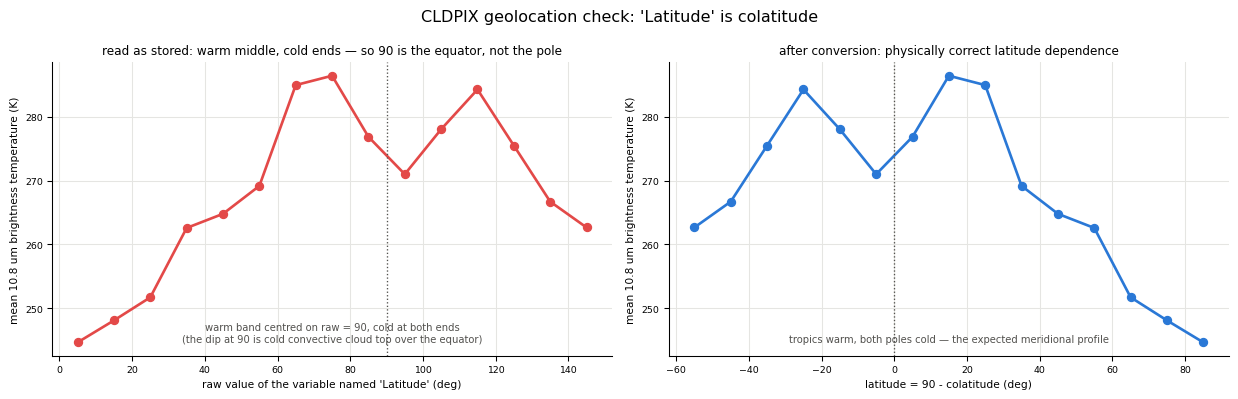

In [39]:
"""CERES CLDPIX: inspect the file, and prove that `Latitude` holds colatitude."""

if FILES["cldpix"] is not None:
    import netCDF4

    with netCDF4.Dataset(str(FILES["cldpix"]), "r") as ds:
        # Auto-masking off, exactly as the reader does it, so raw sentinels are visible.
        ds.set_auto_mask(False)
        print(f"file: {FILES['cldpix'].name}")
        print(f"dimensions   : {{{', '.join(f'{k}: {v.size}' for k, v in ds.dimensions.items())}}}")
        print(f"root variables ({len(ds.variables)}): {list(ds.variables)}")

        print("\ngeolocation variables as declared in the file:")
        for var_name in ("Latitude", "Longitude"):
            variable = ds.variables[var_name]
            attrs = {k: variable.getncattr(k) for k in variable.ncattrs()}
            print(f"   {var_name:<10} units={attrs.get('units', '-'):<10} valid_range={attrs.get('valid_range')}")

        # Decimated sample: 6.4 M pixels is far more than this check needs.
        raw_lat = np.asarray(ds.variables["Latitude"][::10, ::4]).ravel()
        brightness = np.asarray(ds.variables["BTemp1080"][::10, ::4]).ravel()

    usable = (raw_lat >= 0) & (raw_lat <= 180) & np.isfinite(brightness) & (brightness < 400)
    raw_lat, brightness = raw_lat[usable], brightness[usable]
    print(f"\nraw 'Latitude' values run {raw_lat.min():.1f} .. {raw_lat.max():.1f}")
    print("   -> values above 90 are impossible for a latitude; they are colatitudes.")

    # The physical test: mean 10.8 um brightness temperature in bins of the raw value.
    # Under the colatitude reading the warm equator sits at 90; under a latitude
    # reading it would have to sit at 0.
    edges = np.arange(0, 181, 10)
    centres = 0.5 * (edges[:-1] + edges[1:])
    binned = np.array([
        brightness[(raw_lat >= lo) & (raw_lat < hi)].mean() if np.any((raw_lat >= lo) & (raw_lat < hi)) else np.nan
        for lo, hi in zip(edges[:-1], edges[1:])
    ])

    fig, (ax_raw, ax_conv) = plt.subplots(1, 2, figsize=(13, 4.2))
    ax_raw.plot(centres, binned, marker="o", color="#e34948", linewidth=2)
    ax_raw.axvline(90, color="#52514e", linestyle=":", linewidth=1)
    ax_raw.text(
        0.5, 0.04,
        "warm band centred on raw = 90, cold at both ends\n(the dip at 90 is cold convective cloud top over the equator)",
        transform=ax_raw.transAxes, ha="center", va="bottom", fontsize=7.5, color="#52514e",
    )
    ax_raw.set_xlabel("raw value of the variable named 'Latitude' (deg)")
    ax_raw.set_ylabel("mean 10.8 um brightness temperature (K)")
    ax_raw.set_title("read as stored: warm middle, cold ends — so 90 is the equator, not the pole")
    ax_raw.grid(color="#e5e5e2")
    ax_raw.set_axisbelow(True)

    ax_conv.plot(90.0 - centres, binned, marker="o", color="#2a78d6", linewidth=2)
    ax_conv.axvline(0, color="#52514e", linestyle=":", linewidth=1)
    ax_conv.text(
        0.5, 0.04,
        "tropics warm, both poles cold — the expected meridional profile",
        transform=ax_conv.transAxes, ha="center", va="bottom", fontsize=7.5, color="#52514e",
    )
    ax_conv.set_xlabel("latitude = 90 - colatitude (deg)")
    ax_conv.set_ylabel("mean 10.8 um brightness temperature (K)")
    ax_conv.set_title("after conversion: physically correct latitude dependence")
    ax_conv.grid(color="#e5e5e2")
    ax_conv.set_axisbelow(True)

    fig.suptitle("CLDPIX geolocation check: 'Latitude' is colatitude")
    fig.tight_layout()
    plt.show()
else:
    print("CERES CLDPIX file not available.")

In [40]:
"""CERES CLDPIX: check fill handling, and compare reader config against file metadata."""

if FILES["cldpix"] is not None:
    import netCDF4

    from libera_utils.footprint_matching.readers._swath import apply_fill_and_valid_range

    # The float32 fill sentinel written in these files, and the decimal literal the
    # readers declare. They are NOT the same float64 number, which is why the fill
    # test compares against both the literal and its float32 round-trip.
    stored_fill = float(np.float32(3.4028235e38))
    print(f"declared fill literal        : {3.4028235e38!r}")
    print(f"same value stored as float32 : {stored_fill!r}")
    print(f"equal as float64?            : {3.4028235e38 == stored_fill}")
    print("   -> comparing only against the literal misses every fill pixel; fields with a")
    print("      valid_range were saved by the range test, but cloud_top_height has none.")

    with netCDF4.Dataset(str(FILES["cldpix"]), "r") as ds:
        ds.set_auto_mask(False)
        sample = ds.variables["Top_Cld_Height"][::10, ::4]
        metadata = {}
        for field in _CLDPIX_FIELDS:
            variable = ds.variables[field.var]
            file_range = variable.getncattr("valid_range") if "valid_range" in variable.ncattrs() else None
            metadata[field.out_name] = {
                "reader": field.valid_range,
                "file": tuple(float(v) for v in file_range) if file_range is not None else None,
            }

    cleaned = apply_fill_and_valid_range(sample, fill_value=3.4028235e38, valid_range=None)
    n_fill = int(np.isnan(cleaned).sum())
    print(f"\nTop_Cld_Height sample: {n_fill:,} of {cleaned.size:,} values were fill and are now NaN")
    print(f"   maximum retained height: {np.nanmax(cleaned):.2f} km (a physical cloud top, not 3.4e38)")

    print()
    compare_reader_config_to_file("cldpix", metadata)

declared fill literal        : 3.4028235e+38
same value stored as float32 : 3.4028234663852886e+38
equal as float64?            : False
   -> comparing only against the literal misses every fill pixel; fields with a
      valid_range were saved by the range test, but cloud_top_height has none.



Top_Cld_Height sample: 53,991 of 161,200 values were fill and are now NaN
   maximum retained height: 17.61 km (a physical cloud top, not 3.4e38)

variable                        reader valid range        file valid_range          agreement
----------------------------------------------------------------------------------------------------
cloud_optical_depth             (0.25, 150.0)             (0.25, 150.0)             match
cloud_water_path                (0.0, 10000.0)            (0.0, 10000.0)            match
cloud_effective_temperature     (190.0, 350.0)            (190.0, 350.0)            match
cloud_effective_height          (0.0, 18.0)               (0.0, 18.0)               match
cloud_effective_pressure        (10.0, 1100.0)            (1100.0, 10.0)            match
cloud_top_height                None                      (0.0, 18.0)               reader takes no range
cloud_particle_radius           (2.0, 60.0)               (2.0, 78.0)               DIFFERS — reader 

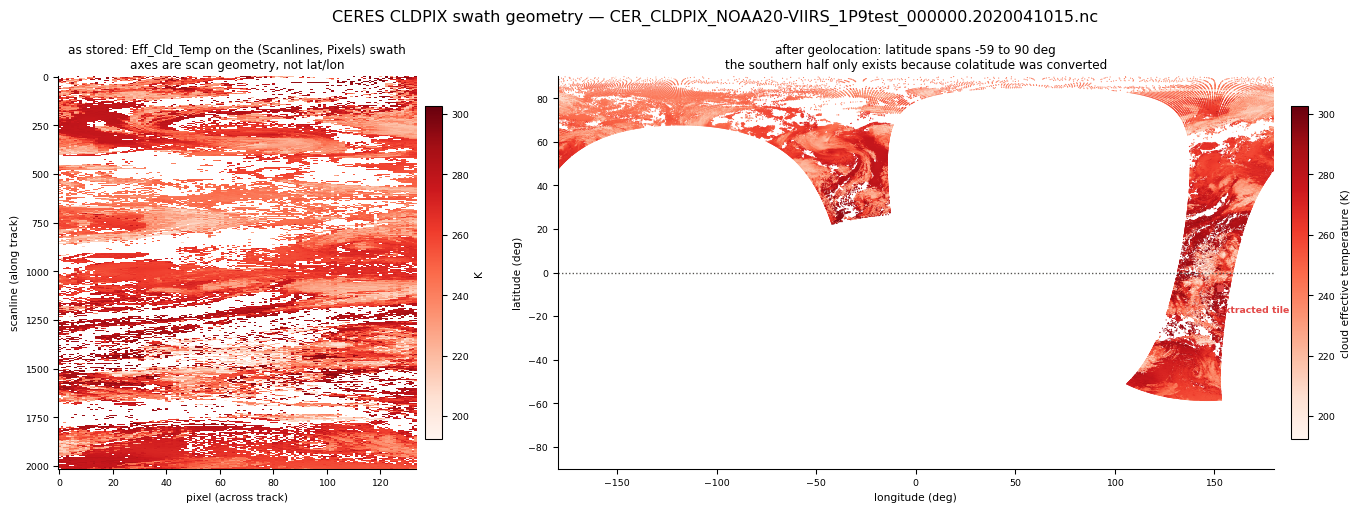

In [41]:
"""CERES CLDPIX: visualize the swath geometry after the colatitude conversion."""

if FILES["cldpix"] is not None:
    import netCDF4

    from libera_utils.footprint_matching.readers._swath import normalize_longitude

    with netCDF4.Dataset(str(FILES["cldpix"]), "r") as ds:
        ds.set_auto_mask(False)
        step_scan, step_pix = 8, 3
        colat = np.asarray(ds.variables["Latitude"][::step_scan, ::step_pix], dtype=float)
        lon_raw = np.asarray(ds.variables["Longitude"][::step_scan, ::step_pix], dtype=float)
        temp = np.asarray(ds.variables["Eff_Cld_Temp"][::step_scan, ::step_pix], dtype=float)

    valid = (colat >= 0) & (colat <= 180)
    swath_lat = np.where(valid, 90.0 - colat, np.nan)
    swath_lon = normalize_longitude(np.where((lon_raw >= 0) & (lon_raw <= 360), lon_raw, np.nan))
    temp = np.where((temp >= 190) & (temp <= 350), temp, np.nan)

    fig, (ax_swath, ax_map) = plt.subplots(1, 2, figsize=(15, 5.4), gridspec_kw={"width_ratios": [1, 2]})

    # Panel 1: the array as stored. Scan geometry, not geography.
    image = ax_swath.imshow(temp, cmap="Reds", aspect="auto", interpolation="nearest")
    ax_swath.set_title("as stored: Eff_Cld_Temp on the (Scanlines, Pixels) swath\naxes are scan geometry, not lat/lon")
    ax_swath.set_xlabel("pixel (across track)")
    ax_swath.set_ylabel("scanline (along track)")
    plt.colorbar(image, ax=ax_swath, shrink=0.85, pad=0.02, label="K")

    # Panel 2: the same pixels at their true positions, southern hemisphere included.
    flat_lat, flat_lon, flat_temp = swath_lat.ravel(), swath_lon.ravel(), temp.ravel()
    keep = np.isfinite(flat_lat) & np.isfinite(flat_lon)
    scatter = ax_map.scatter(flat_lon[keep], flat_lat[keep], c=flat_temp[keep], s=0.7, cmap="Reds", linewidths=0)
    ax_map.set_xlim(-180, 180)
    ax_map.set_ylim(-90, 90)
    ax_map.axhline(0, color="#52514e", linestyle=":", linewidth=1)
    ax_map.set_xlabel("longitude (deg)")
    ax_map.set_ylabel("latitude (deg)")
    ax_map.set_title(
        f"after geolocation: latitude spans {np.nanmin(swath_lat):.0f} to {np.nanmax(swath_lat):.0f} deg\n"
        "the southern half only exists because colatitude was converted"
    )
    plt.colorbar(scatter, ax=ax_map, shrink=0.85, pad=0.02, label="cloud effective temperature (K)")
    draw_tile_box(ax_map, "cldpix")

    fig.suptitle(f"CERES CLDPIX swath geometry — {FILES['cldpix'].name}")
    fig.tight_layout()
    plt.show()

[cldpix] CER_CLDPIX_NOAA20-VIIRS_1P9test_000000.2020041015.nc
[cldpix] tile TileKey(source='cldpix', lat_idx=41, lon_idx=166) -> lat [-8.0, -6.0], lon [152.0, 154.0]


[cldpix] loaded 9 variable(s), grid 40 x 40, 56.9 KiB, in 1.8 s
variable                        units        valid cells         min         max        mean         std
--------------------------------------------------------------------------------------------------------
cloud_optical_depth             1            1,221 ( 76%)      0.2501       15.82        2.28       2.906
cloud_water_path                g/m2         1,549 ( 97%)     0.09966        50.8       11.02       14.78
cloud_effective_temperature     K            1,549 ( 97%)       197.8       294.6       275.2       19.56
cloud_effective_height          km           1,549 ( 97%)       1.335       15.79       4.389       3.096
cloud_effective_pressure        hPa          1,549 ( 97%)         115       867.5       640.1       189.7
cloud_top_height                km           1,549 ( 97%)       1.345       15.79       4.612       3.433
cloud_particle_radius           micron       1,549 ( 97%)        3.18       57.49       12

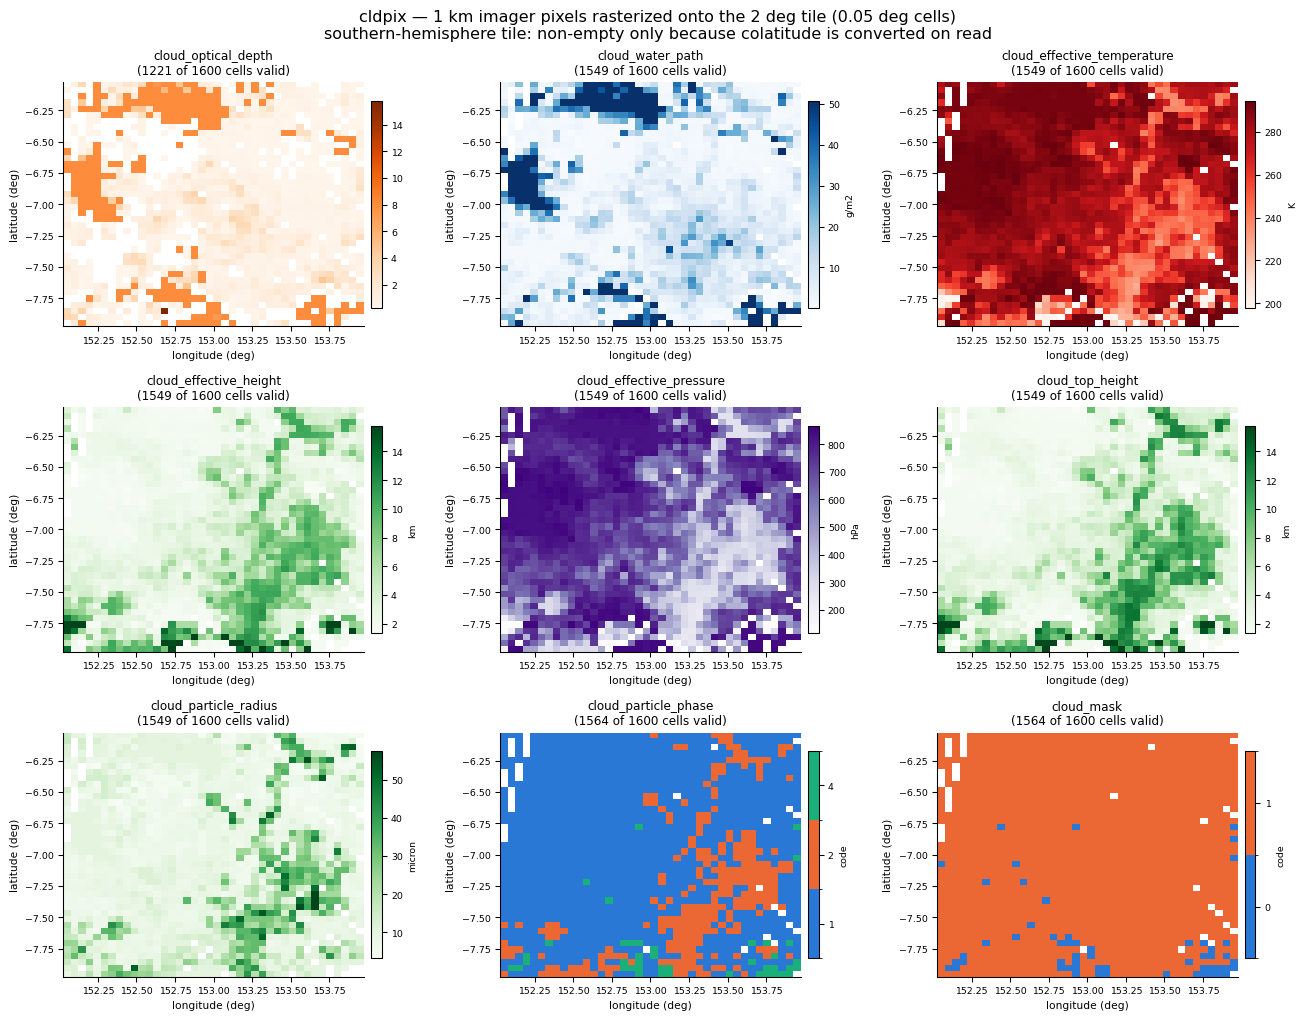

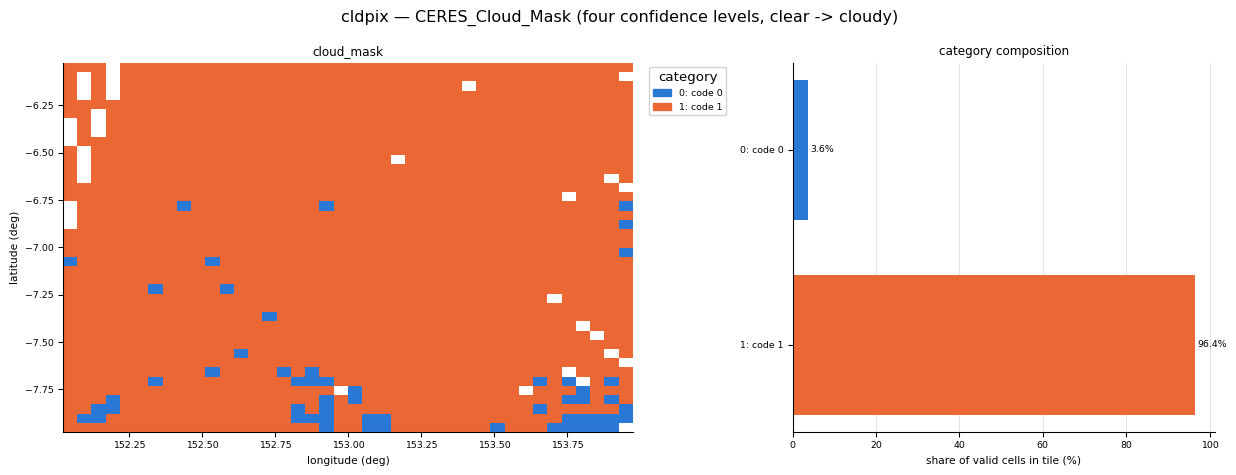

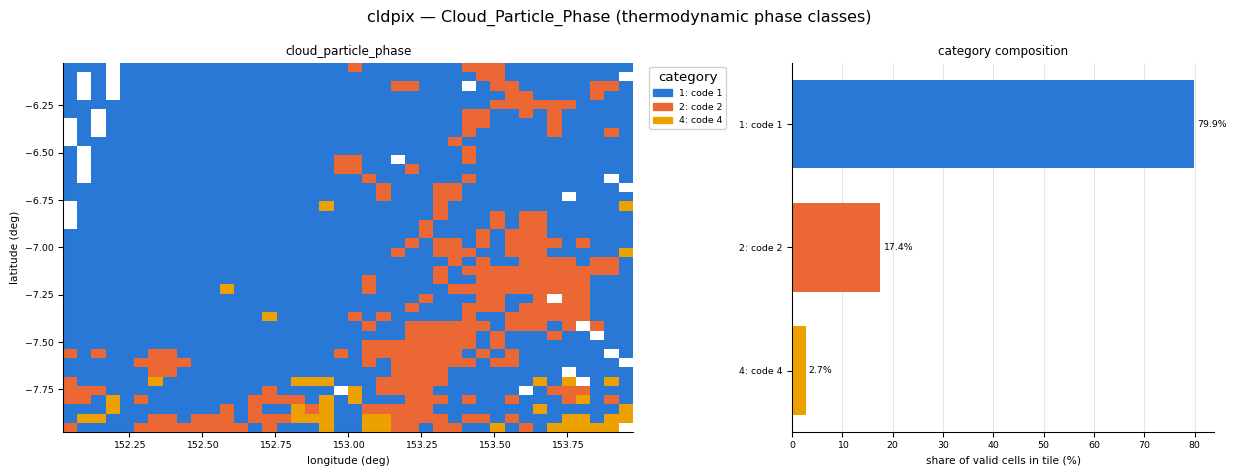

In [42]:
"""CERES CLDPIX: load the tile (parses the whole granule once) and plot every variable."""

cldpix_tile = load_reader_tile("cldpix")
record_result("cldpix", cldpix_tile)

if cldpix_tile is not None:
    tile_statistics(cldpix_tile, "cldpix")
    plot_tile_variables(
        cldpix_tile,
        "cldpix",
        ncols=3,
        suptitle=(
            "cldpix — 1 km imager pixels rasterized onto the 2 deg tile (0.05 deg cells)\n"
            "southern-hemisphere tile: non-empty only because colatitude is converted on read"
        ),
    )

    # The two categorical fields deserve their own discrete treatment: these are the
    # codes weighted_mode will act on, and a continuous ramp would imply an ordering
    # between 'liquid' and 'ice' that does not exist.
    plot_categorical_tile(
        cldpix_tile,
        "cldpix",
        "cloud_mask",
        labels={0: "code 0", 1: "code 1", 2: "code 2", 3: "code 3"},
        title="cldpix — CERES_Cloud_Mask (four confidence levels, clear -> cloudy)",
    )
    plot_categorical_tile(
        cldpix_tile,
        "cldpix",
        "cloud_particle_phase",
        labels={1: "code 1", 2: "code 2", 3: "code 3", 4: "code 4", 5: "code 5"},
        title="cldpix — Cloud_Particle_Phase (thermodynamic phase classes)",
    )

---
# 14. Verification summary

One row per reader: whether it produced a tile, how many variables it read, and what fraction
of the tile's cells carry a valid value.

**A low valid fraction is not automatically a failure.** The rasterizing readers (IGBP, NISE,
SSF, CLDPIX) bin scattered points onto a sub-grid that is finer than their native sampling, so
cells between points are legitimately empty — that is the price of keeping one uniform data
model, and the PSF aggregation weights only the cells that do carry data.

reader          status               variables   mean valid cells   file
------------------------------------------------------------------------------------------------------------
igbp            OK                           1               100%   MCD12Q1.A2024001.h21v07.061.2025205222320.hdf
nise            OK                           5                44%   NISE_AMSR2_20260610.HDFEOS
era5            OK                           7               100%   68c76be0e3abb1bf23bcc15be5496e7b.nc
era5_pressure   OK                          65               100%   1bbf627f22e697213d60124fdf716612.nc
viirs_cloud     OK                           2               100%   CLDPROP_D3_VIIRS_NOAA20.A2026147.011.2026151000710.nc
viirs_brdf      OK                           9               100%   VJ143C1.A2026153.002.2026161161054.h5
viirs_aod       OK                           1               100%   AERDB_D3_GEOLEO_Merged.A2020121.001.2024121023016.nc
ssf             OK                           8      

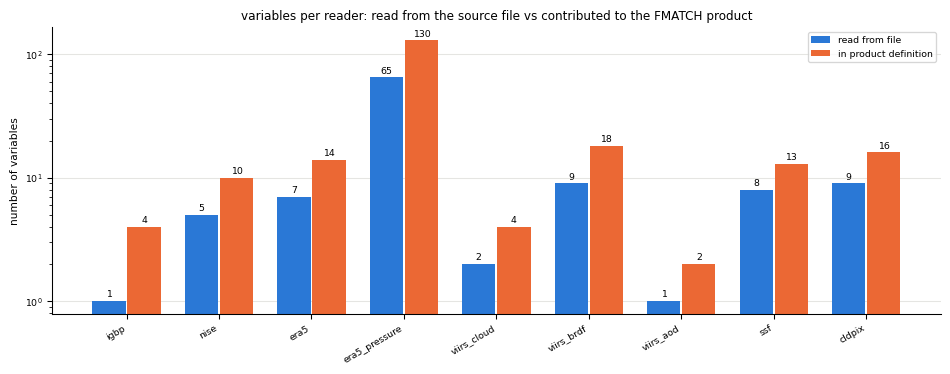

In [43]:
"""Verification summary across every reader."""

order = ["igbp", "nise", "era5", "era5_pressure", "viirs_cloud", "viirs_brdf", "viirs_aod", "ssf", "cldpix"]

print(f"{'reader':<16}{'status':<20}{'variables':>10}{'mean valid cells':>19}   file")
print("-" * 108)
for key in order:
    result = RESULTS.get(key, {"status": "not run", "variables": 0, "valid_pct": float("nan")})
    path = FILES.get(key)
    valid = "-" if not np.isfinite(result["valid_pct"]) else f"{result['valid_pct']:.0f}%"
    print(f"{key:<16}{result['status']:<20}{result['variables']:>10}{valid:>19}   {path.name if path else '(missing)'}")

n_ok = sum(1 for r in RESULTS.values() if r["status"] == "OK")
print(f"\n{n_ok} of {len(order)} readers verified against real data.")

# Bar chart of variable counts, read vs contributed to the product, so the gap the
# standard-deviation companions and derived outputs create is visible at a glance.
fig, ax = plt.subplots(figsize=(10, 4))
positions = np.arange(len(order))
read_counts = [len(ReaderRegistry.get(k).VARIABLES) for k in order]
product_counts = [len(ReaderRegistry.get(k).product_variable_specs()) for k in order]
ax.bar(positions - 0.19, read_counts, width=0.36, color=CATEGORICAL_SLOTS[0], label="read from file")
ax.bar(positions + 0.19, product_counts, width=0.36, color=CATEGORICAL_SLOTS[1], label="in product definition")
ax.set_xticks(positions)
ax.set_xticklabels(order, rotation=30, ha="right")
ax.set_ylabel("number of variables")
ax.set_yscale("log")  # 1 to 130 variables is two orders of magnitude
ax.set_title("variables per reader: read from the source file vs contributed to the FMATCH product")
ax.legend()
ax.grid(axis="y", color="#e5e5e2")
ax.set_axisbelow(True)
for x, (read, product) in enumerate(zip(read_counts, product_counts)):
    ax.text(x - 0.19, read * 1.08, str(read), ha="center", fontsize=7)
    ax.text(x + 0.19, product * 1.08, str(product), ha="center", fontsize=7)
fig.tight_layout()
plt.show()

---
## Where to go next

* **Reader implementations** — [`libera_utils/footprint_matching/readers/`](../libera_utils/footprint_matching/readers/)
* **Shared rasterization helpers** — [`readers/_swath.py`](../libera_utils/footprint_matching/readers/_swath.py)
* **Tile / variable data classes** — [`footprint_matching/types.py`](../libera_utils/footprint_matching/types.py)
* **Footprint geometry and the PSF** — [`geometry_demo.ipynb`](geometry_demo.ipynb), which shows
  how a radiometer footprint becomes the bounding box that decides *which* tiles this notebook's
  readers are asked for.
* **Product definitions** — [`libera_utils/data/product_definitions/`](../libera_utils/data/product_definitions/),
  where every variable documented here appears as an output variable of a FMATCH product.

### Adding a reader

1. Subclass `GriddedDataReader`, set `READER_KEY`, `INSTRUMENT`, `RESOLUTION_KM`,
   `REQUIRED_MODE`, `VARIABLES`, and implement `_load_spatial_region(bbox)`.
2. Import the module in `readers/__init__.py` so `__init_subclass__` registers it.
3. Add a section here: file provenance and structure, a `register_docs(...)` call for its
   variables, a whole-file overview plot, and the extracted-tile panels. The shared helpers do
   the rest, and `register_docs` will warn if a variable is undocumented.